In [ ]:
query_dial = f"""
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT
        admin_log_id,
        event_date,
        user,
        event_section,
        event_type,
        record_id,
        event_code,
        event_sql,
        event_notes
    FROM asterisk.vicidial_admin_log
    WHERE event_sql LIKE ''%dial_method%''
    ORDER BY event_date DESC

')
"""

df_prueba_02 = pd.read_sql(
    query_dial,
    engine_zeus
)

In [106]:

import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *
from sqlalchemy import create_engine
from sqlalchemy import text
import pandas as pd
import numpy as np

import pandas as pd


In [107]:
server_sql = server_zeus
db_sql = "ODIN"
user_sql = user_zeus
pwd_sql = pwd_zeus

engine_zeus = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)

In [108]:
def obtener_info_servidor(servidor,campanas,fecha_mes_base,engine_zeus):

    print("=" * 80)
    print(f"PROCESANDO SERVIDOR: 192.168.3.{servidor}")
    print("CAMPAÑAS:")

    for campana in campanas:
        print(f" - {campana}")

    print("=" * 80)


    # ========================================================
    # 1. FILTRO DE CAMPAÑAS
    # ========================================================

    condiciones = [
        f'e.campaign_name LIKE "%{campana}%"'
        for campana in campanas
    ]

    filtro_campanas = " OR ".join(condiciones)

    print("\nFiltro generado:")
    print(filtro_campanas)


    # ========================================================
    # 2. EXTRAER DIAL LOG
    # ========================================================

    query_dial = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '

        SELECT
            call_date,
            lead_id,
            server_ip,
            extension,
            channel,
            context,

            /* NUMERO QUE VE EL CLIENTE */
            outbound_cid,

            sip_hangup_cause,
            sip_hangup_reason,
            uniqueid,
            caller_code,

            CASE

                WHEN extension LIKE ''888%''
                  OR channel LIKE ''Local/888%''
                    THEN ''PERUCALL''

                WHEN extension LIKE ''899%''
                  OR channel LIKE ''Local/899%''
                    THEN ''INTELVOX''

                ELSE ''OTRO''

            END AS proveedor

        FROM asterisk.vicidial_dial_log

        WHERE

            call_date >= DATE_FORMAT(
                ''{fecha_mes_base}'',
                ''%Y-%m-01''
            )

        AND call_date <

            DATE_ADD(

                DATE_FORMAT(
                    ''{fecha_mes_base}'',
                    ''%Y-%m-01''
                ),

                INTERVAL 1 MONTH
            )

    ')
    """

    df_dial = pd.read_sql(
        query_dial,
        engine_zeus
    )

    print("\nDial Log:", len(df_dial))


    # ========================================================
    # 3. EXTRAER VICIDIAL LOG
    # ========================================================

    query_vic = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '

        SELECT

            a.lead_id,

            a.uniqueid,

            RTRIM(
                LTRIM(
                    d.vendor_lead_code
                )
            ) AS vendor_lead_code,


            /* ===============================================
               CONFIGURACION ACTUAL

               SOLO SE USA COMO REFERENCIA.
               NO usar para análisis histórico.
               =============================================== */

            e.dial_method
                AS dial_method_actual,

            e.auto_dial_level
                AS auto_dial_level_actual,

            e.hopper_level
                AS hopper_level_actual,


            /* =============================================== */

            a.campaign_id
                AS numero_campana,

            a.user
                AS dni_ejecutivo,

            c.full_name
                AS ejecutivo,

            e.campaign_name
                AS nombre_campana,

            a.call_date
                AS fecha_hora_llamada,

            a.length_in_sec
                AS duracion,

            b.status_name
                AS call_result,

            f.list_description,

            f.list_name,

            a.phone_number
                AS phone_number,

            d.alt_phone
                AS fecha_agenda,

            d.comments
                AS comentarios,

            a.status
                AS codigo


        FROM asterisk.vicidial_log a


        LEFT JOIN asterisk.vicidial_list d
            ON a.lead_id = d.lead_id


        LEFT JOIN asterisk.vicidial_campaigns e
            ON a.campaign_id = e.campaign_id


        LEFT JOIN asterisk.vicidial_lists f
            ON a.list_id = f.list_id


        LEFT JOIN asterisk.vicidial_statuses b
            ON a.status = b.status


        LEFT JOIN asterisk.vicidial_users c
            ON a.user = c.user


        WHERE
            (
                {filtro_campanas}
            )


        AND a.call_date >= DATE_FORMAT(
            ''{fecha_mes_base}'',
            ''%Y-%m-01''
        )


        AND a.call_date <

            DATE_ADD(

                DATE_FORMAT(
                    ''{fecha_mes_base}'',
                    ''%Y-%m-01''
                ),

                INTERVAL 1 MONTH
            )

    ')
    """

    df_vic = pd.read_sql(
        query_vic,
        engine_zeus
    )

    print(
        "Vicidial Log:",
        len(df_vic)
    )


    # ========================================================
    # 4. EXTRAER AGENT LOG
    # ========================================================

    query_agent = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '

        SELECT

            agent_log_id,

            user,

            server_ip,

            event_time,

            lead_id,

            campaign_id,

            pause_sec,

            wait_sec,

            talk_sec,

            dispo_sec,

            dead_sec,

            status,

            uniqueid,

            pause_type


        FROM asterisk.vicidial_agent_log


        WHERE

            event_time >= DATE_FORMAT(
                ''{fecha_mes_base}'',
                ''%Y-%m-01''
            )


        AND event_time <

            DATE_ADD(

                DATE_FORMAT(
                    ''{fecha_mes_base}'',
                    ''%Y-%m-01''
                ),

                INTERVAL 1 MONTH
            )

    ')
    """

    df_agent = pd.read_sql(
        query_agent,
        engine_zeus
    )

    print(
        "Agent Log:",
        len(df_agent)
    )


    # ========================================================
    # 5. PREPARAR VICIDIAL LOG
    # ========================================================

    df_vic["fecha_hora_llamada"] = pd.to_datetime(
        df_vic["fecha_hora_llamada"],
        errors="coerce"
    )


    df_vic["lead_id"] = pd.to_numeric(
        df_vic["lead_id"],
        errors="coerce"
    )


    df_vic["duracion"] = pd.to_numeric(
        df_vic["duracion"],
        errors="coerce"
    )


    df_vic = (

        df_vic

        .dropna(
            subset=[
                "lead_id",
                "fecha_hora_llamada",
                "numero_campana"
            ]
        )

        .copy()
    )


    df_vic["lead_id"] = (
        df_vic["lead_id"]
        .astype("int64")
    )


    # ========================================================
    # CLAVE DE CAMPAÑA
    # ========================================================

    df_vic["numero_campana"] = (

        df_vic["numero_campana"]

        .astype(str)

        .str.strip()
    )


    # ========================================================
    # 6. OBTENER CAMPAÑAS
    # ========================================================

    campanas_ids = (

        df_vic["numero_campana"]

        .dropna()

        .unique()

        .tolist()
    )


    print("\nIDs campañas encontrados:")
    print(campanas_ids)


    # ========================================================
    # 7. EXTRAER ADMIN LOG
    # ========================================================

    if len(campanas_ids) > 0:

        ids_sql = ",".join(

            [
                f"''{x}''"
                for x in campanas_ids
            ]

        )


        query_admin = f"""
        SELECT *
        FROM OPENQUERY([192.168.3.{servidor}], '

            SELECT

                admin_log_id,

                event_date,

                user,

                event_section,

                event_type,

                record_id,

                event_code,

                event_sql,

                event_notes


            FROM asterisk.vicidial_admin_log


            WHERE

                event_section = ''CAMPAIGNS''


            AND record_id IN (
                {ids_sql}
            )


            AND
            (

                   event_sql LIKE ''%dial_method=%''

                OR event_sql LIKE ''%auto_dial_level=%''

                OR event_sql LIKE ''%hopper_level=%''

            )


            /* =================================================
               Necesitamos todo cambio anterior al fin del mes.

               Esto permite conocer el estado que estaba vigente
               incluso si fue configurado antes del día 1.
               ================================================= */

            AND event_date <

                DATE_ADD(

                    DATE_FORMAT(
                        ''{fecha_mes_base}'',
                        ''%Y-%m-01''
                    ),

                    INTERVAL 1 MONTH
                )


            ORDER BY

                event_date,

                admin_log_id

        ')
        """


        df_admin = pd.read_sql(
            query_admin,
            engine_zeus
        )


    else:

        df_admin = pd.DataFrame()


    print(
        "Admin Log configuraciones:",
        len(df_admin)
    )


    # ========================================================
    # 8. PREPARAR ADMIN LOG
    # ========================================================

    if not df_admin.empty:


        # ----------------------------------------------------
        # FECHA
        # ----------------------------------------------------

        df_admin["event_date"] = pd.to_datetime(
            df_admin["event_date"],
            errors="coerce"
        )


        # ----------------------------------------------------
        # record_id = campaign_id
        # ----------------------------------------------------

        df_admin["numero_campana"] = (

            df_admin["record_id"]

            .astype(str)

            .str.strip()
        )


        # ====================================================
        # DIAL METHOD HISTORICO
        # ====================================================

        df_admin["dial_method_historico"] = (

            df_admin["event_sql"]

            .astype(str)

            .str.extract(
                r"dial_method='([^']+)'",
                expand=False
            )
        )


        # ====================================================
        # AUTO DIAL LEVEL HISTORICO
        # ====================================================

        df_admin["auto_dial_level_historico"] = (

            df_admin["event_sql"]

            .astype(str)

            .str.extract(
                r"auto_dial_level='([^']+)'",
                expand=False
            )
        )


        # ====================================================
        # HOPPER LEVEL HISTORICO
        # ====================================================

        df_admin["hopper_level_historico"] = (

            df_admin["event_sql"]

            .astype(str)

            .str.extract(
                r"hopper_level='([^']+)'",
                expand=False
            )
        )


        # ====================================================
        # NORMALIZAR
        # ====================================================

        df_admin["dial_method_historico"] = (

            df_admin["dial_method_historico"]

            .str.strip()

            .str.upper()
        )


        df_admin["auto_dial_level_historico"] = pd.to_numeric(

            df_admin["auto_dial_level_historico"],

            errors="coerce"
        )


        df_admin["hopper_level_historico"] = pd.to_numeric(

            df_admin["hopper_level_historico"],

            errors="coerce"
        )


        # ====================================================
        # ORDEN CRONOLOGICO
        # ====================================================

        df_admin = (

            df_admin

            .dropna(
                subset=[
                    "event_date",
                    "numero_campana"
                ]
            )

            .sort_values(
                [
                    "numero_campana",
                    "event_date",
                    "admin_log_id"
                ]
            )

            .reset_index(
                drop=True
            )
        )


        # ====================================================
        # COMPLETAR CONFIGURACION HISTORICA
        #
        # Si una modificación cambia hopper pero no cambia
        # dial_method, conservamos el último dial_method.
        # ====================================================

        columnas_estado = [

            "dial_method_historico",

            "auto_dial_level_historico",

            "hopper_level_historico"
        ]


        df_admin[columnas_estado] = (

            df_admin

            .groupby(
                "numero_campana"
            )[columnas_estado]

            .ffill()
        )


        # ====================================================
        # UN CAMBIO POR SEGUNDO
        # ====================================================

        df_admin = (

            df_admin

            .sort_values(
                [
                    "numero_campana",
                    "event_date",
                    "admin_log_id"
                ]
            )

            .drop_duplicates(
                subset=[
                    "numero_campana",
                    "event_date"
                ],
                keep="last"
            )

            .copy()
        )


        print("\nConfiguración histórica:")


        print(

            df_admin[
                [
                    "event_date",
                    "numero_campana",
                    "dial_method_historico",
                    "auto_dial_level_historico",
                    "hopper_level_historico"
                ]
            ]

            .tail(30)
        )


    # ========================================================
    # 9. ASIGNAR CONFIGURACION HISTORICA A CADA LLAMADA
    # ========================================================

    if not df_admin.empty:


        izquierda = (

            df_vic

            .sort_values(
                [
                    "fecha_hora_llamada",
                    "numero_campana"
                ]
            )

            .reset_index(drop=True)
        )


        derecha = (

            df_admin[
                [
                    "numero_campana",
                    "event_date",
                    "admin_log_id",
                    "dial_method_historico",
                    "auto_dial_level_historico",
                    "hopper_level_historico"
                ]
            ]

            .sort_values(
                [
                    "event_date",
                    "numero_campana"
                ]
            )

            .reset_index(drop=True)
        )


        df_vic = pd.merge_asof(

            izquierda,

            derecha,

            left_on="fecha_hora_llamada",

            right_on="event_date",

            by="numero_campana",

            direction="backward",

            allow_exact_matches=True
        )


    else:


        df_vic["event_date"] = pd.NaT

        df_vic["admin_log_id"] = pd.NA

        df_vic["dial_method_historico"] = pd.NA

        df_vic["auto_dial_level_historico"] = pd.NA

        df_vic["hopper_level_historico"] = pd.NA


    # ========================================================
    # 10. RENOMBRAR CONFIGURACION
    # ========================================================

    df_vic = df_vic.rename(

        columns={

            "event_date":
                "fecha_configuracion_historica",

            "admin_log_id":
                "admin_log_id_configuracion"
        }
    )


    # ========================================================
    # 11. VALIDAR HISTORICO
    # ========================================================

    print("\n" + "=" * 80)
    print("CONFIGURACIÓN HISTÓRICA")
    print("=" * 80)


    print("\nDIAL METHOD:")

    print(

        df_vic["dial_method_historico"]

        .value_counts(
            dropna=False
        )
    )


    print("\nAUTO DIAL LEVEL:")

    print(

        df_vic["auto_dial_level_historico"]

        .value_counts(
            dropna=False
        )

        .sort_index()
    )


    print("\nHOPPER LEVEL:")

    print(

        df_vic["hopper_level_historico"]

        .value_counts(
            dropna=False
        )

        .sort_index()
    )


    # ========================================================
    # 12. PREPARAR DIAL LOG
    # ========================================================

    df_dial["call_date"] = pd.to_datetime(

        df_dial["call_date"],

        errors="coerce"
    )


    df_dial["lead_id"] = pd.to_numeric(

        df_dial["lead_id"],

        errors="coerce"
    )


    df_dial = (

        df_dial

        .dropna(
            subset=[
                "lead_id",
                "call_date"
            ]
        )

        .copy()
    )


    df_dial["lead_id"] = (

        df_dial["lead_id"]

        .astype("int64")
    )


    # ========================================================
    # NORMALIZAR OUTBOUND CID
    # ========================================================

    df_dial["outbound_cid"] = (

        df_dial["outbound_cid"]

        .astype("string")

        .str.strip()
    )


    # Crear otra columna sin caracteres especiales
    # para posteriores análisis por número.

    df_dial["outbound_cid_limpio"] = (

        df_dial["outbound_cid"]

        .str.replace(
            r"\D",
            "",
            regex=True
        )
    )


    df_dial = (

        df_dial

        .sort_values(
            [
                "call_date",
                "lead_id"
            ]
        )

        .reset_index(drop=True)
    )


    # ========================================================
    # 13. PREPARAR AGENT LOG
    # ========================================================

    df_agent["event_time"] = pd.to_datetime(

        df_agent["event_time"],

        errors="coerce"
    )


    df_agent["lead_id"] = pd.to_numeric(

        df_agent["lead_id"],

        errors="coerce"
    )


    df_agent = (

        df_agent

        .dropna(
            subset=[
                "lead_id",
                "event_time"
            ]
        )

        .copy()
    )


    df_agent["lead_id"] = (

        df_agent["lead_id"]

        .astype("int64")
    )


    columnas_duracion_agent = [

        "pause_sec",

        "wait_sec",

        "talk_sec",

        "dispo_sec",

        "dead_sec"
    ]


    for columna in columnas_duracion_agent:

        df_agent[columna] = pd.to_numeric(

            df_agent[columna],

            errors="coerce"
        )


    # ========================================================
    # 14. NORMALIZAR UNIQUEID
    # ========================================================

    df_vic["uniqueid_match"] = (

        df_vic["uniqueid"]

        .astype(str)

        .str.strip()

        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


    df_agent["uniqueid_match"] = (

        df_agent["uniqueid"]

        .astype(str)

        .str.strip()

        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


    # ========================================================
    # 15. DUPLICADOS AGENT LOG
    # ========================================================

    duplicados_agent = (

        df_agent

        .duplicated(

            subset=[
                "lead_id",
                "uniqueid_match"
            ],

            keep=False
        )

        .sum()
    )


    print(
        "\nDuplicados Agent Log:",
        duplicados_agent
    )


    # ========================================================
    # 16. UN AGENT LOG POR LLAMADA
    # ========================================================

    df_agent_match = (

        df_agent

        .sort_values(
            "event_time"
        )

        .drop_duplicates(

            subset=[
                "lead_id",
                "uniqueid_match"
            ],

            keep="last"
        )

        .copy()
    )


    # ========================================================
    # 17. PREPARAR VICIDIAL
    # ========================================================

    df_vic = (

        df_vic

        .sort_values(
            [
                "fecha_hora_llamada",
                "lead_id"
            ]
        )

        .reset_index(
            drop=True
        )
    )


    # ========================================================
    # 18. VICIDIAL LOG VS DIAL LOG
    #
    # AQUÍ SE AGREGA OUTBOUND_CID
    # ========================================================

    df_final = pd.merge_asof(

        df_vic,

        df_dial[
            [
                "lead_id",

                "call_date",

                "proveedor",

                # =============================================
                # CALLER ID / NUMERO SALIENTE
                # =============================================
                "outbound_cid",

                "outbound_cid_limpio",

                # =============================================

                "sip_hangup_cause",

                "sip_hangup_reason",

                "extension",

                "channel",

                "context",

                "server_ip",

                "caller_code"
            ]
        ],

        left_on=
            "fecha_hora_llamada",

        right_on=
            "call_date",

        by=
            "lead_id",

        direction=
            "backward",

        tolerance=pd.Timedelta(
            seconds=90
        )
    )


    # ========================================================
    # 19. DIFERENCIA DIAL LOG
    # ========================================================

    df_final["diferencia_segundos"] = (

        df_final["fecha_hora_llamada"]

        - df_final["call_date"]

    ).dt.total_seconds()


    # ========================================================
    # 20. CRUZAR CON AGENT LOG
    # ========================================================

    df_final = df_final.merge(

        df_agent_match[
            [
                "lead_id",

                "uniqueid_match",

                "event_time",

                "wait_sec",

                "talk_sec",

                "dispo_sec",

                "dead_sec",

                "pause_sec",

                "status",

                "campaign_id",

                "pause_type"
            ]
        ],

        on=[
            "lead_id",
            "uniqueid_match"
        ],

        how=
            "left",

        suffixes=(
            "",
            "_agent"
        )
    )


    # ========================================================
    # 21. RENOMBRAR AGENT
    # ========================================================

    df_final = df_final.rename(

        columns={

            "event_time":
                "event_time_agent",

            "status":
                "status_agent",

            "campaign_id":
                "campaign_id_agent"
        }
    )


    # ========================================================
    # 22. DIFERENCIA AGENT
    # ========================================================

    df_final["diferencia_seg_agent"] = (

        df_final["event_time_agent"]

        - df_final["fecha_hora_llamada"]

    ).dt.total_seconds()


    # ========================================================
    # 23. SERVIDOR
    # ========================================================

    df_final["servidor"] = (
        f"192.168.3.{servidor}"
    )


    # ========================================================
    # 24. VALIDACIONES
    # ========================================================

    total = len(df_final)


    print("\n" + "-" * 80)

    print(
        f"TOTAL SERVIDOR {servidor}:",
        total
    )


    # ========================================================
    # PROVEEDOR
    # ========================================================

    con_proveedor = (

        df_final["proveedor"]

        .notna()

        .sum()
    )


    print(
        "\nCon proveedor:",
        con_proveedor
    )


    print(
        "% Match proveedor:",

        round(
            con_proveedor / total * 100,
            2
        )

        if total > 0

        else 0
    )


    # ========================================================
    # OUTBOUND CID
    # ========================================================

    con_outbound_cid = (

        df_final["outbound_cid_limpio"]

        .notna()

        .sum()
    )


    print(
        "\nCon Outbound CID:",
        con_outbound_cid
    )


    print(
        "% con Outbound CID:",

        round(
            con_outbound_cid / total * 100,
            2
        )

        if total > 0

        else 0
    )


    print(
        "\nCantidad de Caller ID distintos:"
    )


    print(

        df_final

        .groupby(
            "proveedor",
            dropna=False
        )["outbound_cid_limpio"]

        .nunique()
    )


    # ========================================================
    # AGENT LOG
    # ========================================================

    con_agent = (

        df_final["event_time_agent"]

        .notna()

        .sum()
    )


    print(
        "\nCon Agent Log:",
        con_agent
    )


    print(
        "% Match Agent:",

        round(
            con_agent / total * 100,
            2
        )

        if total > 0

        else 0
    )


    # ========================================================
    # DIAL METHOD HISTORICO
    # ========================================================

    con_historico = (

        df_final["dial_method_historico"]

        .notna()

        .sum()
    )


    print(
        "\nCon Dial Method histórico:",
        con_historico
    )


    print(
        "% identificado:",

        round(
            con_historico / total * 100,
            2
        )

        if total > 0

        else 0
    )


    print(
        "\nDistribución Dial Method:"
    )


    print(

        df_final["dial_method_historico"]

        .value_counts(
            dropna=False
        )
    )


    print("-" * 80)


    # ========================================================
    # 25. RETORNAR
    # ========================================================

    return df_final

In [109]:
lista_servidores = []

for servidor, campanas in config_servidores.items():

    try:

        df_temp = obtener_info_servidor(
            servidor=servidor,
            campanas=campanas,
            fecha_mes_base=fecha_mes_base,
            engine_zeus=engine_zeus
        )

        lista_servidores.append(df_temp)

    except Exception as e:

        print("\n" + "!" * 80)
        print(f"ERROR EN SERVIDOR {servidor}")
        print(e)
        print("!" * 80)

PROCESANDO SERVIDOR: 192.168.3.76
CAMPAÑAS:
 - SAE
 - SAR
 - AGENDA

Filtro generado:
e.campaign_name LIKE "%SAE%" OR e.campaign_name LIKE "%SAR%" OR e.campaign_name LIKE "%AGENDA%"

Dial Log: 368578
Vicidial Log: 367526
Agent Log: 59007

IDs campañas encontrados:
['16', '55', '56']
Admin Log configuraciones: 130

Configuración histórica:
             event_date numero_campana dial_method_historico  \
100 2026-08-17 09:05:08             55                 RATIO   
101 2026-08-17 10:09:47             55                 RATIO   
102 2026-08-17 10:20:37             55                 RATIO   
103 2026-08-17 13:17:11             55                 RATIO   
104 2026-08-17 14:49:12             55                 RATIO   
105 2026-08-17 16:32:12             55         ADAPT_TAPERED   
106 2026-08-17 17:35:47             55         ADAPT_TAPERED   
107 2026-08-17 17:51:05             55         ADAPT_TAPERED   
108 2026-08-17 17:52:09             55         ADAPT_TAPERED   
109 2026-08-17 18:0

In [111]:
df_total_mes = pd.concat(
    lista_servidores,
    ignore_index=True
)
print( "TOTAL GENERAL:", len(df_total_mes))
print()
print( df_total_mes["servidor"].value_counts())
print()
print(df_total_mes["proveedor"].value_counts(dropna=False))

TOTAL GENERAL: 1281998

servidor
192.168.3.64    562049
192.168.3.76    367526
192.168.3.21    312264
192.168.3.40     23337
192.168.3.7      16822
Name: count, dtype: int64

proveedor
INTELVOX    1013854
PERUCALL     267372
OTRO            696
NaN              76
Name: count, dtype: int64


In [112]:
df_total_mes["codigo"] = (
    df_total_mes["codigo"]
    .astype(str)
    .str.strip()
)

mask = df_total_mes["codigo"].str.fullmatch(r"\d+")

df_total_mes.loc[mask, "codigo"] = (
    "AL" + df_total_mes.loc[mask, "codigo"]
)
# 1. CHS005 → CHS002
df_total_mes["codigo"] = (
    df_total_mes["codigo"]
    .replace("CHS005", "CHS002")
)

# 2. Reemplazar CHS00 por AL
df_total_mes["codigo"] = (
    df_total_mes["codigo"]
    .str.replace(
        r"^CHS00",
        "AL",
        regex=True
    )
)
df_total_mes["codigo"] = (
    df_total_mes["codigo"]
    .str.replace(
        r"^CHS0",
        "AL",
        regex=True
    )
)
df_total_mes["proveedor"] = (
    df_total_mes["proveedor"]
    .fillna("PROVEEDOR NO IDENTIFICADO")
)


In [27]:
# ============================================================
# COLUMNAS CATEGÓRICAS
# ============================================================

columnas_limpiar = [
    "dial_method_historico",
    "proveedor",
    "codigo"
]

for col in columnas_limpiar:
    df_total_mes[col] = (
        df_total_mes[col]
        .astype("string")
        .str.strip()
        .str.upper()
    )


# ============================================================
# NOMBRE CAMPAÑA
# ============================================================

df_total_mes["nombre_campana"] = (
    df_total_mes["nombre_campana"]
    .astype("string")
    .str.strip()
)

query_vic = f"""
    SELECT DISTINCT estado,descripcion,codigo
    FROM (
        select [NIVEL 2] as estado,[NIVEL 4] as descripcion,cod as codigo 
        from ODIN.dbo.tTipologia_Diners_TC
        where cod like 'E0%'

        UNION

        select [NIVEL 2] as estado,[NIVEL 4] as descripcion,cod as codigo  
        from ODIN.dbo.tTipologia_Diners_PPD
        where cod like 'C0%'
            UNION

        select tipo as estado,descripcion,codigo  
        from ODIN.dbo.tTipologia_Efectiva
        where codigo like 'B0%'

        UNION

        select tipo as estado,descripcion,codigo  
        from ODIN.dbo.tTipologia_Cencosud_PPFF
        where codigo like 'R0%'

        UNION

        select distinct case 
        when estado='CONTACTO EFECTIVO CON TITULAR' then 'CONTACTO EFECTIVO'
        when estado='CONTACTO CON TERCERO NO RELACIONADO' then 'CONTACTO NO EFECTIVO'
        when estado='CONTACTO CON TERCERO' then 'CONTACTO NO EFECTIVO'
        when estado='DISCADOR' then 'MAQUINA'
        when estado='DISCADOR (AUTO)' then 'MAQUINA'
        when estado='NO CONTACTO' then 'NO CONTACTO'
        end as estado,descripcion,codigo
        from [192.168.2.50].[ODIN].[dbo].[tTipologia_Alfin]
        where estado is not null
    ) t
    """
df_tipi = pd.read_sql(query_vic,engine_zeus)
df_tipi=df_tipi.drop_duplicates('codigo')

columnas_limpiar = ["estado","codigo",]

for col in columnas_limpiar:
    df_tipi[col] = (
        df_tipi[col]
        .astype(str)
        .str.strip()
    )

df_total_mes_01=df_total_mes.merge(df_tipi,on='codigo',how='left')

df_total_mes_01["estado"] = (
    df_total_mes_01["estado"]
    .replace("CONTACTO TERCERO", "CONTACTO NO EFECTIVO")
)

columnas_limpiar = [
    "dial_method_historico",
    "proveedor",
    "estado",
    "codigo",
    "nombre_campana"
]

for col in columnas_limpiar:
    df_total_mes_01[col] = (
        df_total_mes_01[col]
        .astype(str)
        .str.strip()
    )

import numpy as np

contestadora = ["AA","AL","AM",'PM']
no_contesta_red = ["AB","NA","ADC"]
sistema_operacion = ["DROP","PDROP","DCMX"]
contato_1=['CALLBK', 'INCALL','XFER','CBHOLD','PU']

df_total_mes_01["estado"] = np.select(
    [
        df_total_mes_01["codigo"].isin(contestadora),
        df_total_mes_01["codigo"].isin(no_contesta_red),
        df_total_mes_01["codigo"].isin(sistema_operacion),
        df_total_mes_01["codigo"].isin(contato_1)
    ],
    [
        "BUZON DE VOZ",
        "NO CONTESTA / RED",
        "SISTEMA / OPERACION",
        "CONTACTO / TRANSFERENCIA"
    ],
    default=df_total_mes_01["estado"]
)


contacto = [
    "CONTACTO EFECTIVO",
    "CONTACTO NO EFECTIVO",
    "CONTACTO / TRANSFERENCIA"
]

no_contacto = [
    "NO CONTACTO",
    "NO CONTESTA / RED",
    "BUZON DE VOZ",
    "MAQUINA",
    "SISTEMA / OPERACION"
]

df_total_mes_01["tipo_contacto"] = np.select(
    [
        df_total_mes_01["estado"].isin(contacto),
        df_total_mes_01["estado"].isin(no_contacto)
    ],
    [
        "CONTACTO",
        "NO CONTACTO"
    ],
    default="REVISAR"
)
df_codigos = (
    df_total_mes_01.loc[
        df_total_mes_01["server_ip"] == "192.168.3.40",
        ["codigo"]
    ]
    .drop_duplicates()
)

print(df_codigos["codigo"].unique().tolist())


proveedores = ["PERUCALL","INTELVOX"]

campanas = [
        "AGENDA",
        "2026-08 SAE",
        "2026-08 SAR",
        "BOT_EFECTIVA_NC",
        "2026-08 BCO ALFIN",
        "2026-08 EFECTIVA_NEGOCIOS",
        "2026-08 EFECTIVA_NEGOCIOS SEG",
        "2026-08 DINERS TC",
        "IVR_TARGET",
        "IVR_Target_Seguimiento_1",
        "IVR_Target_Seguimiento_2",
        "2026-08 DINERS",
        "2026-08 DINERS PLUS"
    ]

df_total_mes_02 = df_total_mes_01[
    df_total_mes_01["proveedor"].isin(proveedores)&
    df_total_mes_01["nombre_campana"].isin(campanas)
].copy()
df_total_mes_02["sip_hangup_cause"] = pd.to_numeric(
    df_total_mes_02["sip_hangup_cause"],
    errors="coerce"
)


['PDROP', 'AB', 'ADC', 'PM', 'NA', 'PU']


In [28]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


## inicio

In [90]:
df_total_mes_02.columns

Index(['lead_id', 'uniqueid', 'vendor_lead_code', 'dial_method_actual',
       'auto_dial_level_actual', 'hopper_level_actual', 'numero_campana',
       'dni_ejecutivo', 'ejecutivo', 'nombre_campana', 'fecha_hora_llamada',
       'duracion', 'call_result', 'list_description', 'list_name',
       'phone_number', 'fecha_agenda', 'comentarios', 'codigo',
       'fecha_configuracion_historica', 'admin_log_id_configuracion',
       'dial_method_historico', 'auto_dial_level_historico',
       'hopper_level_historico', 'uniqueid_match', 'call_date', 'proveedor',
       'outbound_cid', 'outbound_cid_limpio', 'sip_hangup_cause',
       'sip_hangup_reason', 'extension', 'channel', 'context', 'server_ip',
       'caller_code', 'diferencia_segundos', 'event_time_agent', 'wait_sec',
       'talk_sec', 'dispo_sec', 'dead_sec', 'pause_sec', 'status_agent',
       'campaign_id_agent', 'pause_type', 'diferencia_seg_agent', 'servidor',
       'estado', 'descripcion', 'tipo_contacto', 'outbound_cid_origi

In [ ]:
df_p=df_total_mes[df_total_mes["servidor"]=='192.168.3.21']
df_tc=df_p[df_p["nombre_campana"]=='2026-08 DINERS TC']
df_tc['dial_method'].unique()


In [20]:
# ============================================================
# 2. DIAL_METHOD POR CAMPAÑA
# ============================================================

df_total_agosto_02 = df_total_mes[
    df_total_mes["proveedor"].isin(
        ["PERUCALL", "INTELVOX"]
    )
].copy()

campanas_dial = (
    df_total_agosto_02[
        [
            "servidor",
            "numero_campana",
            "nombre_campana",
            "dial_method_historico"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "servidor",
            "nombre_campana"
        ]
    )
)

print(
    campanas_dial.to_string(index=False)
)

    servidor numero_campana                nombre_campana dial_method_historico
192.168.3.21            409                2026-07 DINERS                 RATIO
192.168.3.21            410           2026-07 DINERS PLUS                 RATIO
192.168.3.21            134             2026-07 DINERS TC                 RATIO
192.168.3.21            412                2026-08 DINERS                 RATIO
192.168.3.21            412                2026-08 DINERS                MANUAL
192.168.3.21            413           2026-08 DINERS PLUS                 RATIO
192.168.3.21            413           2026-08 DINERS PLUS                MANUAL
192.168.3.21            136             2026-08 DINERS TC                 RATIO
192.168.3.21            136             2026-08 DINERS TC                MANUAL
192.168.3.40             10                    IVR_TARGET                 RATIO
192.168.3.64            401             2026-08 BCO ALFIN                 RATIO
192.168.3.64            403             

In [86]:
engine_zeus = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)

In [ ]:
df_prueba_02

In [ ]:
ss

['PDROP', 'AB', 'ADC', 'PM', 'NA', 'PU']


In [ ]:
ss

## VALORES DE DIAL_METHOD

  dial_method_historico  cantidad  porcentaje
0                 RATIO   1055949   87.410754
1         ADAPT_TAPERED    135380   11.206666
2                MANUAL     16702    1.382580


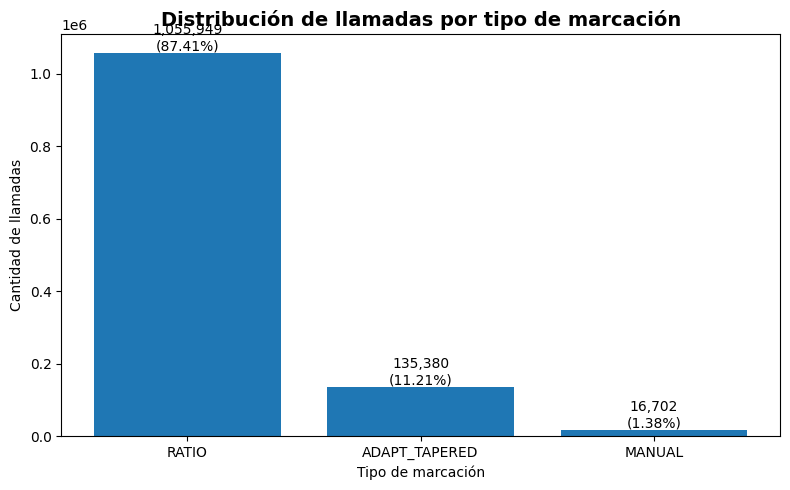

In [37]:
import matplotlib.pyplot as plt

resumen_dial = (
    df_total_mes_02["dial_method_historico"]
    .value_counts(dropna=True)
    .reset_index()
)
resumen_dial.columns = [
    "dial_method_historico",
    "cantidad"
]

# Porcentaje
resumen_dial["porcentaje"] = (
    resumen_dial["cantidad"]
    / resumen_dial["cantidad"].sum()
    * 100
)

print(resumen_dial)


# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    resumen_dial["dial_method_historico"].astype(str),
    resumen_dial["cantidad"]
)

ax.set_title(
    "Distribución de llamadas por tipo de marcación",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Tipo de marcación")
ax.set_ylabel("Cantidad de llamadas")

# ============================================================
# ETIQUETAS
# ============================================================

for barra, cantidad, porcentaje in zip(
    barras,
    resumen_dial["cantidad"],
    resumen_dial["porcentaje"]
):
    
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{cantidad:,.0f}\n({porcentaje:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

,dial_method_historico,proveedor,cantidad,porcentaje
0,ADAPT_TAPERED,INTELVOX,135146,99.827153
1,ADAPT_TAPERED,PERUCALL,234,0.172847
2,MANUAL,INTELVOX,5563,33.307388
3,MANUAL,PERUCALL,11139,66.692612
4,RATIO,INTELVOX,816719,77.344550
5,RATIO,PERUCALL,239230,22.655450


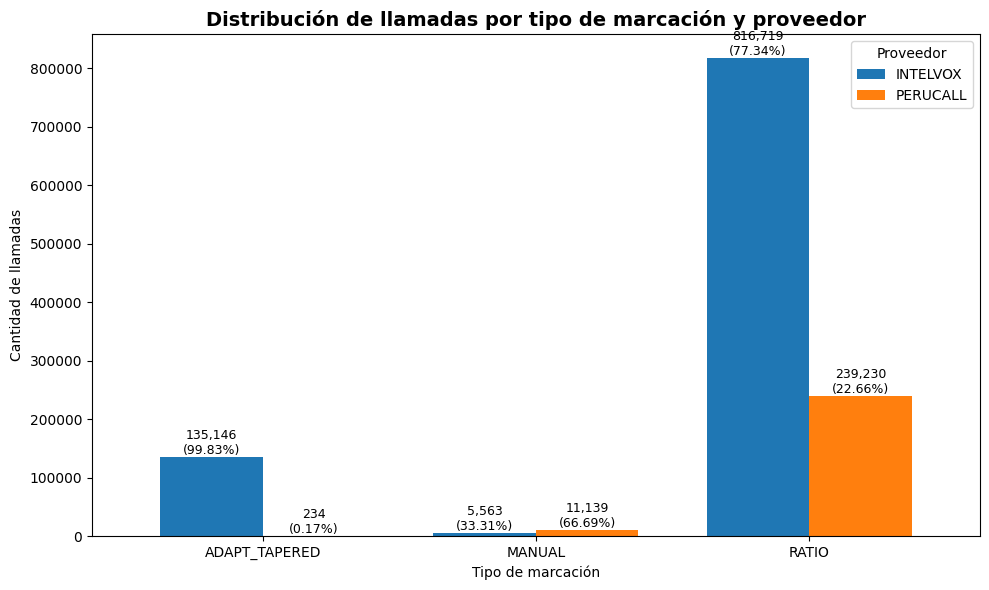

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

df_grafico = df_total_mes_02.copy()

resumen_dial = (
    df_grafico
    .groupby(
        ["dial_method_historico", "proveedor"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

# ============================================================
# PORCENTAJE DENTRO DE CADA dial_method_historico
# ============================================================

resumen_dial["porcentaje"] = (
    resumen_dial["cantidad"]
    / resumen_dial.groupby("dial_method_historico")["cantidad"].transform("sum")
    * 100
)

display(resumen_dial)

# ============================================================
# PIVOT PARA GRÁFICO
# ============================================================

pivot = resumen_dial.pivot(
    index="dial_method_historico",
    columns="proveedor",
    values="cantidad"
).fillna(0)

# ============================================================
# GRÁFICO
# ============================================================

ax = pivot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

ax.set_title(
    "Distribución de llamadas por tipo de marcación y proveedor",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Tipo de marcación")
ax.set_ylabel("Cantidad de llamadas")

ax.tick_params(
    axis="x",
    rotation=0
)

# ============================================================
# ETIQUETAS: CANTIDAD + PORCENTAJE
# ============================================================

for container, proveedor in zip(
    ax.containers,
    pivot.columns
):

    for barra, dial_method_historico in zip(
        container,
        pivot.index
    ):

        cantidad = barra.get_height()

        if cantidad > 0:

            total_dial = pivot.loc[dial_method_historico].sum()

            porcentaje = (
                cantidad / total_dial * 100
            )

            ax.text(
                barra.get_x() + barra.get_width() / 2,
                cantidad,
                f"{cantidad:,.0f}\n({porcentaje:.2f}%)",
                ha="center",
                va="bottom",
                fontsize=9
            )

ax.legend(
    title="Proveedor"
)

plt.tight_layout()
plt.show()

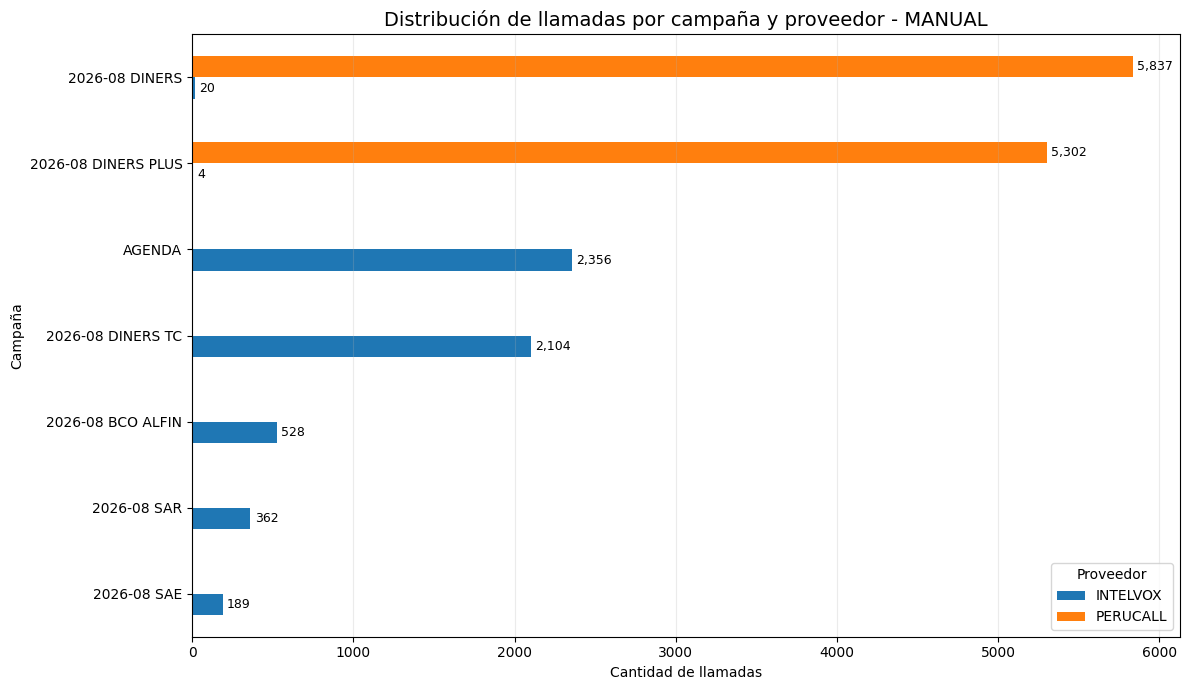

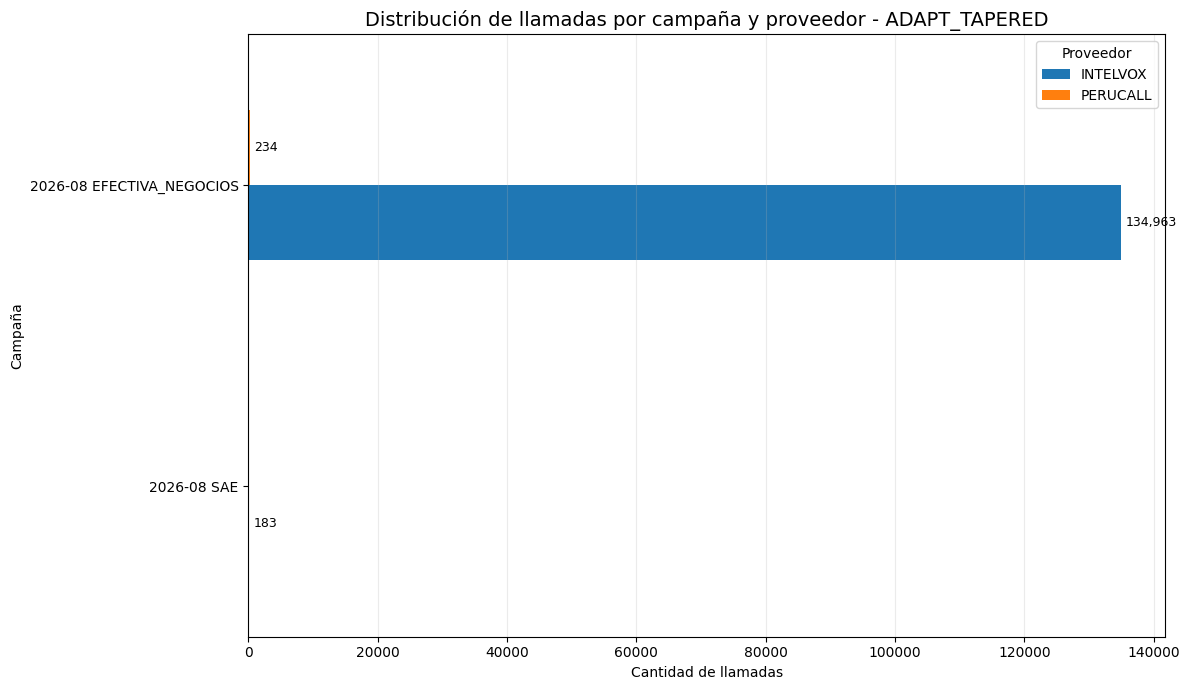

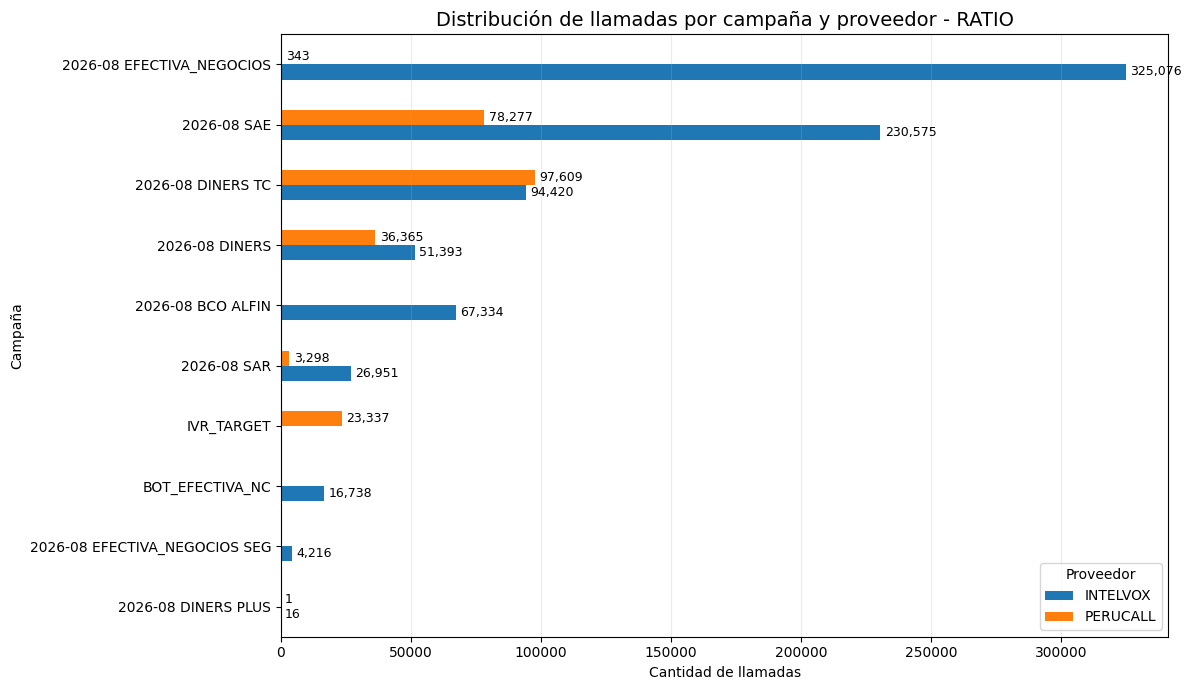

In [39]:
import matplotlib.pyplot as plt

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]

for metodo in orden_dial:

    df_metodo = df_total_mes_02[
        df_total_mes_02["dial_method_historico"] == metodo
    ].copy()

    if df_metodo.empty:
        continue

    # --------------------------------------------------------
    # VOLUMEN POR CAMPAÑA Y PROVEEDOR
    # --------------------------------------------------------

    df_grafico_campana = (
        df_metodo
        .groupby(
            [
                "nombre_campana",
                "proveedor"
            ]
        )
        .size()
        .unstack(
            fill_value=0
        )
    )

    # --------------------------------------------------------
    # ORDENAR POR VOLUMEN TOTAL
    # --------------------------------------------------------

    df_grafico_campana["TOTAL"] = (
        df_grafico_campana.sum(axis=1)
    )

    df_grafico_campana = (
        df_grafico_campana
        .sort_values(
            "TOTAL",
            ascending=True
        )
        .drop(
            columns="TOTAL"
        )
    )

    # --------------------------------------------------------
    # GRÁFICO
    # --------------------------------------------------------

    ax = df_grafico_campana.plot(
        kind="barh",
        figsize=(12, 7)
    )

    # --------------------------------------------------------
    # CANTIDADES EN LAS BARRAS
    # --------------------------------------------------------

    for container in ax.containers:

        labels = [
            f"{int(v):,}" if v > 0 else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    # --------------------------------------------------------
    # FORMATO
    # --------------------------------------------------------

    ax.set_title(
        f"Distribución de llamadas por campaña y proveedor - {metodo}",
        fontsize=14
    )

    ax.set_xlabel(
        "Cantidad de llamadas"
    )

    ax.set_ylabel(
        "Campaña"
    )

    ax.legend(
        title="Proveedor"
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

## Ver proveedor por campaña

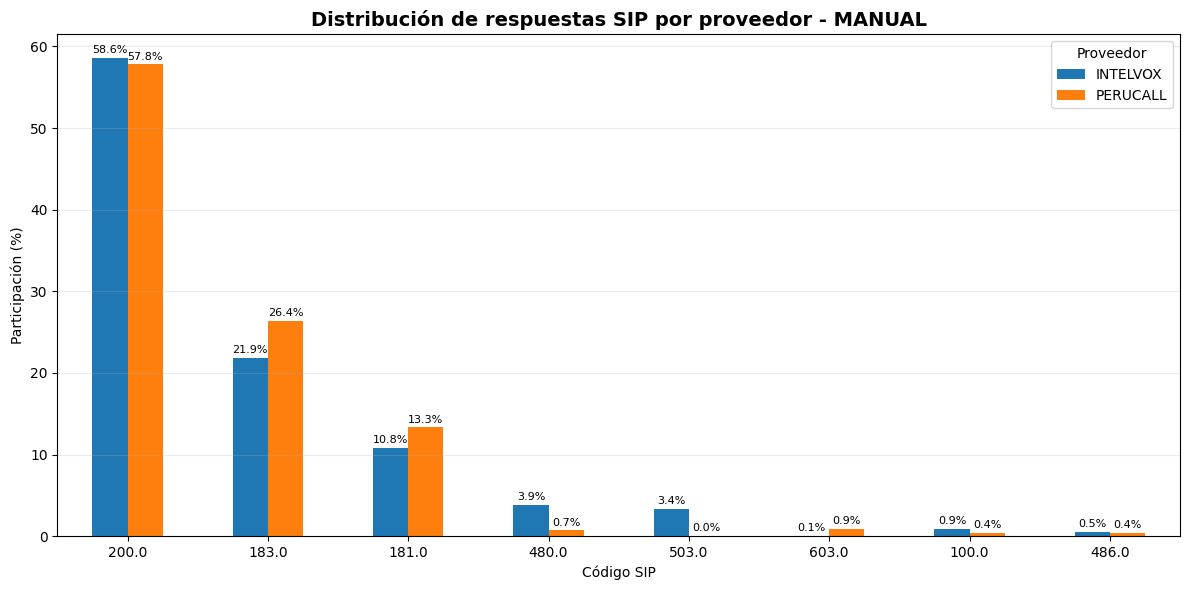

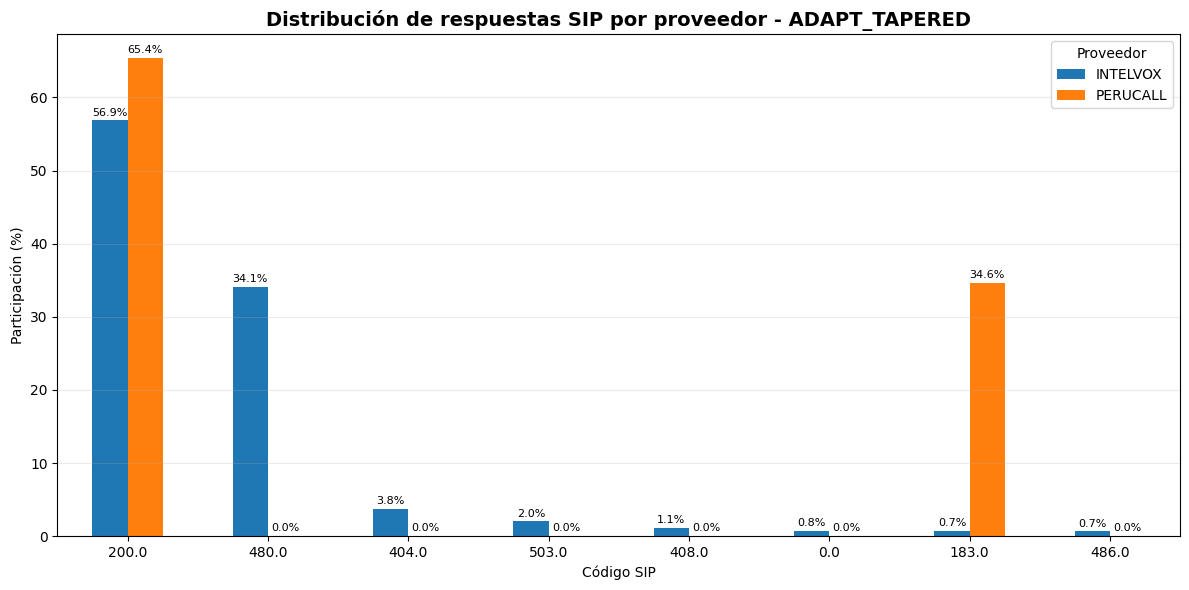

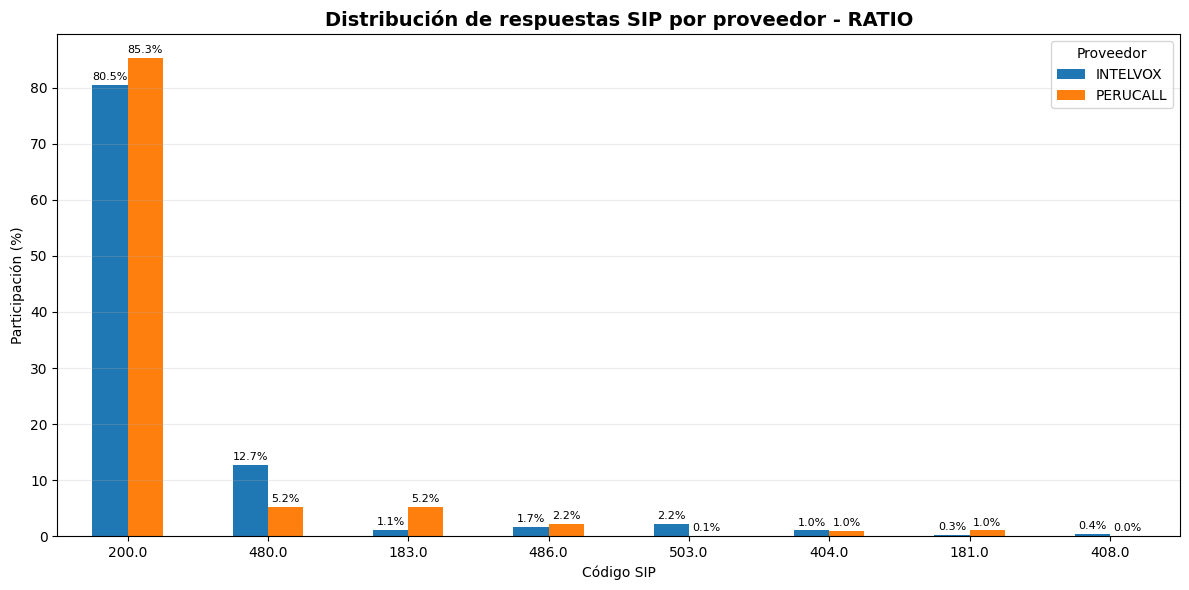

In [40]:
# ============================================================
# ORDEN DE dial_method_historico
# ============================================================

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]
# ============================================================
# GRÁFICO SIP POR dial_method_historico
# ============================================================

for metodo in orden_dial:

    # --------------------------------------------------------
    # FILTRAR MÉTODO
    # --------------------------------------------------------

    df_sip = df_total_mes_02[
        df_total_mes_02["dial_method_historico"] == metodo
    ].copy()

    if df_sip.empty:
        continue

    # --------------------------------------------------------
    # PRINCIPALES SIP DEL MÉTODO
    # --------------------------------------------------------

    top_sip = (
        df_sip["sip_hangup_cause"]
        .value_counts()
        .head(8)
        .index
    )

    # --------------------------------------------------------
    # RESUMEN POR PROVEEDOR + SIP
    # --------------------------------------------------------

    df_sip_grafico = (
        df_sip[
            df_sip["sip_hangup_cause"].isin(top_sip)
        ]
        .groupby(
            [
                "proveedor",
                "sip_hangup_cause"
            ],
            dropna=False
        )
        .size()
        .reset_index(name="cantidad")
    )

    # --------------------------------------------------------
    # PORCENTAJE DENTRO DE CADA PROVEEDOR
    # --------------------------------------------------------

    df_sip_grafico["porcentaje"] = (
        df_sip_grafico["cantidad"]
        /
        df_sip_grafico
        .groupby("proveedor")["cantidad"]
        .transform("sum")
        * 100
    )

    # --------------------------------------------------------
    # PIVOT
    # --------------------------------------------------------

    tabla_sip_grafico = (
        df_sip_grafico
        .pivot(
            index="sip_hangup_cause",
            columns="proveedor",
            values="porcentaje"
        )
        .fillna(0)
    )

    # Mantener orden del TOP SIP
    tabla_sip_grafico = (
        tabla_sip_grafico
        .reindex(top_sip)
        .fillna(0)
    )

    # --------------------------------------------------------
    # GRÁFICO
    # --------------------------------------------------------

    ax = tabla_sip_grafico.plot(
        kind="bar",
        figsize=(12, 6)
    )

    ax.set_title(
        f"Distribución de respuestas SIP por proveedor - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Código SIP")
    ax.set_ylabel("Participación (%)")

    ax.legend(
        title="Proveedor"
    )

    plt.xticks(
        rotation=0
    )

    # --------------------------------------------------------
    # ETIQUETAS %
    # --------------------------------------------------------

    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=2,
            fontsize=8
        )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

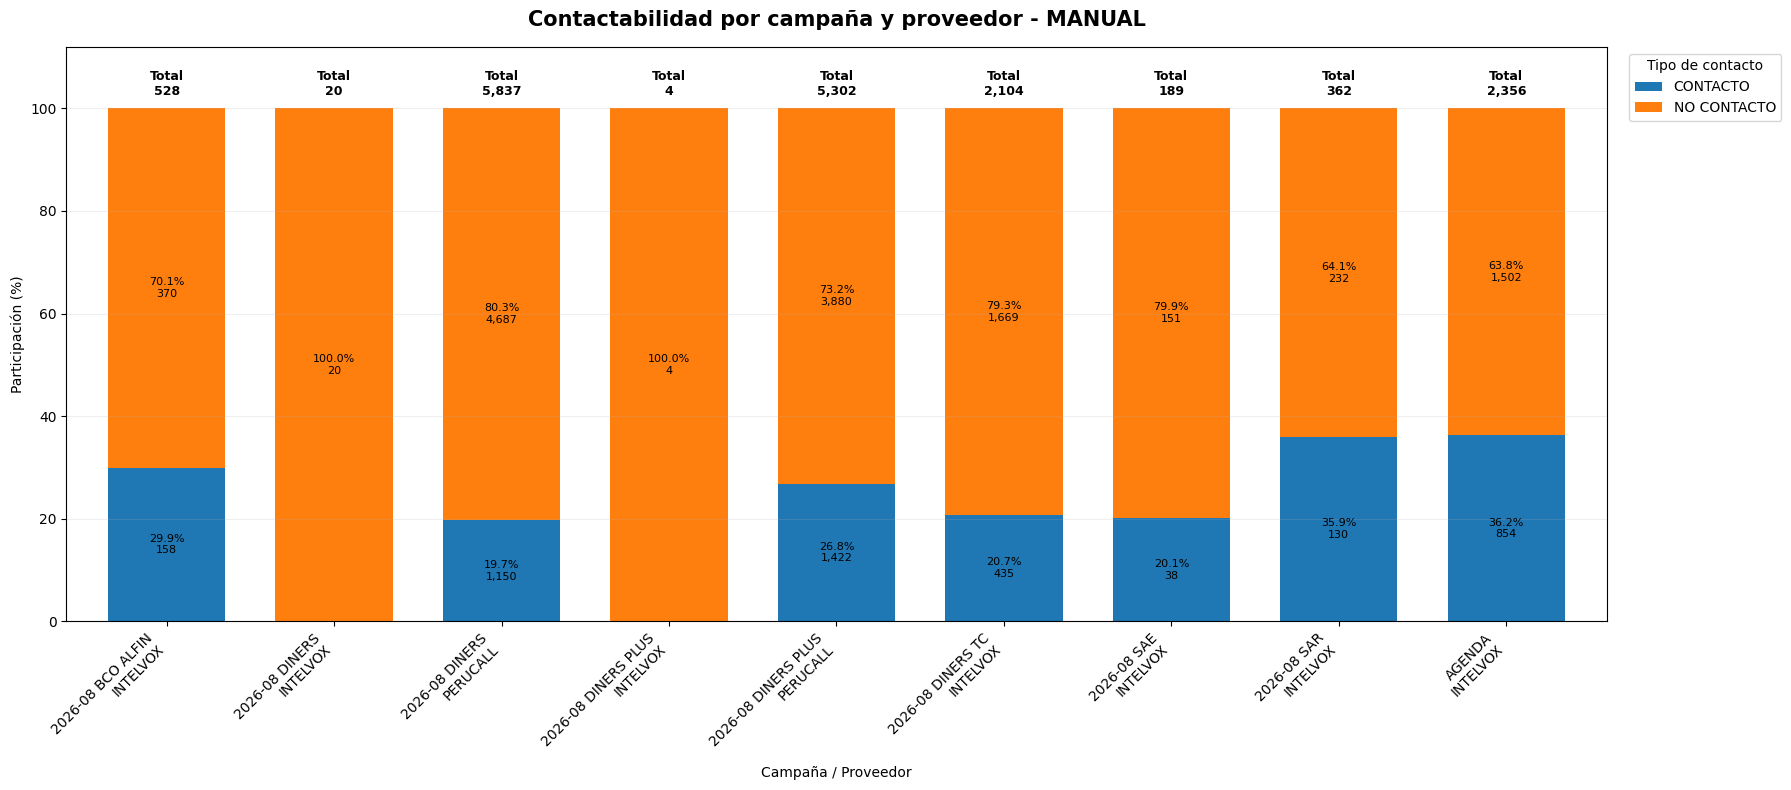

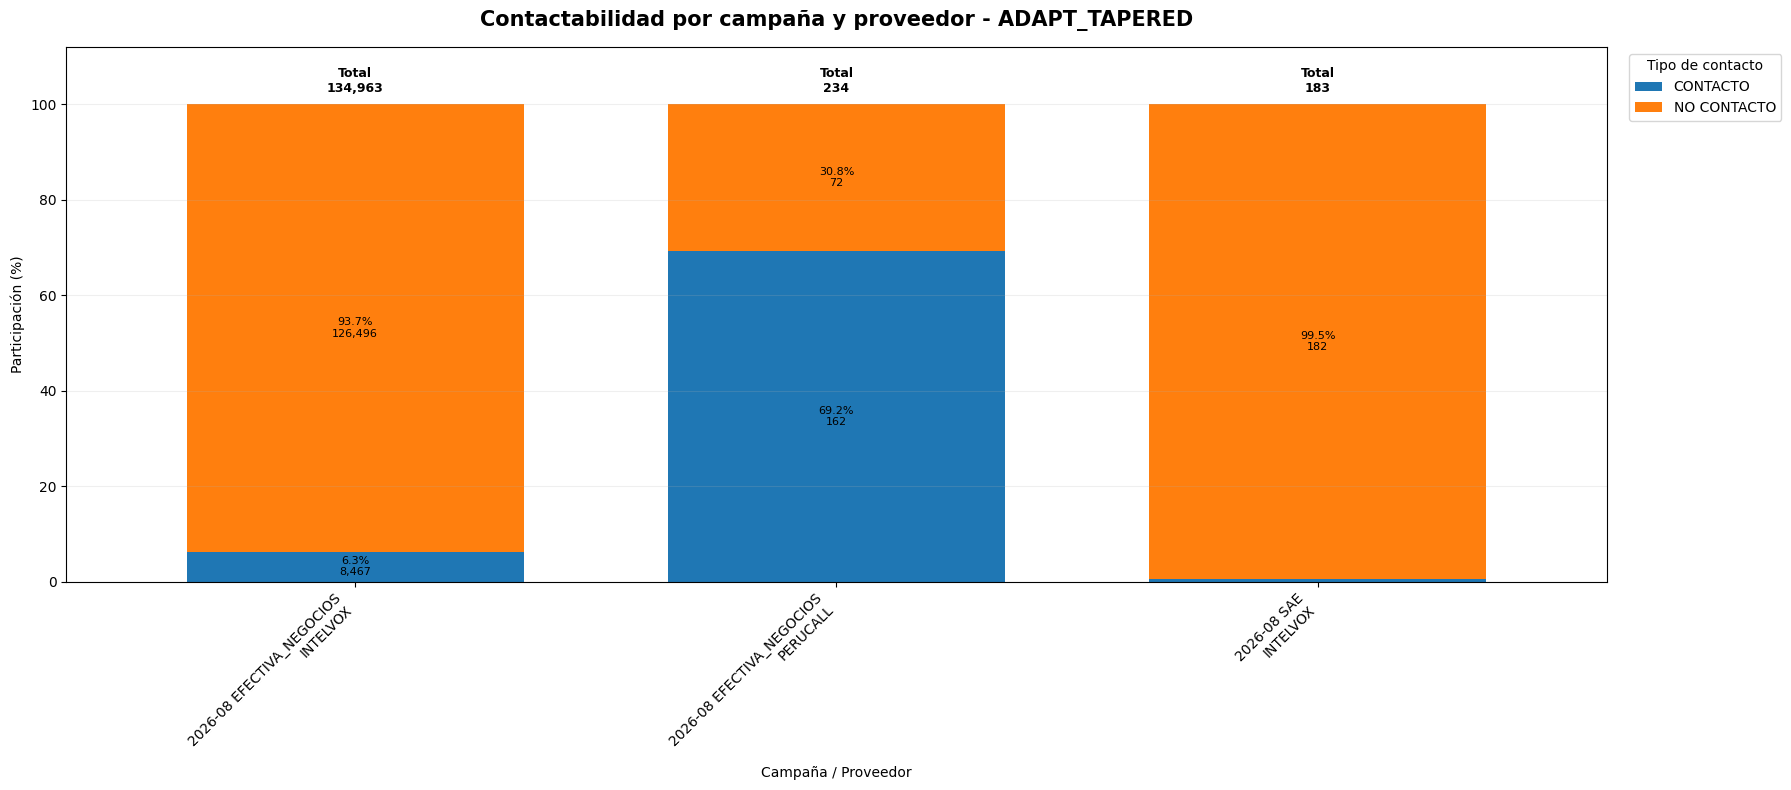

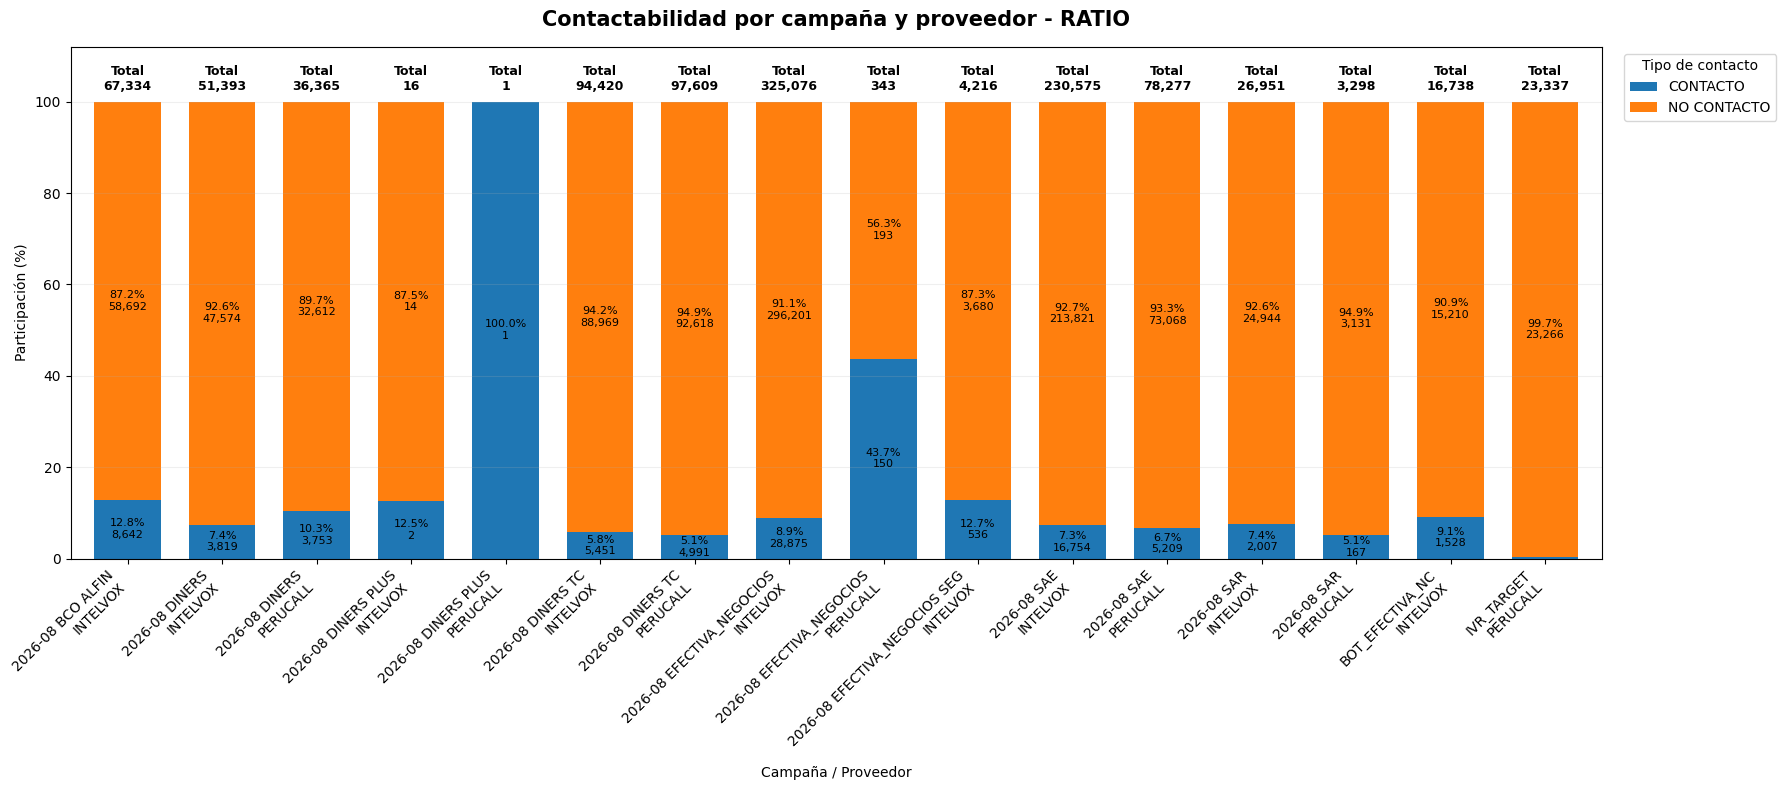

In [41]:
import matplotlib.pyplot as plt

# ============================================================
# ORDEN DE dial_method_historico
# ============================================================

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]

# ============================================================
# GRÁFICO POR dial_method_historico
# ============================================================

for metodo in orden_dial:

    # ========================================================
    # 1. FILTRAR dial_method_historico
    # ========================================================

    df_metodo = df_total_mes_02[
        df_total_mes_02["dial_method_historico"] == metodo
    ].copy()

    if df_metodo.empty:
        continue

    # ========================================================
    # 2. RESUMEN
    # ========================================================

    resumen_campana = (
        df_metodo
        .groupby(
            [
                "nombre_campana",
                "proveedor",
                "tipo_contacto"
            ],
            dropna=False
        )
        .size()
        .reset_index(name="cantidad")
    )

    # ========================================================
    # 3. TOTAL CAMPAÑA + PROVEEDOR
    # ========================================================

    resumen_campana["total"] = (
        resumen_campana
        .groupby(
            [
                "nombre_campana",
                "proveedor"
            ]
        )["cantidad"]
        .transform("sum")
    )

    # ========================================================
    # 4. PORCENTAJE
    # ========================================================

    resumen_campana["porcentaje"] = (
        resumen_campana["cantidad"]
        / resumen_campana["total"]
        * 100
    )

    # ========================================================
    # 5. ETIQUETA EJE X
    # ========================================================

    resumen_campana["grupo"] = (
        resumen_campana["nombre_campana"].astype(str)
        + "\n"
        + resumen_campana["proveedor"].astype(str)
    )

    # ========================================================
    # 6. PIVOT PORCENTAJES
    # ========================================================

    pivot_pct = resumen_campana.pivot_table(
        index="grupo",
        columns="tipo_contacto",
        values="porcentaje",
        aggfunc="sum",
        fill_value=0
    )

    # ========================================================
    # 7. PIVOT CANTIDADES
    # ========================================================

    pivot_cantidad = resumen_campana.pivot_table(
        index="grupo",
        columns="tipo_contacto",
        values="cantidad",
        aggfunc="sum",
        fill_value=0
    )

    # ========================================================
    # 8. ORDEN DE COLUMNAS
    # ========================================================

    columnas = [
        x
        for x in [
            "CONTACTO",
            "NO CONTACTO"
        ]
        if x in pivot_pct.columns
    ]

    pivot_pct = pivot_pct[columnas]

    pivot_cantidad = (
        pivot_cantidad
        .reindex(
            index=pivot_pct.index,
            columns=columnas,
            fill_value=0
        )
    )

    # ========================================================
    # 9. TOTAL POR BARRA
    # ========================================================

    total_por_barra = (
        pivot_cantidad
        .sum(axis=1)
    )

    # ========================================================
    # 10. GRÁFICO
    # ========================================================

    ax = pivot_pct.plot(
        kind="bar",
        stacked=True,
        figsize=(18, 8),
        width=0.70
    )

    ax.set_title(
        f"Contactabilidad por campaña y proveedor - {metodo}",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Campaña / Proveedor"
    )

    ax.set_ylabel(
        "Participación (%)"
    )

    # Dejamos espacio arriba para el total
    ax.set_ylim(
        0,
        112
    )

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right"
    )

    # ========================================================
    # 11. ETIQUETAS INTERNAS
    # % + CANTIDAD
    # ========================================================

    for container, tipo in zip(
        ax.containers,
        pivot_pct.columns
    ):

        etiquetas = []

        for grupo in pivot_pct.index:

            porcentaje = pivot_pct.loc[
                grupo,
                tipo
            ]

            cantidad = pivot_cantidad.loc[
                grupo,
                tipo
            ]

            if porcentaje >= 3:

                etiquetas.append(
                    f"{porcentaje:.1f}%\n"
                    f"{cantidad:,.0f}"
                )

            else:

                etiquetas.append("")

        ax.bar_label(
            container,
            labels=etiquetas,
            label_type="center",
            fontsize=8
        )

    # ========================================================
    # 12. TOTAL ARRIBA DE CADA BARRA
    # ========================================================

    for i, total in enumerate(total_por_barra):

        ax.text(
            i,
            102,
            f"Total\n{total:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    # ========================================================
    # 13. LEYENDA
    # ========================================================

    ax.legend(
        title="Tipo de contacto",
        bbox_to_anchor=(1.01, 1),
        loc="upper left"
    )

    ax.grid(
        axis="y",
        alpha=0.20
    )

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# 1. COPIA
# ============================================================

df_intentos = df_total_mes_02.copy()

df_intentos["fecha_hora_llamada"] = pd.to_datetime(
    df_intentos["fecha_hora_llamada"]
)

# ============================================================
# 2. ORDENAR CRONOLÓGICAMENTE
# campaña + método + proveedor + cliente
# ============================================================

df_intentos = df_intentos.sort_values(
    [
        "nombre_campana",
        "dial_method_historico",
        "proveedor",
        "vendor_lead_code",
        "fecha_hora_llamada"
    ]
)

# ============================================================
# 3. NUMERAR INTENTOS
#
# Se reinicia para cada:
# campaña + método + proveedor + cliente
# ============================================================

df_intentos["nro_intento"] = (
    df_intentos
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code"
        ]
    )
    .cumcount()
    + 1
)

# ============================================================
# 4. RANGO DE INTENTOS
# ============================================================

df_intentos["rango_intento"] = np.select(
    [
        df_intentos["nro_intento"] == 1,
        df_intentos["nro_intento"] == 2,
        df_intentos["nro_intento"] == 3,
        df_intentos["nro_intento"] == 4,
        df_intentos["nro_intento"] >= 5
    ],
    [
        "1 intento",
        "2 intentos",
        "3 intentos",
        "4 intentos",
        "5+ intentos"
    ],
    default="SIN CLASIFICAR"
)

# ============================================================
# 5. SOLO CONTACTOS
# ============================================================

df_contactos = df_intentos[
    df_intentos["tipo_contacto"] == "CONTACTO"
].copy()

# ============================================================
# 6. PRIMER CONTACTO
#
# Primer contacto por:
# campaña + método + proveedor + cliente
# ============================================================

primer_contacto = (
    df_contactos
    .sort_values(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code",
            "nro_intento"
        ]
    )
    .drop_duplicates(
        subset=[
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code"
        ],
        keep="first"
    )
)

# ============================================================
# 7. RESUMEN
# ============================================================

resumen_intentos = (
    primer_contacto
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ]
    )
    .agg(
        clientes_contactados=(
            "vendor_lead_code",
            "nunique"
        ),
        promedio_intentos=(
            "nro_intento",
            "mean"
        ),
        mediana_intentos=(
            "nro_intento",
            "median"
        ),
        max_intentos=(
            "nro_intento",
            "max"
        )
    )
    .reset_index()
)

distribucion_intentos = (
    df_intentos
    .groupby(
        [
            "nombre_campana",
            "proveedor",
            "dial_method_historico",
            "rango_intento"
        ],
        dropna=False,
        observed=False
    )
    .size()
    .reset_index(name="cantidad")
)


# ============================================================
# 3. TOTAL POR CAMPAÑA + PROVEEDOR + MÉTODO
# ============================================================

distribucion_intentos["total"] = (
    distribucion_intentos
    .groupby(
        [
            "nombre_campana",
            "proveedor",
            "dial_method_historico"
        ]
    )["cantidad"]
    .transform("sum")
)

distribucion_intentos["porcentaje"] = (
    distribucion_intentos["cantidad"]
    / distribucion_intentos["total"]
    * 100
)

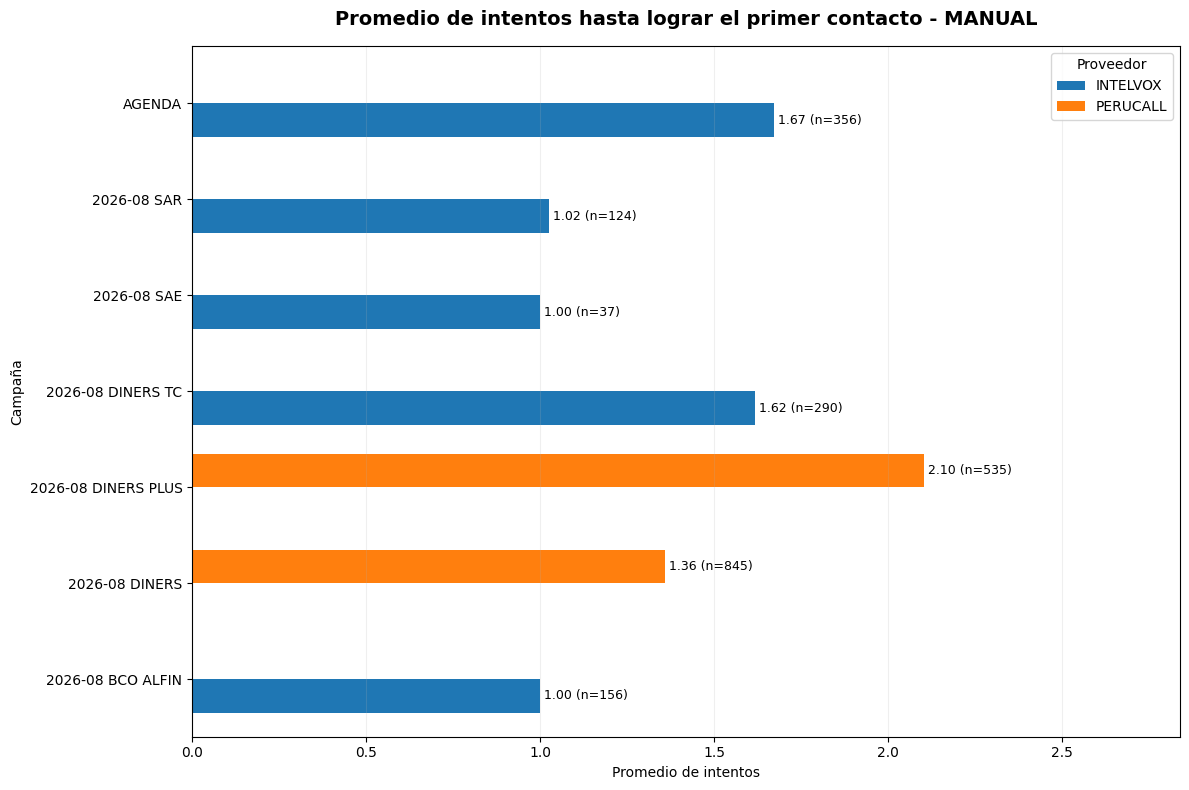

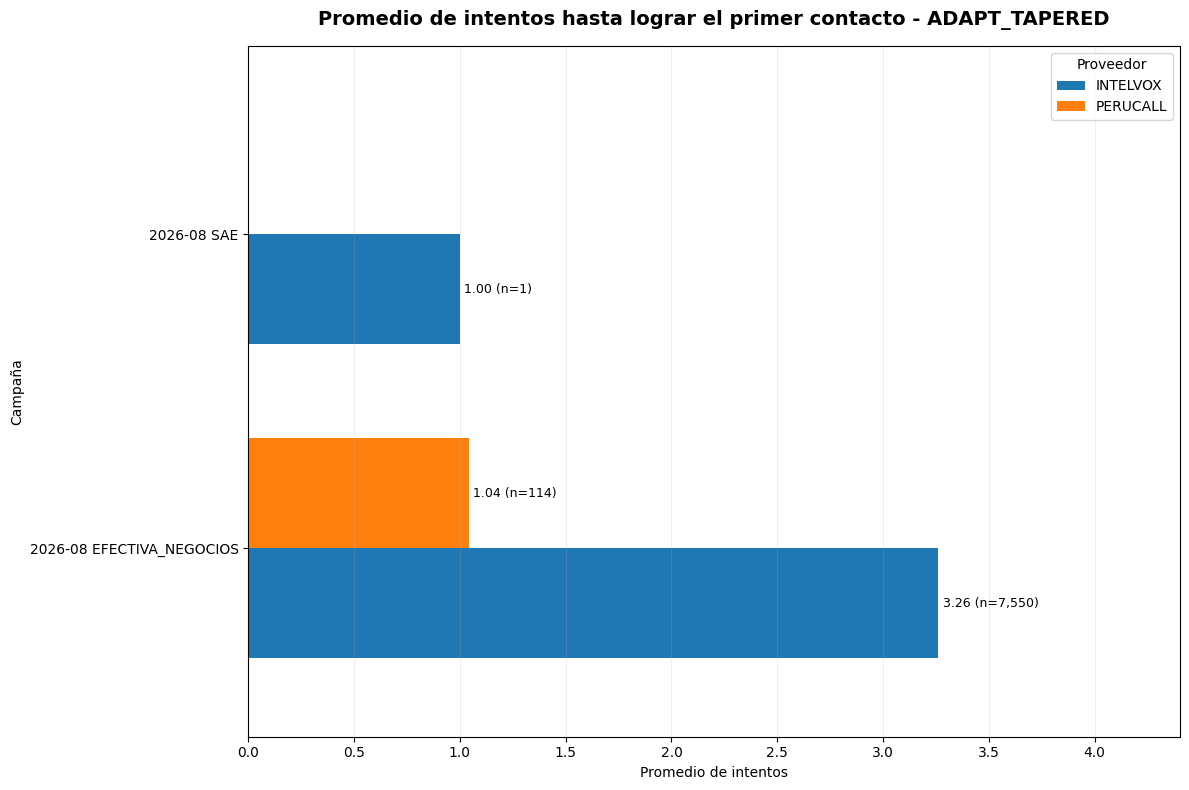

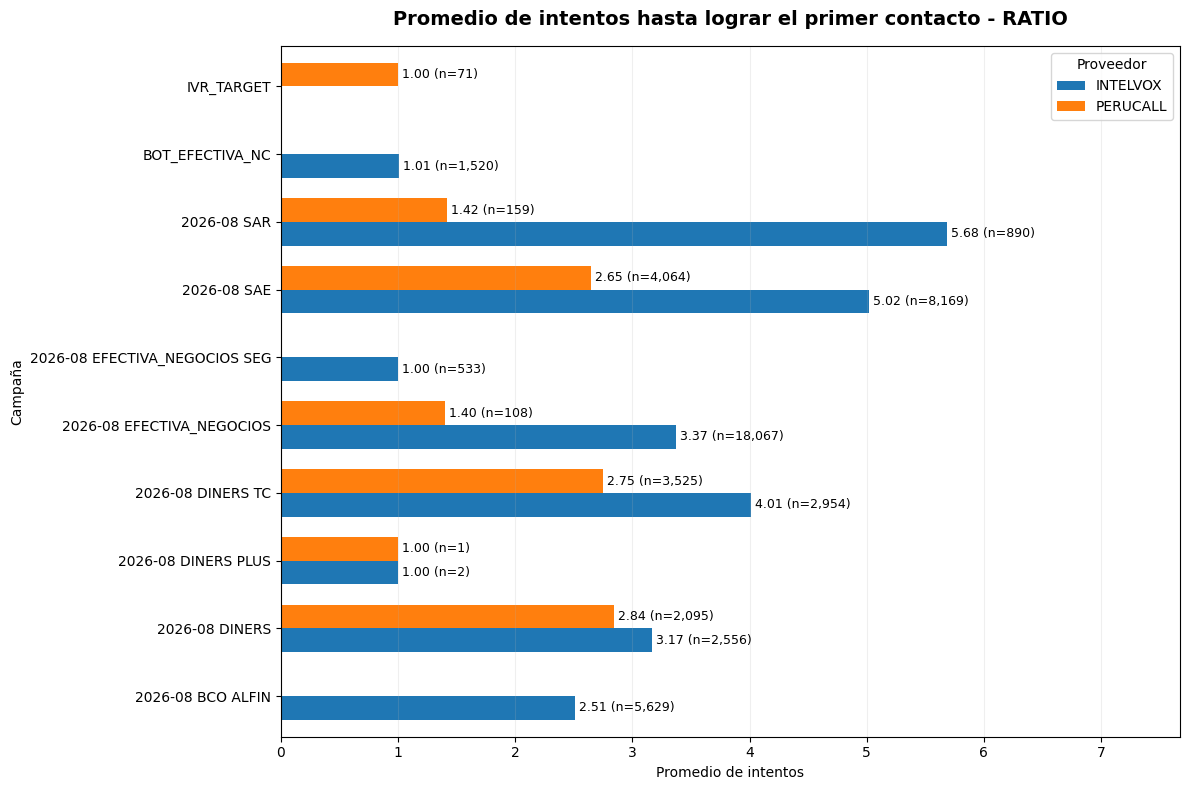

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ORDEN DE dial_method_historico
# ============================================================

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]


# ============================================================
# GRÁFICO POR dial_method_historico
# ============================================================

for metodo in orden_dial:

    # ========================================================
    # 1. FILTRAR dial_method_historico
    # ========================================================

    df_plot = resumen_intentos[
        resumen_intentos["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    # ========================================================
    # 2. ORDENAR
    # ========================================================

    df_plot = df_plot.sort_values(
        [
            "nombre_campana",
            "proveedor"
        ]
    )

    # ========================================================
    # 3. PIVOT PROMEDIO DE INTENTOS
    # ========================================================

    pivot_promedio = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="promedio_intentos",
        aggfunc="mean"
    )

    # ========================================================
    # 4. PIVOT CANTIDAD DE CLIENTES
    # ========================================================

    pivot_clientes = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="clientes_contactados",
        aggfunc="sum"
    )

    # ========================================================
    # 5. ORDENAR PROVEEDORES
    # ========================================================

    proveedores = [
        x
        for x in [
            "INTELVOX",
            "PERUCALL"
        ]
        if x in pivot_promedio.columns
    ]

    pivot_promedio = pivot_promedio[
        proveedores
    ]

    pivot_clientes = (
        pivot_clientes
        .reindex(
            index=pivot_promedio.index,
            columns=proveedores
        )
    )

    # ========================================================
    # 6. GRÁFICO
    # ========================================================

    ax = pivot_promedio.plot(
        kind="barh",
        figsize=(12, 8),
        width=0.70
    )

    ax.set_title(
        f"Promedio de intentos hasta lograr el primer contacto - {metodo}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Promedio de intentos"
    )

    ax.set_ylabel(
        "Campaña"
    )

    # ========================================================
    # 7. ETIQUETAS
    # Promedio + número de clientes
    # ========================================================

    for container, proveedor in zip(
        ax.containers,
        pivot_promedio.columns
    ):

        etiquetas = []

        for campana in pivot_promedio.index:

            promedio = pivot_promedio.loc[
                campana,
                proveedor
            ]

            clientes = pivot_clientes.loc[
                campana,
                proveedor
            ]

            if (
                not np.isnan(promedio)
                and not np.isnan(clientes)
            ):

                etiquetas.append(
                    f"{promedio:.2f} "
                    f"(n={clientes:,.0f})"
                )

            else:

                etiquetas.append("")

        ax.bar_label(
            container,
            labels=etiquetas,
            padding=3,
            fontsize=9
        )

    # ========================================================
    # 8. LEYENDA
    # ========================================================

    ax.legend(
        title="Proveedor"
    )

    ax.grid(
        axis="x",
        alpha=0.20
    )

    # ========================================================
    # 9. ESPACIO PARA ETIQUETAS
    # ========================================================

    maximo = pivot_promedio.max().max()

    if pd.notna(maximo):

        ax.set_xlim(
            0,
            maximo * 1.35
        )

    plt.tight_layout()
    plt.show()

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. COPIA DE LA TABLA ORIGEN
# ============================================================

df_intentos = df_total_mes_02.copy()


# ============================================================
# 2. NORMALIZAR CAMPOS
# ============================================================

df_intentos["fecha_hora_llamada"] = pd.to_datetime(
    df_intentos["fecha_hora_llamada"],
    errors="coerce"
)

columnas_texto = [
    "nombre_campana",
    "dial_method_historico",
    "proveedor",
    "vendor_lead_code",
    "tipo_contacto"
]

for col in columnas_texto:

    df_intentos[col] = (
        df_intentos[col]
        .astype("string")
        .str.strip()
    )


df_intentos["dial_method_historico"] = (
    df_intentos["dial_method_historico"]
    .str.upper()
)

df_intentos["proveedor"] = (
    df_intentos["proveedor"]
    .str.upper()
)

df_intentos["tipo_contacto"] = (
    df_intentos["tipo_contacto"]
    .str.upper()
)


# ============================================================
# 3. ELIMINAR REGISTROS SIN INFORMACIÓN CLAVE
# ============================================================

df_intentos = df_intentos.dropna(
    subset=[
        "nombre_campana",
        "dial_method_historico",
        "proveedor",
        "vendor_lead_code",
        "fecha_hora_llamada"
    ]
).copy()


# ============================================================
# 4. ORDENAR CRONOLÓGICAMENTE
#
# El intento se calcula dentro de:
# campaña + método + proveedor + cliente
# ============================================================

df_intentos = (
    df_intentos
    .sort_values(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code",
            "fecha_hora_llamada"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. NUMERAR LOS INTENTOS
# ============================================================

df_intentos["nro_intento"] = (
    df_intentos
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code"
        ],
        dropna=False
    )
    .cumcount()
    + 1
)


# ============================================================
# 6. FILTRAR SOLO CONTACTOS
# ============================================================

df_contactos = df_intentos[
    df_intentos["tipo_contacto"] == "CONTACTO"
].copy()


# ============================================================
# 7. OBTENER EL PRIMER CONTACTO DEL CLIENTE
#
# Si un cliente tuvo:
#
# intento 1 -> NO CONTACTO
# intento 2 -> NO CONTACTO
# intento 3 -> CONTACTO
# intento 4 -> CONTACTO
#
# Nos quedamos solamente con intento 3.
# ============================================================

primer_contacto = (
    df_contactos
    .sort_values(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code",
            "nro_intento"
        ]
    )
    .drop_duplicates(
        subset=[
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code"
        ],
        keep="first"
    )
    .copy()
)


# ============================================================
# 8. CLASIFICAR EN RANGO DE INTENTO
# ============================================================

primer_contacto["rango_intento"] = np.select(
    [
        primer_contacto["nro_intento"] == 1,
        primer_contacto["nro_intento"] == 2,
        primer_contacto["nro_intento"] == 3,
        primer_contacto["nro_intento"] == 4,
        primer_contacto["nro_intento"] >= 5
    ],
    [
        "1 intento",
        "2 intentos",
        "3 intentos",
        "4 intentos",
        "5+ intentos"
    ],
    default="SIN CLASIFICAR"
)


# ============================================================
# 9. RESUMEN DE PROMEDIO DE INTENTOS
# ============================================================

resumen_intentos = (
    primer_contacto
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ],
        dropna=False
    )
    .agg(
        clientes_contactados=(
            "vendor_lead_code",
            "nunique"
        ),

        promedio_intentos=(
            "nro_intento",
            "mean"
        ),

        mediana_intentos=(
            "nro_intento",
            "median"
        ),

        max_intentos=(
            "nro_intento",
            "max"
        )
    )
    .reset_index()
)


# ============================================================
# 10. DISTRIBUCIÓN DEL PRIMER CONTACTO
#
# IMPORTANTE:
# Sale de primer_contacto, NO de df_intentos.
# ============================================================

distribucion_intentos = (
    primer_contacto
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "rango_intento"
        ],
        dropna=False,
        observed=False
    )
    .agg(
        clientes=(
            "vendor_lead_code",
            "nunique"
        )
    )
    .reset_index()
)


# ============================================================
# 11. TOTAL DE CLIENTES CONTACTADOS
# POR CAMPAÑA + MÉTODO + PROVEEDOR
# ============================================================

distribucion_intentos["total_clientes"] = (
    distribucion_intentos
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ],
        dropna=False
    )["clientes"]
    .transform("sum")
)


# ============================================================
# 12. PORCENTAJE
# ============================================================

distribucion_intentos["porcentaje"] = np.where(
    distribucion_intentos["total_clientes"] > 0,

    (
        distribucion_intentos["clientes"]
        / distribucion_intentos["total_clientes"]
        * 100
    ),

    0
)


# ============================================================
# 13. VALIDACIÓN
#
# Cada campaña/proveedor/método debe sumar aproximadamente 100%
# ============================================================

validacion_porcentaje = (
    distribucion_intentos
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ],
        dropna=False
    )["porcentaje"]
    .sum()
    .reset_index(name="total_porcentaje")
)

print("\nVALIDACIÓN PORCENTAJES:")
print(validacion_porcentaje)


# ============================================================
# 14. VER DISTRIBUCIÓN
# ============================================================

print("\nDISTRIBUCIÓN:")
print(
    distribucion_intentos
    .sort_values(
        [
            "dial_method_historico",
            "nombre_campana",
            "proveedor",
            "rango_intento"
        ]
    )
)


VALIDACIÓN PORCENTAJES:
                   nombre_campana dial_method_historico proveedor  \
0               2026-08 BCO ALFIN                MANUAL  INTELVOX   
1               2026-08 BCO ALFIN                 RATIO  INTELVOX   
2                  2026-08 DINERS                MANUAL  PERUCALL   
3                  2026-08 DINERS                 RATIO  INTELVOX   
4                  2026-08 DINERS                 RATIO  PERUCALL   
5             2026-08 DINERS PLUS                MANUAL  PERUCALL   
6             2026-08 DINERS PLUS                 RATIO  INTELVOX   
7             2026-08 DINERS PLUS                 RATIO  PERUCALL   
8               2026-08 DINERS TC                MANUAL  INTELVOX   
9               2026-08 DINERS TC                 RATIO  INTELVOX   
10              2026-08 DINERS TC                 RATIO  PERUCALL   
11      2026-08 EFECTIVA_NEGOCIOS         ADAPT_TAPERED  INTELVOX   
12      2026-08 EFECTIVA_NEGOCIOS         ADAPT_TAPERED  PERUCALL   
13      2

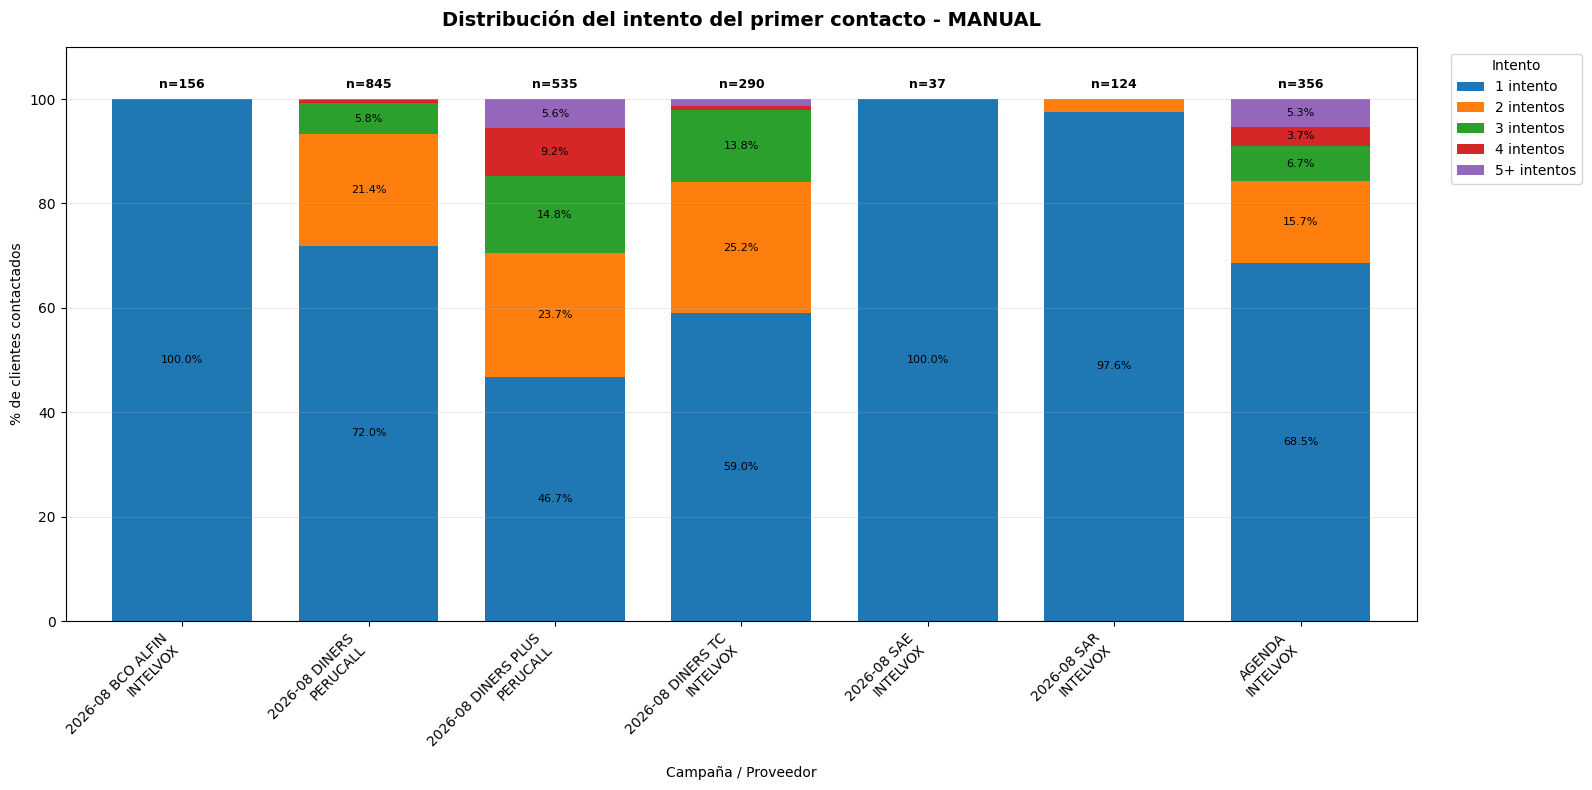

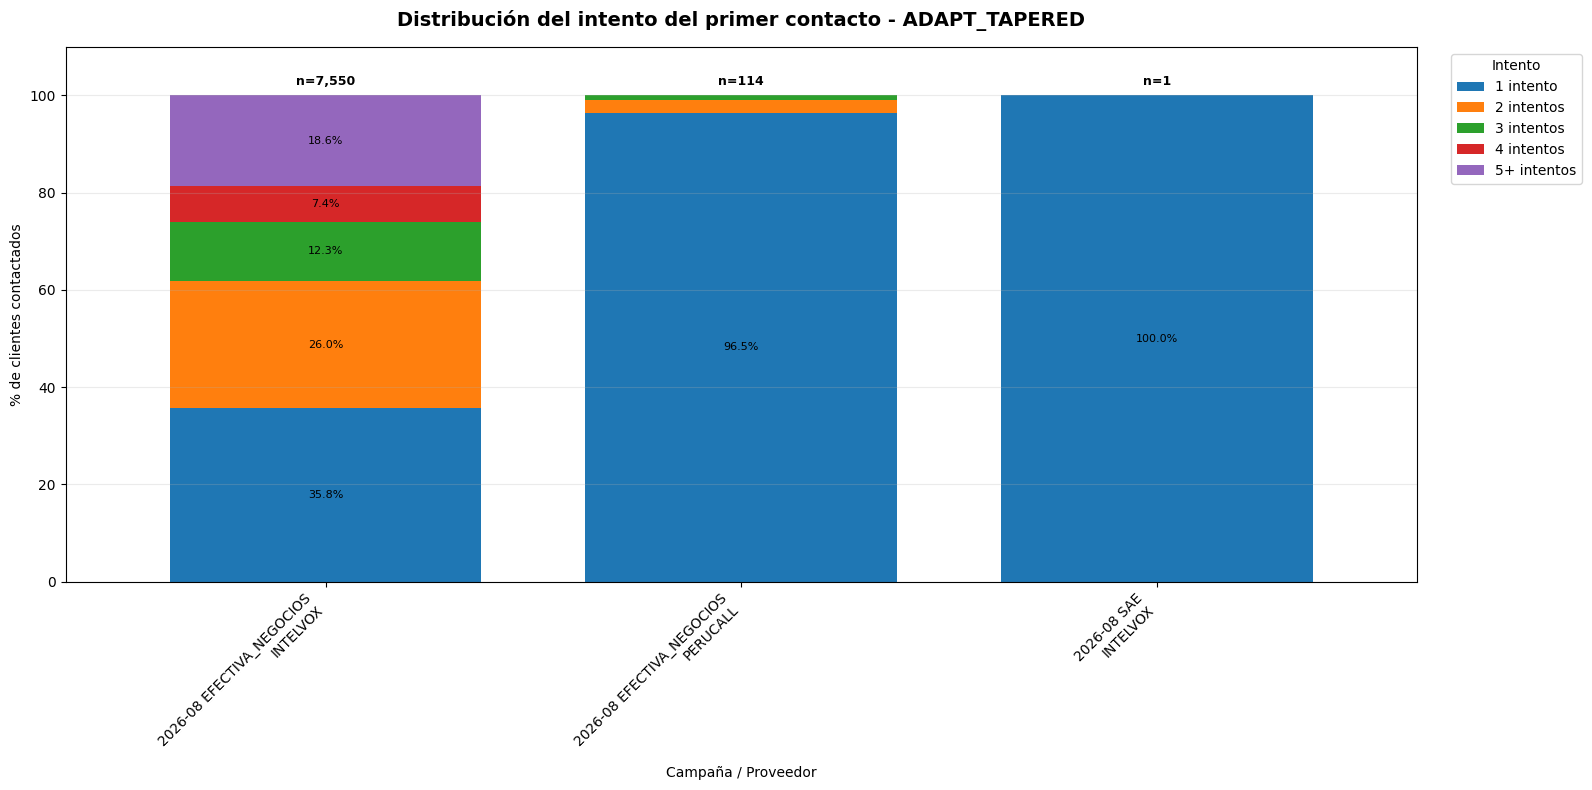

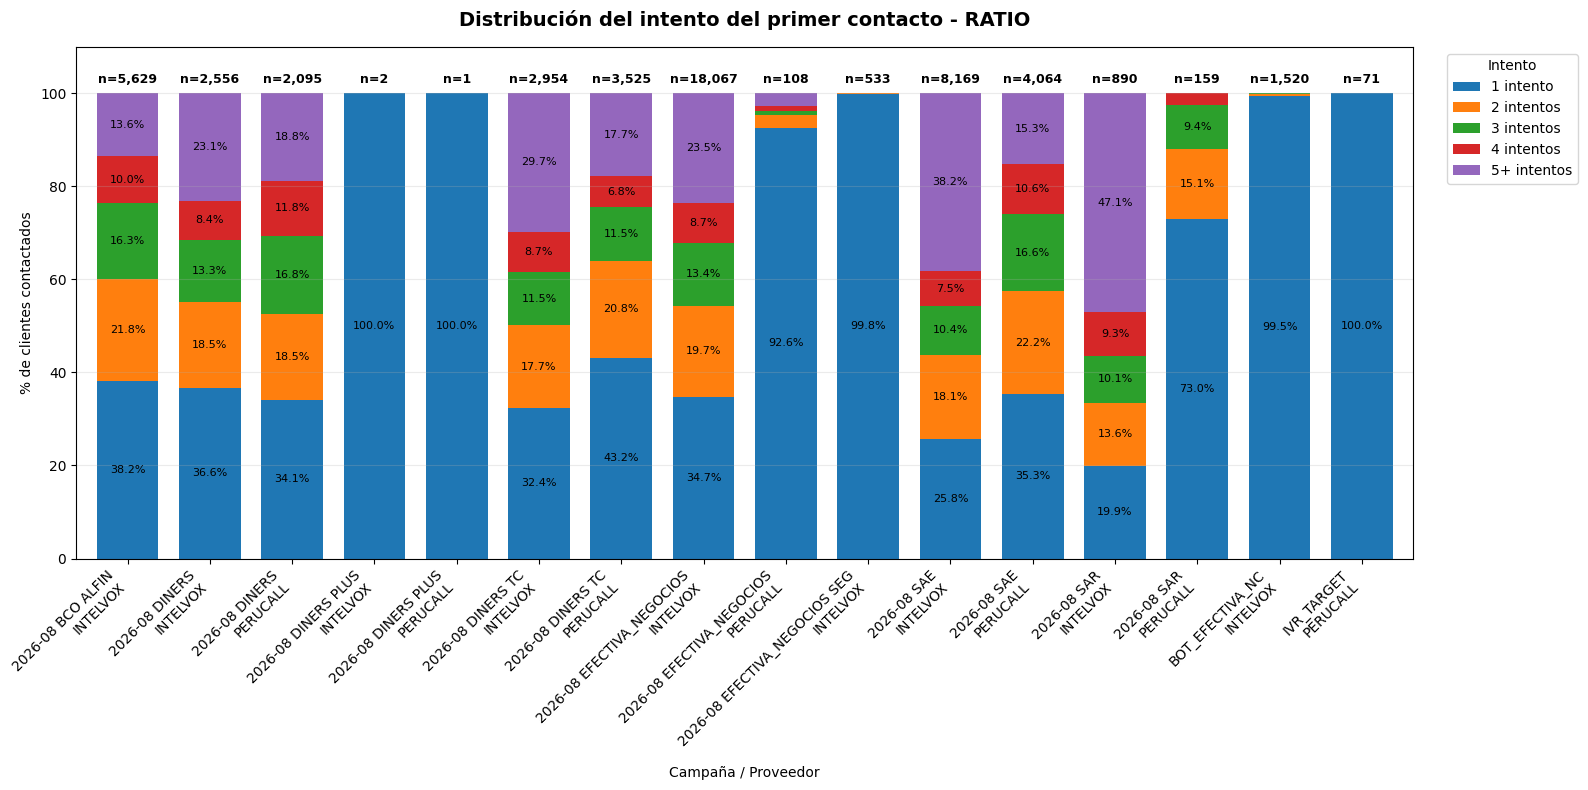

In [55]:
# ============================================================
# 15. ORDEN DE LOS INTENTOS
# ============================================================

orden_intentos = [
    "1 intento",
    "2 intentos",
    "3 intentos",
    "4 intentos",
    "5+ intentos"
]


# ============================================================
# 16. ORDEN DE DIAL METHOD
# ============================================================

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]


# ============================================================
# 17. GRÁFICO POR DIAL METHOD HISTÓRICO
# ============================================================

for metodo in orden_dial:

    # ========================================================
    # FILTRAR MÉTODO
    # ========================================================

    df_grafico = distribucion_intentos[
        distribucion_intentos["dial_method_historico"] == metodo
    ].copy()

    if df_grafico.empty:
        continue


    # ========================================================
    # PIVOT DE PORCENTAJES
    # ========================================================

    pivot = (
        df_grafico
        .pivot_table(
            index=[
                "nombre_campana",
                "proveedor"
            ],
            columns="rango_intento",
            values="porcentaje",
            aggfunc="sum",
            fill_value=0
        )
    )


    # ========================================================
    # ORDENAR COLUMNAS
    # ========================================================

    pivot = pivot.reindex(
        columns=orden_intentos,
        fill_value=0
    )


    # ========================================================
    # TOTAL DE CLIENTES CONTACTADOS POR BARRA
    #
    # No sumamos total_clientes porque está repetido
    # por cada rango.
    #
    # Usamos max() porque el total es el mismo en cada rango.
    # ========================================================

    total_clientes = (
        df_grafico
        .groupby(
            [
                "nombre_campana",
                "proveedor"
            ]
        )["total_clientes"]
        .max()
        .reindex(pivot.index)
    )


    # ========================================================
    # GRÁFICO
    # ========================================================

    ax = pivot.plot(
        kind="bar",
        stacked=True,
        figsize=(16, 8),
        width=0.75
    )


    # ========================================================
    # PORCENTAJES DENTRO DE LAS BARRAS
    # ========================================================

    for container in ax.containers:

        labels = [

            f"{v:.1f}%"

            if v >= 3

            else ""

            for v in container.datavalues
        ]


        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=8
        )


    # ========================================================
    # TOTAL DE CLIENTES ARRIBA
    # ========================================================

    for i, total in enumerate(total_clientes):

        if pd.notna(total):

            ax.text(
                i,
                101.5,
                f"n={int(total):,}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold"
            )


    # ========================================================
    # ETIQUETAS
    # ========================================================

    etiquetas = [

        f"{campana}\n{proveedor}"

        for campana, proveedor in pivot.index
    ]


    ax.set_xticklabels(
        etiquetas,
        rotation=45,
        ha="right"
    )


    # ========================================================
    # TÍTULO
    # ========================================================

    ax.set_title(
        f"Distribución del intento del primer contacto - {metodo}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )


    ax.set_xlabel(
        "Campaña / Proveedor"
    )


    ax.set_ylabel(
        "% de clientes contactados"
    )


    # ========================================================
    # EJE
    # ========================================================

    ax.set_ylim(
        0,
        110
    )


    # ========================================================
    # LEYENDA
    # ========================================================

    ax.legend(
        title="Intento",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )


    # ========================================================
    # GRILLA
    # ========================================================

    ax.grid(
        axis="y",
        alpha=0.25
    )


    plt.tight_layout()

    plt.show()

### Embudo

In [97]:
import pandas as pd
import numpy as np


# ============================================================
# 1. COPIA
# ============================================================

df_embudo = df_total_mes_02.copy()


# ============================================================
# 2. NORMALIZAR CAMPOS
# ============================================================

columnas_texto = [
    "nombre_campana",
    "dial_method_historico",
    "proveedor",
    "tipo_contacto"
]

for col in columnas_texto:

    df_embudo[col] = (
        df_embudo[col]
        .astype("string")
        .str.strip()
    )


df_embudo["dial_method_historico"] = (
    df_embudo["dial_method_historico"]
    .str.upper()
)

df_embudo["proveedor"] = (
    df_embudo["proveedor"]
    .str.upper()
)

df_embudo["tipo_contacto"] = (
    df_embudo["tipo_contacto"]
    .str.upper()
)


# ============================================================
# 3. SIP NUMÉRICO
# ============================================================

df_embudo["sip_hangup_cause"] = pd.to_numeric(
    df_embudo["sip_hangup_cause"],
    errors="coerce"
)


# ============================================================
# 4. INDICADORES
# ============================================================

# SIP 200
df_embudo["es_sip_200"] = (
    df_embudo["sip_hangup_cause"] == 200
).astype(int)


# CONTACTO
df_embudo["es_contacto"] = (
    df_embudo["tipo_contacto"] == "CONTACTO"
).astype(int)


# NO CONTACTO
df_embudo["es_no_contacto"] = (
    df_embudo["tipo_contacto"] == "NO CONTACTO"
).astype(int)


# SIP 200 PERO NO CONTACTO
df_embudo["sip200_no_contacto"] = (
    (df_embudo["sip_hangup_cause"] == 200)
    &
    (df_embudo["tipo_contacto"] == "NO CONTACTO")
).astype(int)


# ============================================================
# 5. RESUMEN
# ============================================================

embudo = (
    df_embudo
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ],
        dropna=False
    )
    .agg(

        llamadas=(
            "lead_id",
            "size"
        ),

        clientes_unicos=(
            "vendor_lead_code",
            "nunique"
        ),

        sip_200=(
            "es_sip_200",
            "sum"
        ),

        contactos=(
            "es_contacto",
            "sum"
        ),

        no_contactos=(
            "es_no_contacto",
            "sum"
        ),

        sip200_no_contacto=(
            "sip200_no_contacto",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 6. % SIP 200
# ============================================================

embudo["pct_sip_200"] = np.where(

    embudo["llamadas"] > 0,

    embudo["sip_200"]
    / embudo["llamadas"]
    * 100,

    np.nan
)


# ============================================================
# 7. % CONTACTO SOBRE TOTAL LLAMADAS
# ============================================================

embudo["pct_contacto"] = np.where(

    embudo["llamadas"] > 0,

    embudo["contactos"]
    / embudo["llamadas"]
    * 100,

    np.nan
)


# ============================================================
# 8. % CONTACTO SOBRE LAS LLAMADAS SIP 200
# ============================================================

embudo["pct_contacto_sobre_sip200"] = np.where(

    embudo["sip_200"] > 0,

    embudo["contactos"]
    / embudo["sip_200"]
    * 100,

    np.nan
)


# ============================================================
# 9. % SIP 200 QUE TERMINÓ EN NO CONTACTO
# ============================================================

embudo["pct_sip200_no_contacto"] = np.where(

    embudo["sip_200"] > 0,

    embudo["sip200_no_contacto"]
    / embudo["sip_200"]
    * 100,

    np.nan
)


# ============================================================
# 10. CRUZAR CON RESUMEN DE INTENTOS
# ============================================================

embudo_final = embudo.merge(

    resumen_intentos[
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",

            "clientes_contactados",
            "promedio_intentos",
            "mediana_intentos"
        ]
    ],

    on=[
        "nombre_campana",
        "dial_method_historico",
        "proveedor"
    ],

    how="left"
)


# ============================================================
# 11. % DE CLIENTES QUE LOGRARON SER CONTACTADOS
# ============================================================

embudo_final["pct_clientes_contactados"] = np.where(

    embudo_final["clientes_unicos"] > 0,

    embudo_final["clientes_contactados"]
    / embudo_final["clientes_unicos"]
    * 100,

    np.nan
)


# ============================================================
# 12. RESULTADO FINAL
# ============================================================

resultado_final = embudo_final[
    [
        "nombre_campana",
        "dial_method_historico",
        "proveedor",

        "llamadas",
        "clientes_unicos",

        "sip_200",
        "pct_sip_200",

        "contactos",
        "pct_contacto",

        "pct_contacto_sobre_sip200",

        "sip200_no_contacto",
        "pct_sip200_no_contacto",

        "clientes_contactados",
        "pct_clientes_contactados",

        "promedio_intentos",
        "mediana_intentos"
    ]
].copy()


# ============================================================
# 13. ORDENAR
# ============================================================

resultado_final = (
    resultado_final
    .sort_values(
        [
            "dial_method_historico",
            "nombre_campana",
            "proveedor"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 14. MOSTRAR
# ============================================================

resultado_final.round(2)

,nombre_campana,dial_method_historico,proveedor,llamadas,clientes_unicos,sip_200,pct_sip_200,contactos,pct_contacto,pct_contacto_sobre_sip200,sip200_no_contacto,pct_sip200_no_contacto,clientes_contactados,pct_clientes_contactados,promedio_intentos,mediana_intentos
0,2026-08 EFECTIVA_NEGOCIOS,ADAPT_TAPERED,INTELVOX,134963,30796,76567,56.73,8467,6.27,11.06,68158,89.02,7550.0,24.52,3.26,2.0
1,2026-08 EFECTIVA_NEGOCIOS,ADAPT_TAPERED,PERUCALL,234,159,134,57.26,162,69.23,120.90,28,20.90,114.0,71.70,1.04,1.0
2,2026-08 SAE,ADAPT_TAPERED,INTELVOX,183,183,134,73.22,1,0.55,0.75,133,99.25,1.0,0.55,1.00,1.0
3,2026-08 BCO ALFIN,MANUAL,INTELVOX,528,525,221,41.86,158,29.92,71.49,113,51.13,156.0,29.71,1.00,1.0
4,2026-08 DINERS,MANUAL,INTELVOX,20,20,19,95.00,0,0.00,0.00,19,100.00,NaN,NaN,NaN,NaN
5,2026-08 DINERS,MANUAL,PERUCALL,5837,3180,3337,57.17,1150,19.70,34.46,2288,68.56,845.0,26.57,1.36,1.0
6,2026-08 DINERS PLUS,MANUAL,INTELVOX,4,4,4,100.00,0,0.00,0.00,4,100.00,NaN,NaN,NaN,NaN
7,2026-08 DINERS PLUS,MANUAL,PERUCALL,5302,1210,3089,58.26,1422,26.82,46.03,1879,60.83,535.0,44.21,2.10,2.0
8,2026-08 DINERS TC,MANUAL,INTELVOX,2104,921,1310,62.26,435,20.67,33.21,920,70.23,290.0,31.49,1.62,1.0
9,2026-08 SAE,MANUAL,INTELVOX,189,188,107,56.61,38,20.11,35.51,72,67.29,37.0,19.68,1.00,1.0


In [99]:
resultado_final.columns

Index(['nombre_campana', 'dial_method_historico', 'proveedor', 'llamadas',
       'clientes_unicos', 'sip_200', 'pct_sip_200', 'contactos',
       'pct_contacto', 'pct_contacto_sobre_sip200', 'sip200_no_contacto',
       'pct_sip200_no_contacto', 'clientes_contactados',
       'pct_clientes_contactados', 'promedio_intentos', 'mediana_intentos'],
      dtype='object')

In [98]:

ruta_archivo = os.path.join(ruta_csv, 'vicidial_.csv')
resultado_final.to_csv(ruta_archivo, sep=';')

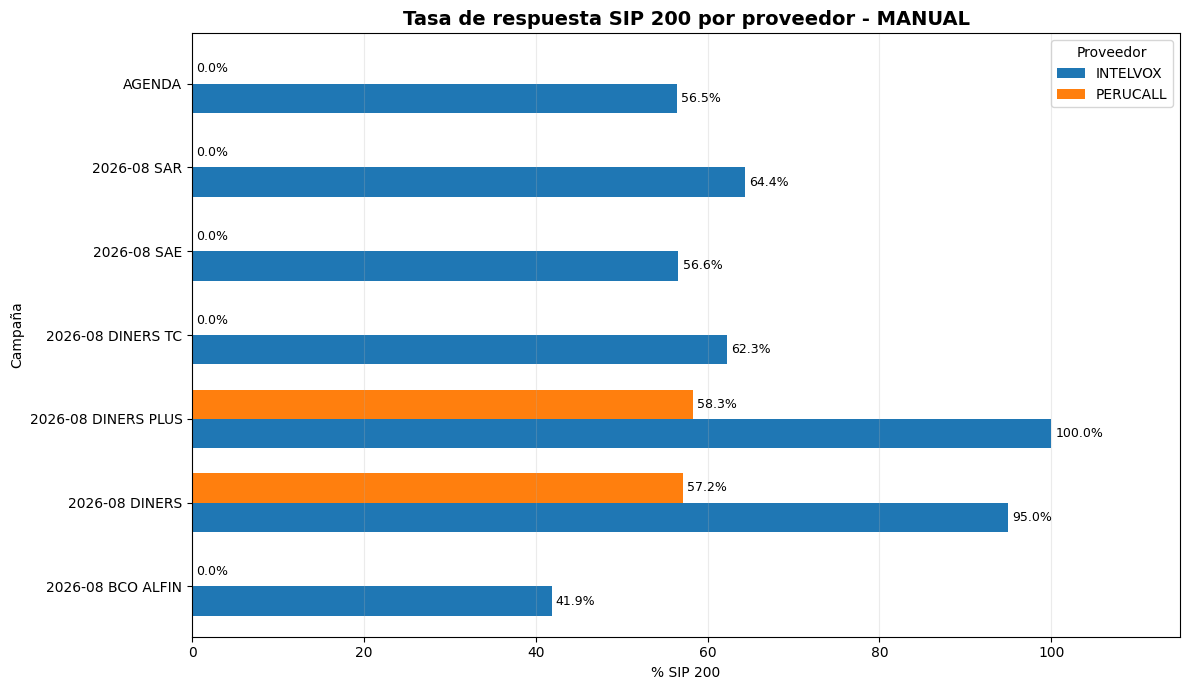

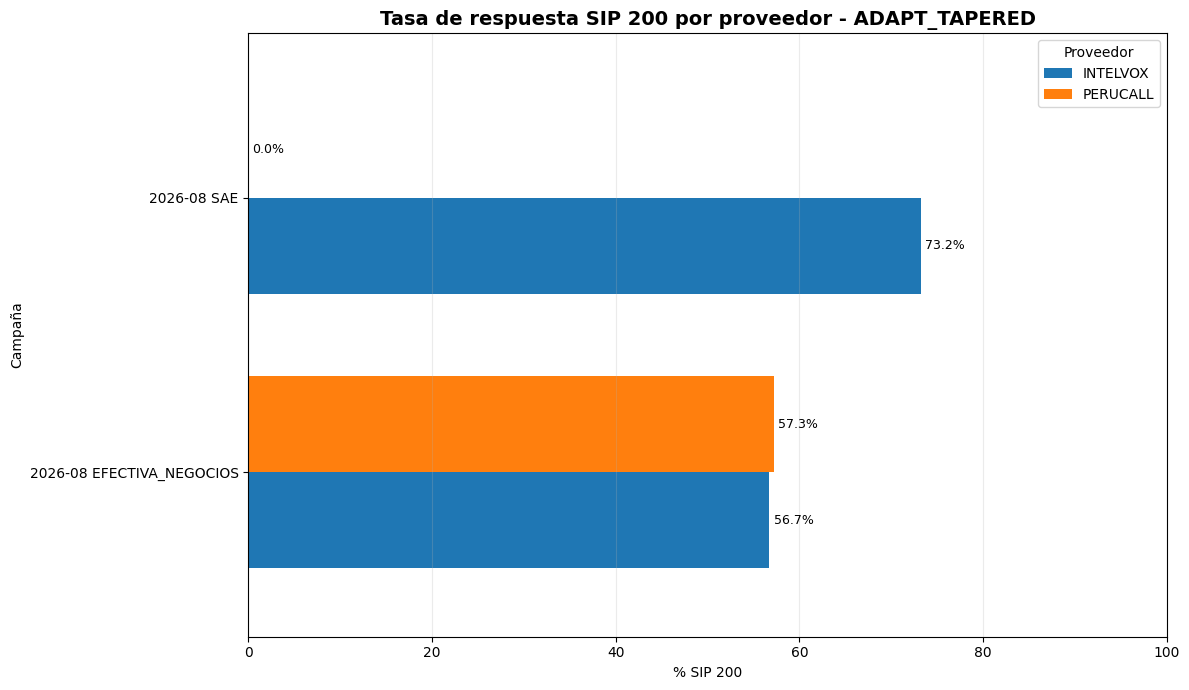

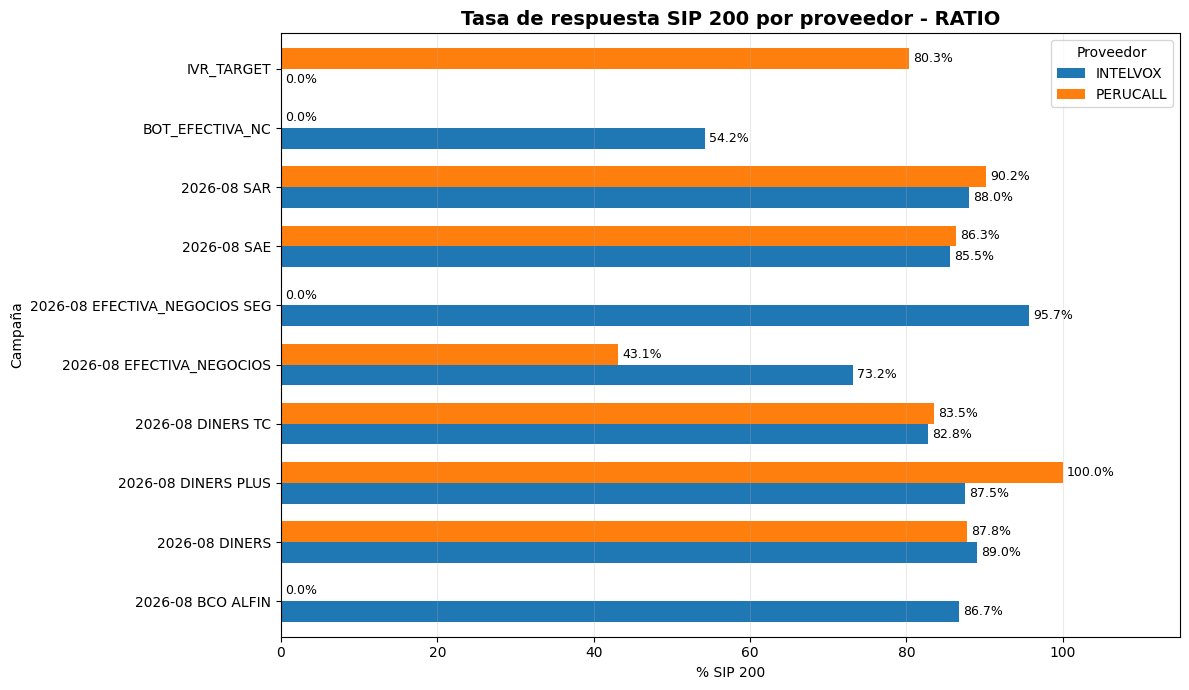

In [100]:
import matplotlib.pyplot as plt
import pandas as pd

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]

for metodo in orden_dial:

    df_plot = resultado_final[
        resultado_final["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    pivot = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="pct_sip_200",
        aggfunc="mean"
    )

    proveedores = [
        p for p in ["INTELVOX", "PERUCALL"]
        if p in pivot.columns
    ]

    pivot = pivot[proveedores]

    ax = pivot.plot(
        kind="barh",
        figsize=(12, 7),
        width=0.7
    )

    for container in ax.containers:

        labels = [
            f"{v:.1f}%" if pd.notna(v) else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_title(
        f"Tasa de respuesta SIP 200 por proveedor - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("% SIP 200")
    ax.set_ylabel("Campaña")

    ax.set_xlim(
        0,
        max(100, pivot.max().max() * 1.15)
    )

    ax.legend(title="Proveedor")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

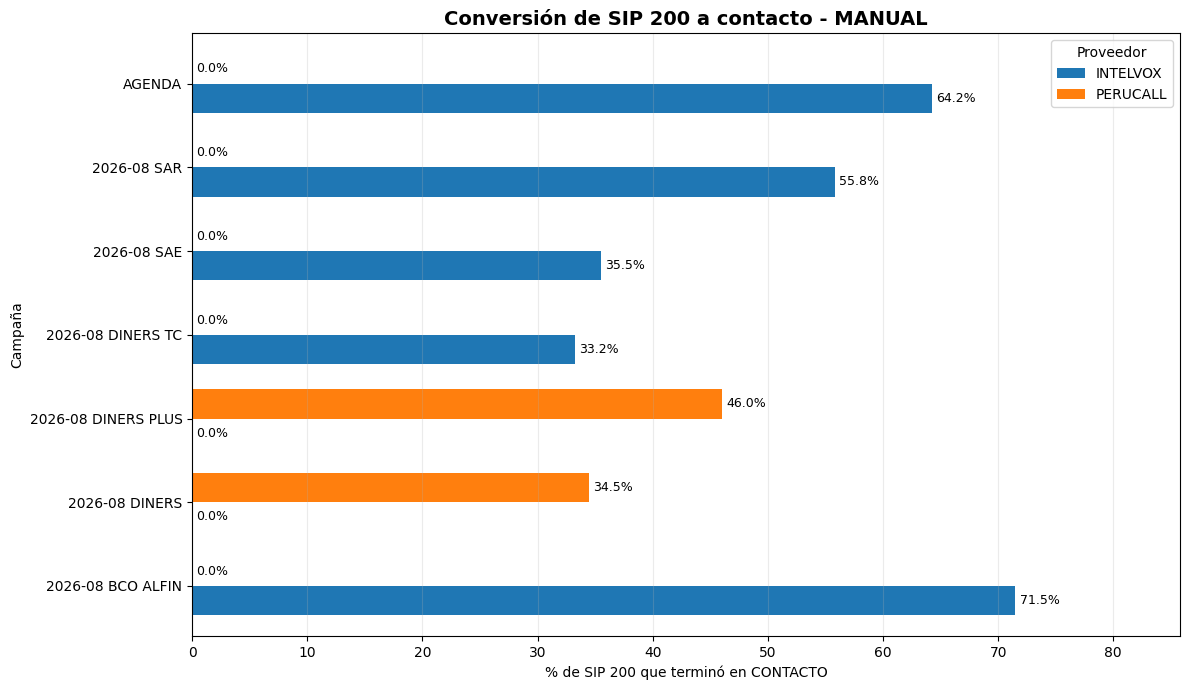

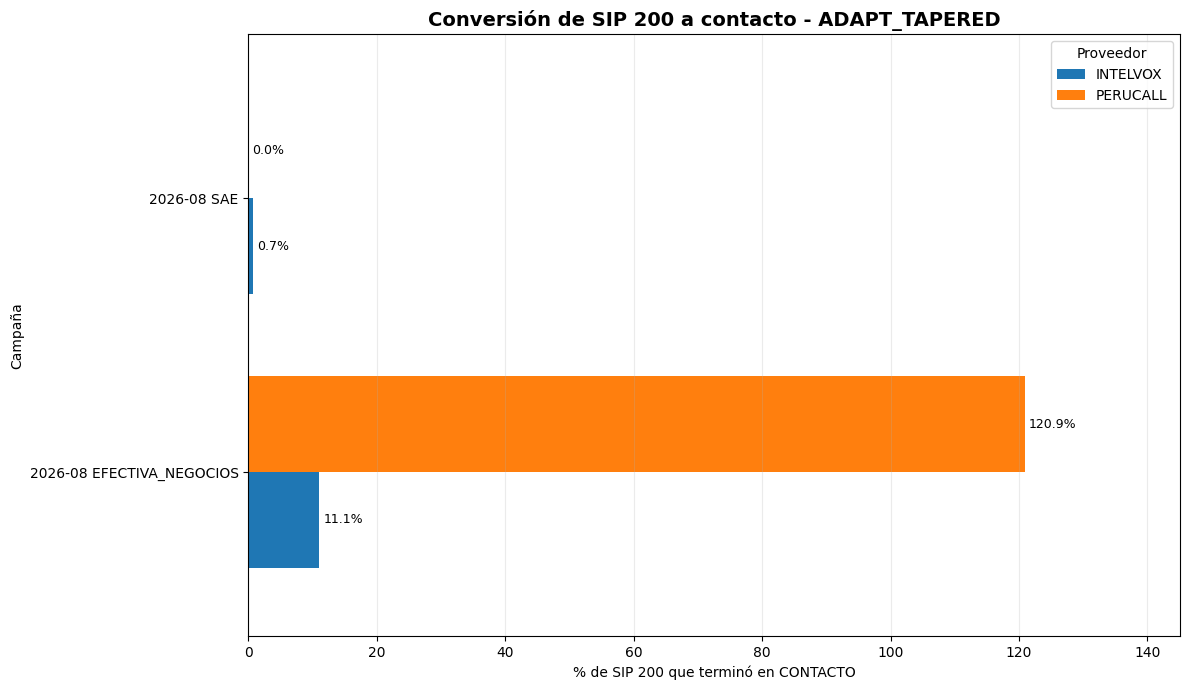

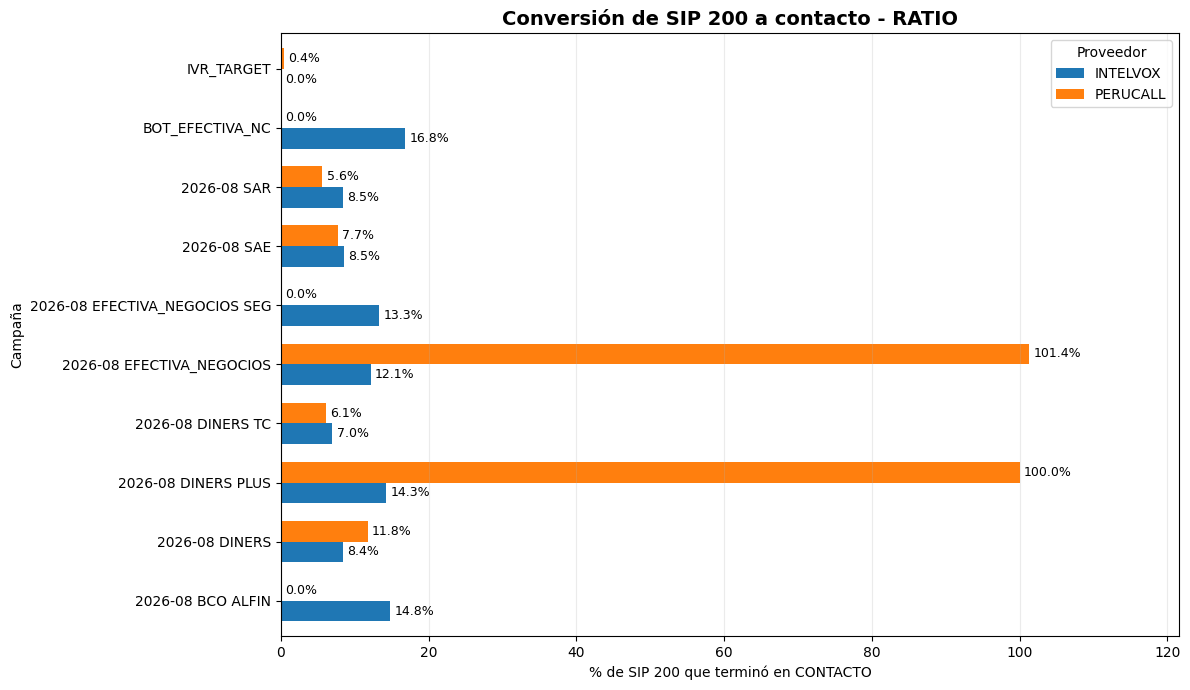

In [101]:
for metodo in orden_dial:

    df_plot = resultado_final[
        resultado_final["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    pivot = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="pct_contacto_sobre_sip200",
        aggfunc="mean"
    )

    proveedores = [
        p for p in ["INTELVOX", "PERUCALL"]
        if p in pivot.columns
    ]

    pivot = pivot[proveedores]

    ax = pivot.plot(
        kind="barh",
        figsize=(12, 7),
        width=0.7
    )

    for container in ax.containers:

        labels = [
            f"{v:.1f}%" if pd.notna(v) else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_title(
        f"Conversión de SIP 200 a contacto - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("% de SIP 200 que terminó en CONTACTO")
    ax.set_ylabel("Campaña")

    maximo = pivot.max().max()

    if pd.notna(maximo):
        ax.set_xlim(0, maximo * 1.20)

    ax.legend(title="Proveedor")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

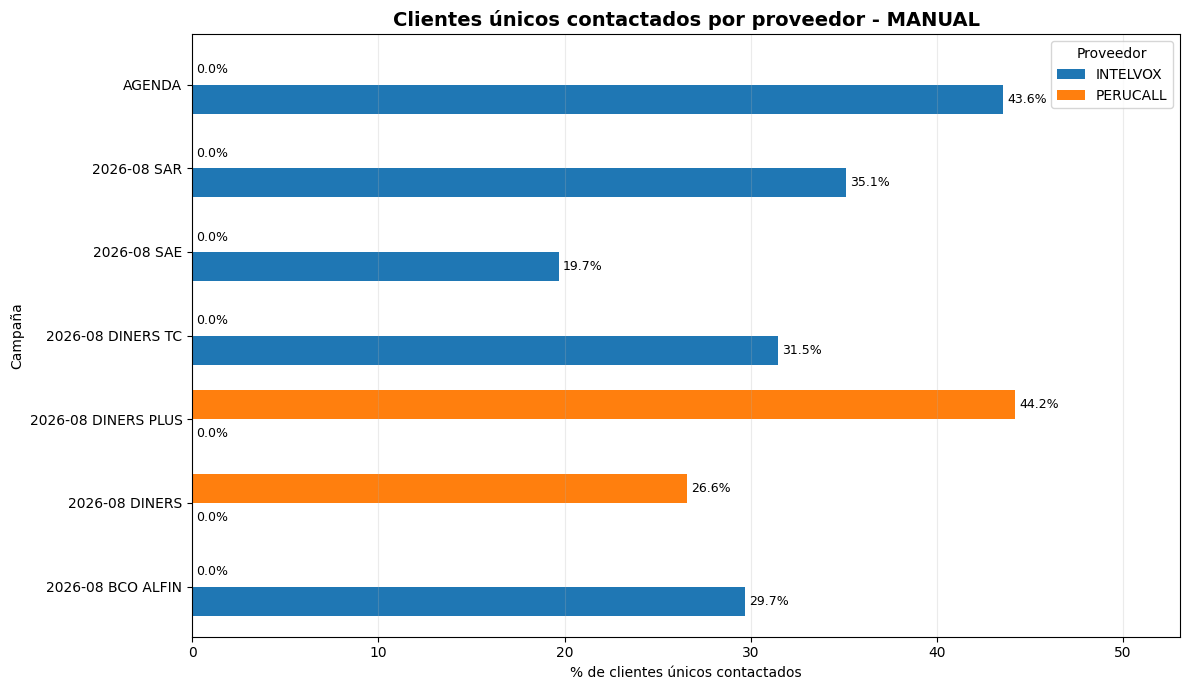

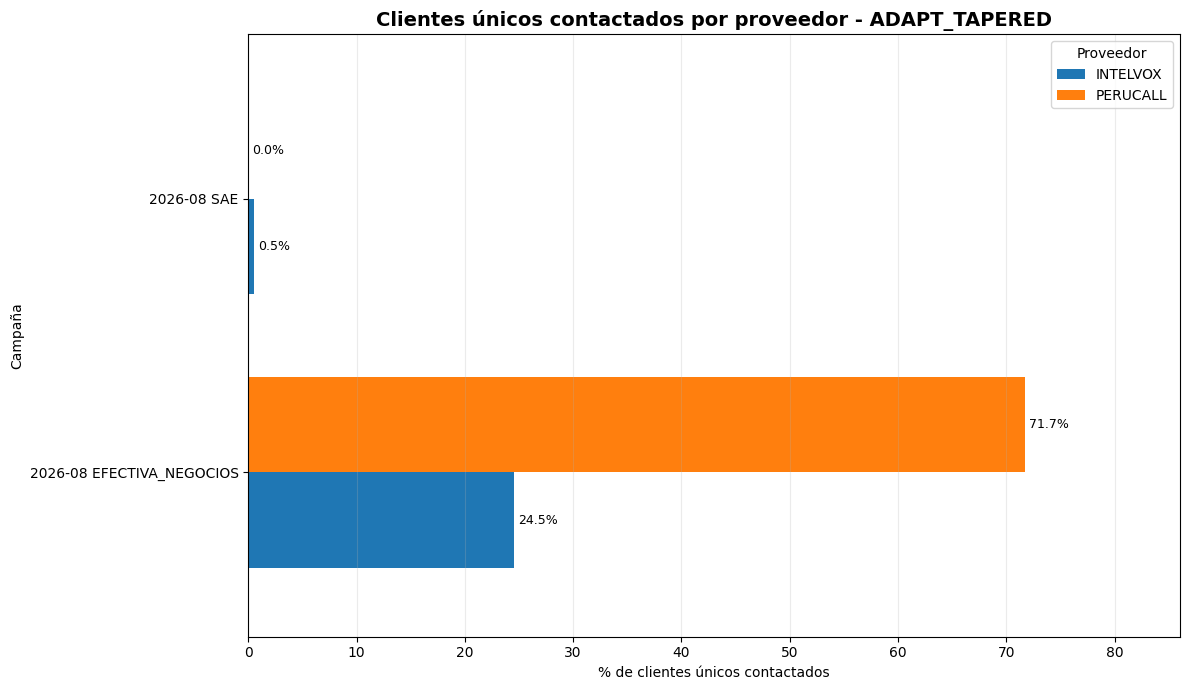

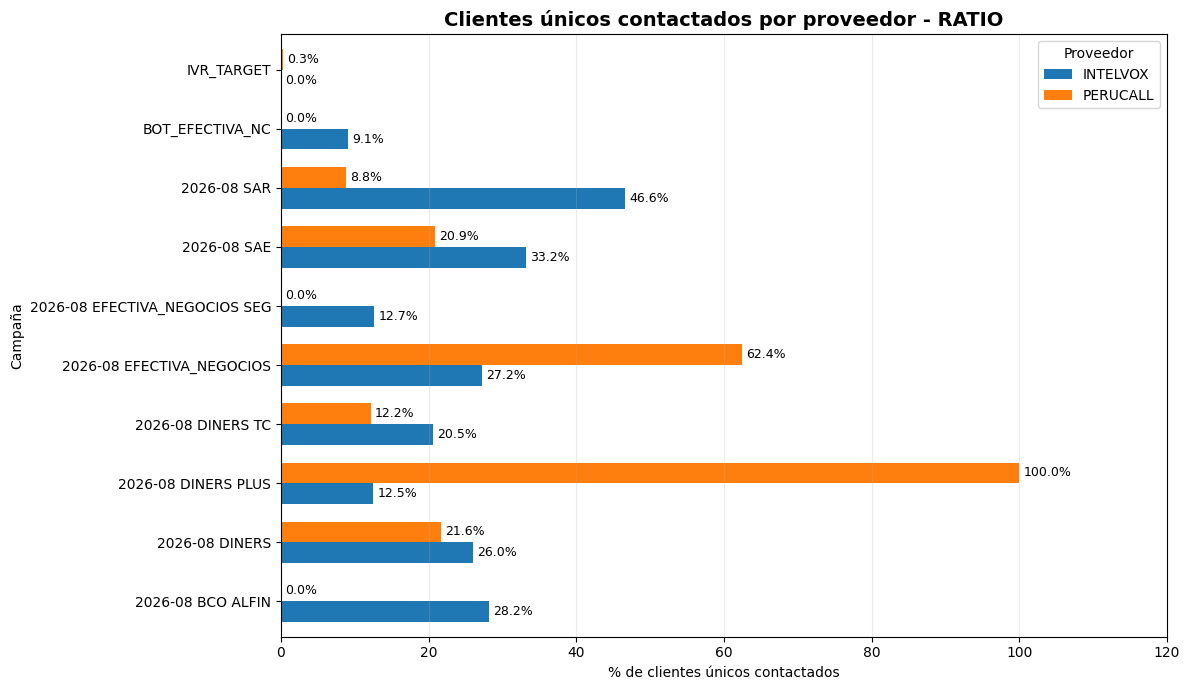

In [102]:
for metodo in orden_dial:

    df_plot = resultado_final[
        resultado_final["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    pivot = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="pct_clientes_contactados",
        aggfunc="mean"
    )

    proveedores = [
        p for p in ["INTELVOX", "PERUCALL"]
        if p in pivot.columns
    ]

    pivot = pivot[proveedores]

    ax = pivot.plot(
        kind="barh",
        figsize=(12, 7),
        width=0.7
    )

    for container in ax.containers:

        labels = [
            f"{v:.1f}%" if pd.notna(v) else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_title(
        f"Clientes únicos contactados por proveedor - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("% de clientes únicos contactados")
    ax.set_ylabel("Campaña")

    maximo = pivot.max().max()

    if pd.notna(maximo):
        ax.set_xlim(0, maximo * 1.20)

    ax.legend(title="Proveedor")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

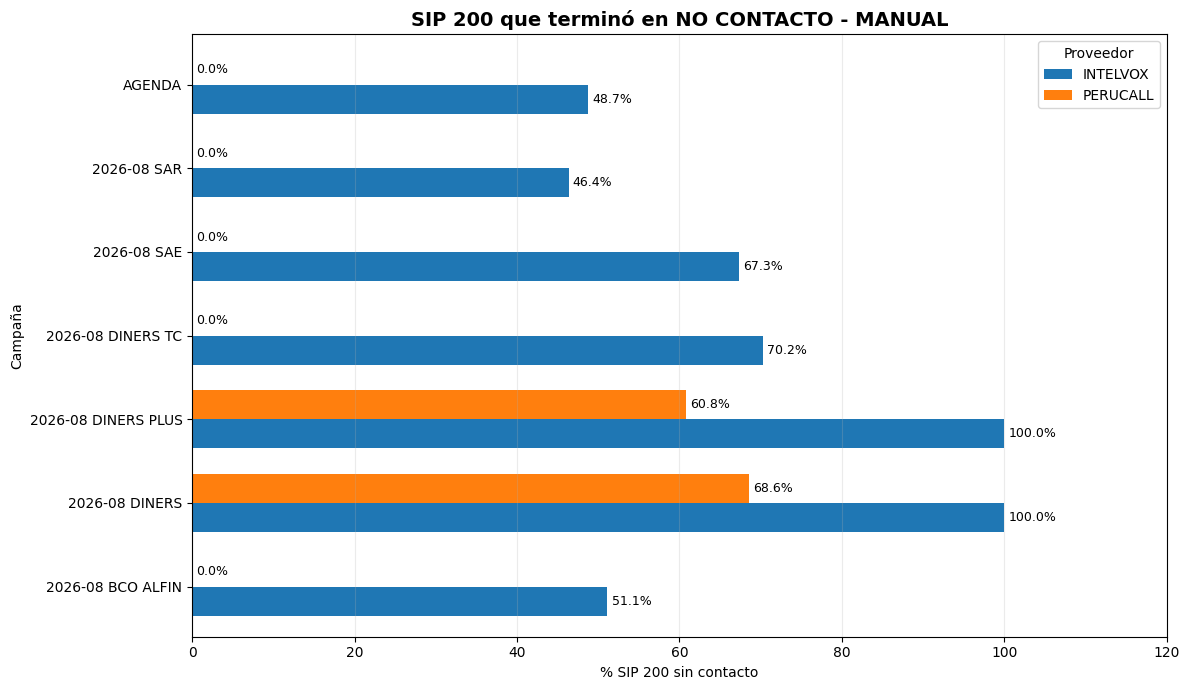

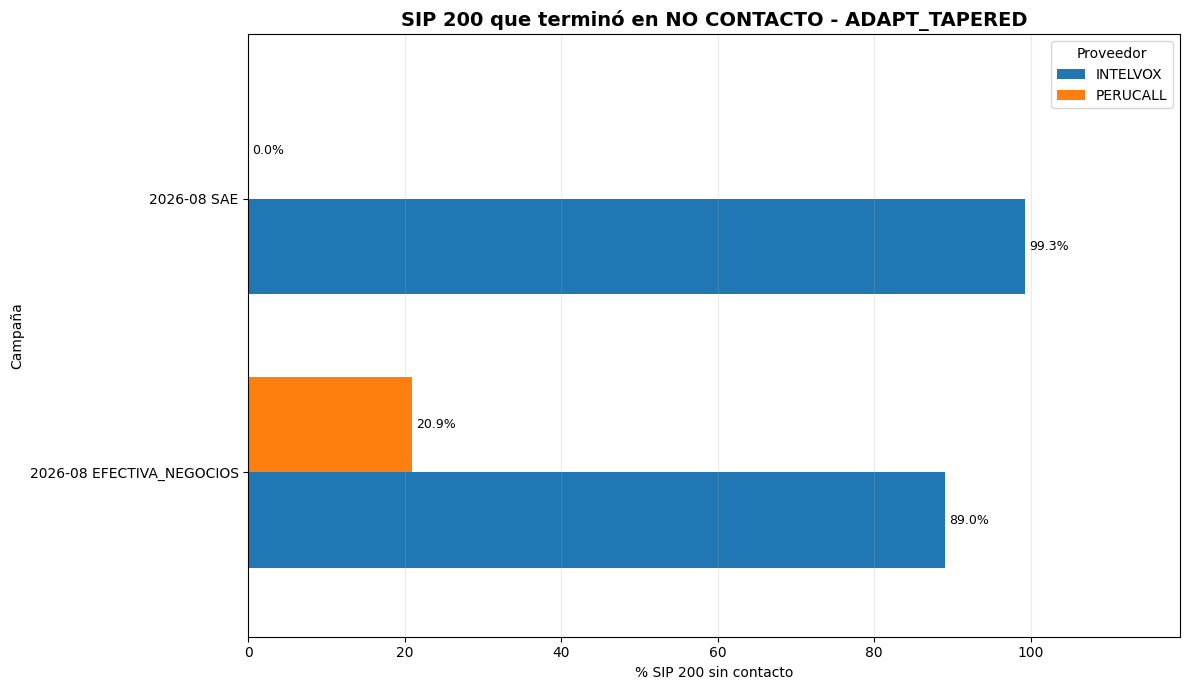

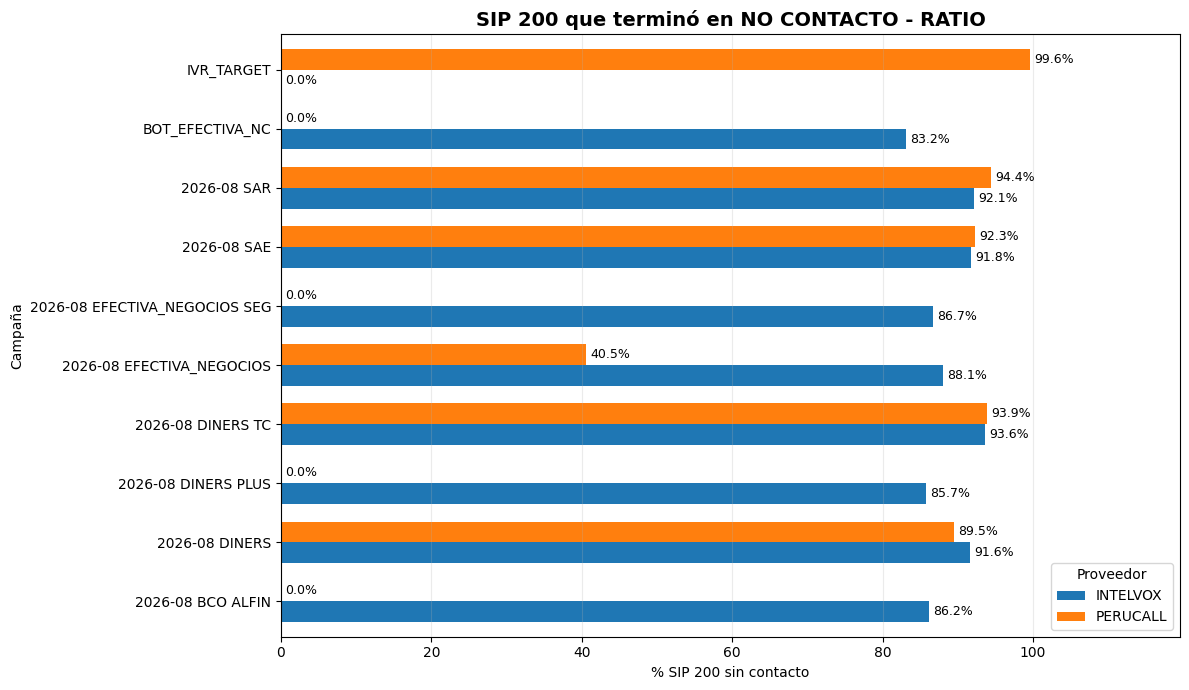

In [103]:
for metodo in orden_dial:

    df_plot = resultado_final[
        resultado_final["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    pivot = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="pct_sip200_no_contacto",
        aggfunc="mean"
    )

    proveedores = [
        p for p in ["INTELVOX", "PERUCALL"]
        if p in pivot.columns
    ]

    pivot = pivot[proveedores]

    ax = pivot.plot(
        kind="barh",
        figsize=(12, 7),
        width=0.7
    )

    for container in ax.containers:

        labels = [
            f"{v:.1f}%" if pd.notna(v) else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_title(
        f"SIP 200 que terminó en NO CONTACTO - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("% SIP 200 sin contacto")
    ax.set_ylabel("Campaña")

    maximo = pivot.max().max()

    if pd.notna(maximo):
        ax.set_xlim(0, maximo * 1.20)

    ax.legend(title="Proveedor")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

In [104]:
resumen_proveedor = (
    embudo_final
    .groupby(
        [
            "dial_method_historico",
            "proveedor"
        ],
        dropna=False
    )
    .agg(
        llamadas=("llamadas", "sum"),
        sip_200=("sip_200", "sum"),
        contactos=("contactos", "sum"),
        sip200_no_contacto=("sip200_no_contacto", "sum"),
        clientes_unicos=("clientes_unicos", "sum"),
        clientes_contactados=("clientes_contactados", "sum")
    )
    .reset_index()
)


# ============================================================
# INDICADORES
# ============================================================

resumen_proveedor["pct_sip_200"] = (
    resumen_proveedor["sip_200"]
    / resumen_proveedor["llamadas"]
    * 100
)

resumen_proveedor["pct_contacto"] = (
    resumen_proveedor["contactos"]
    / resumen_proveedor["llamadas"]
    * 100
)

resumen_proveedor["pct_contacto_sobre_sip200"] = (
    resumen_proveedor["contactos"]
    / resumen_proveedor["sip_200"]
    * 100
)

resumen_proveedor["pct_sip200_no_contacto"] = (
    resumen_proveedor["sip200_no_contacto"]
    / resumen_proveedor["sip_200"]
    * 100
)

resumen_proveedor["pct_clientes_contactados"] = (
    resumen_proveedor["clientes_contactados"]
    / resumen_proveedor["clientes_unicos"]
    * 100
)

resumen_proveedor.round(2)

,dial_method_historico,proveedor,llamadas,sip_200,contactos,sip200_no_contacto,clientes_unicos,clientes_contactados,pct_sip_200,pct_contacto,pct_contacto_sobre_sip200,pct_sip200_no_contacto,pct_clientes_contactados
0,ADAPT_TAPERED,INTELVOX,135146,76701,8468,68291,30979,7551.0,56.75,6.27,11.04,89.04,24.37
1,ADAPT_TAPERED,PERUCALL,234,134,162,28,159,114.0,57.26,69.23,120.90,20.90,71.70
2,MANUAL,INTELVOX,5563,3224,1615,1884,2828,963.0,57.95,29.03,50.09,58.44,34.05
3,MANUAL,PERUCALL,11139,6426,2572,4167,4390,1380.0,57.69,23.09,40.02,64.85,31.44
4,RATIO,INTELVOX,816719,654363,67614,588939,157922,40320.0,80.12,8.28,10.33,90.00,25.53
5,RATIO,PERUCALL,239230,202837,14342,188960,83364,10023.0,84.79,6.00,7.07,93.16,12.02


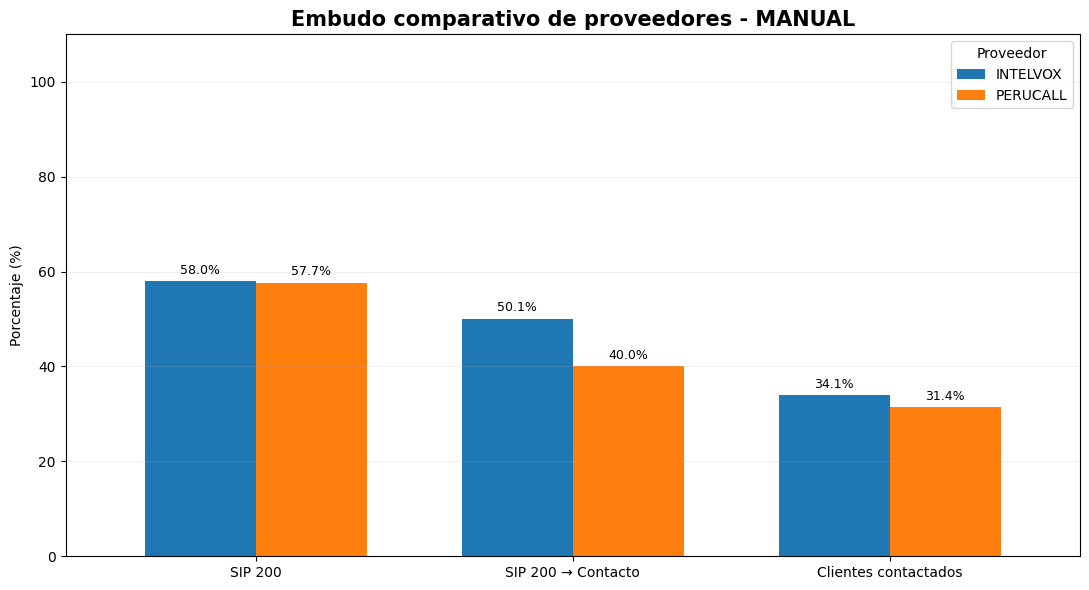

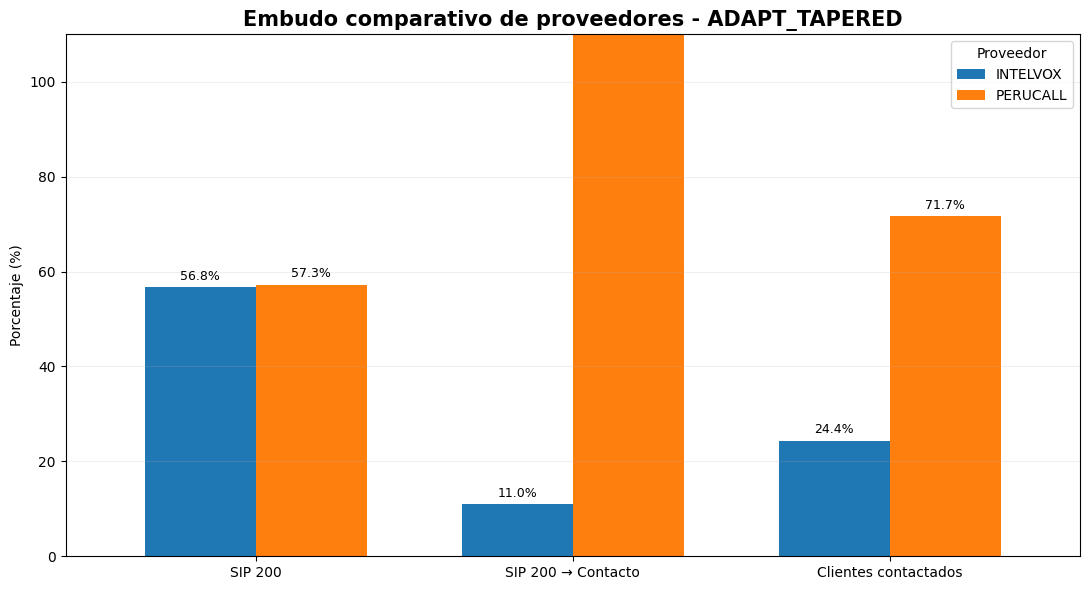

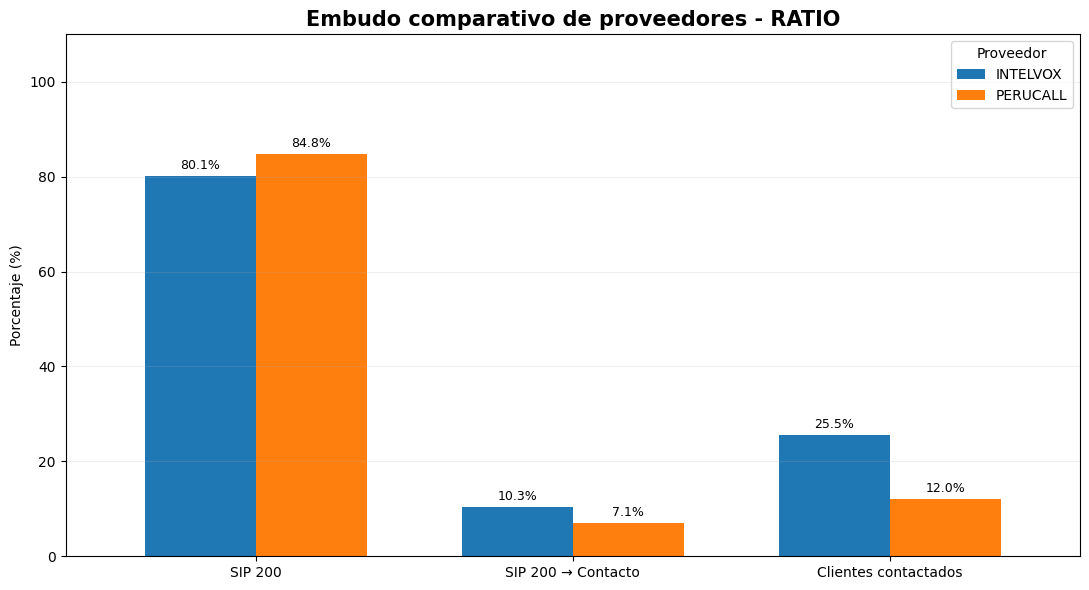

In [105]:
for metodo in orden_dial:

    df_plot = resumen_proveedor[
        resumen_proveedor["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    grafico = (
        df_plot
        .set_index("proveedor")
        [
            [
                "pct_sip_200",
                "pct_contacto_sobre_sip200",
                "pct_clientes_contactados"
            ]
        ]
        .rename(
            columns={
                "pct_sip_200": "SIP 200",
                "pct_contacto_sobre_sip200": "SIP 200 → Contacto",
                "pct_clientes_contactados": "Clientes contactados"
            }
        )
        .T
    )

    ax = grafico.plot(
        kind="bar",
        figsize=(11, 6),
        width=0.7
    )

    for container in ax.containers:

        labels = [
            f"{v:.1f}%"
            if pd.notna(v)
            else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_title(
        f"Embudo comparativo de proveedores - {metodo}",
        fontsize=15,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("Porcentaje (%)")

    ax.set_ylim(0, 110)

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=0
    )

    ax.legend(
        title="Proveedor"
    )

    ax.grid(
        axis="y",
        alpha=0.20
    )

    plt.tight_layout()
    plt.show()

In [58]:
df_total_mes_02["outbound_cid_original"] = (
    df_total_mes_02["outbound_cid"]
    .astype("string")
    .str.strip()
)


# ============================================================
# PARTE ENTRE COMILLAS
# Ejemplo:
# "M8010859280006884036"
# ============================================================

df_total_mes_02["caller_name"] = (
    df_total_mes_02["outbound_cid_original"]
    .str.extract(
        r'"([^"]+)"',
        expand=False
    )
)


# ============================================================
# PARTE ENTRE < >
# Ejemplo:
# <0000000000>
# ============================================================

df_total_mes_02["caller_number"] = (
    df_total_mes_02["outbound_cid_original"]
    .str.extract(
        r'<([^>]+)>',
        expand=False
    )
    .str.strip()
)

In [59]:
df_total_mes_02[
    [
        "proveedor",
        "outbound_cid_original",
        "caller_name",
        "caller_number",
        "tipo_contacto"
    ]
].head(20)

,proveedor,outbound_cid_original,caller_name,caller_number,tipo_contacto
0,INTELVOX,"""M8010859280006884036"" <0000000000>",M8010859280006884036,0000000000,NO CONTACTO
1,INTELVOX,"""M8010904400006884224"" <0000000000>",M8010904400006884224,0000000000,NO CONTACTO
2,INTELVOX,"""M8010910530006884216"" <0000000000>",M8010910530006884216,0000000000,NO CONTACTO
3,INTELVOX,"""M8010912020006884258"" <0000000000>",M8010912020006884258,0000000000,CONTACTO
4,INTELVOX,"""M8010913230006884197"" <0000000000>",M8010913230006884197,0000000000,NO CONTACTO
5,INTELVOX,"""M8010914170006884044"" <0000000000>",M8010914170006884044,0000000000,NO CONTACTO
6,INTELVOX,"""M8010914310006883996"" <0000000000>",M8010914310006883996,0000000000,CONTACTO
7,INTELVOX,"""M8010916100002199291"" <0000000000>",M8010916100002199291,0000000000,NO CONTACTO
8,INTELVOX,"""M8010915550006883980"" <0000000000>",M8010915550006883980,0000000000,CONTACTO
9,INTELVOX,"""M8010921000006884122"" <0000000000>",M8010921000006884122,0000000000,NO CONTACTO


In [60]:
# ============================================================
# VALIDAR CAMPOS RELACIONADOS CON LA SALIDA DE LA LLAMADA
# ============================================================

validar_caller = df_total_mes_02[
    [
        "fecha_hora_llamada",
        "proveedor",
        "nombre_campana",
        "extension",
        "channel",
        "context",
        "caller_code",
        "outbound_cid",
        "phone_number"
    ]
].copy()

validar_caller.head(50)

,fecha_hora_llamada,proveedor,nombre_campana,extension,channel,context,caller_code,outbound_cid,phone_number
0,2026-08-01 09:00:01,INTELVOX,AGENDA,899959194586,Local/8600056@default,default,M8010859280006884036,"""M8010859280006884036"" <0000000000>",959194586
1,2026-08-01 09:04:44,INTELVOX,AGENDA,899998494144,Local/8600056@default,default,M8010904400006884224,"""M8010904400006884224"" <0000000000>",998494144
2,2026-08-01 09:11:51,INTELVOX,AGENDA,899994829679,Local/8600056@default,default,M8010910530006884216,"""M8010910530006884216"" <0000000000>",994829679
3,2026-08-01 09:12:14,INTELVOX,AGENDA,899993647035,Local/8600056@default,default,M8010912020006884258,"""M8010912020006884258"" <0000000000>",993647035
4,2026-08-01 09:13:25,INTELVOX,AGENDA,899902544694,Local/8600056@default,default,M8010913230006884197,"""M8010913230006884197"" <0000000000>",902544694
5,2026-08-01 09:14:23,INTELVOX,AGENDA,899943553982,Local/8600056@default,default,M8010914170006884044,"""M8010914170006884044"" <0000000000>",943553982
6,2026-08-01 09:14:49,INTELVOX,AGENDA,899963075660,Local/8600056@default,default,M8010914310006883996,"""M8010914310006883996"" <0000000000>",963075660
7,2026-08-01 09:16:12,INTELVOX,AGENDA,899999369786,Local/8600053@default,default,M8010916100002199291,"""M8010916100002199291"" <0000000000>",999369786
8,2026-08-01 09:16:16,INTELVOX,AGENDA,899994614690,Local/8600056@default,default,M8010915550006883980,"""M8010915550006883980"" <0000000000>",994614690
9,2026-08-01 09:21:34,INTELVOX,AGENDA,899952264714,Local/8600056@default,default,M8010921000006884122,"""M8010921000006884122"" <0000000000>",952264714


In [64]:
query_caller = """
SELECT *
FROM OPENQUERY([192.168.3.21], '
    SELECT
        TABLE_NAME,
        COLUMN_NAME,
        DATA_TYPE

    FROM INFORMATION_SCHEMA.COLUMNS

    WHERE TABLE_SCHEMA = ''asterisk''

    AND (
           COLUMN_NAME LIKE ''%cid%''
        OR COLUMN_NAME LIKE ''%caller%''
        OR COLUMN_NAME LIKE ''%outbound%''
    )

    ORDER BY
        TABLE_NAME,
        ORDINAL_POSITION
')
"""

df_caller = pd.read_sql(
    query_caller,
    engine_zeus
)

df_caller

,TABLE_NAME,COLUMN_NAME,DATA_TYPE
0,call_log,caller_code,varchar
1,call_log_archive,caller_code,varchar
2,cid_channels_recent,caller_id_name,varchar
3,cid_channels_recent_192168003021,caller_id_name,varchar
4,gateway_recording_log,caller_id_number,varchar
...,...,...,...
203,vicidial_users2,vicidial_transfers,enum
204,vicidial_users2,vicidial_recording_override,enum
205,vicidial_user_dial_log,caller_code,varchar
206,vicidial_user_dial_log_archive,caller_code,varchar


In [66]:
# ============================================================
# BUSCAR COLUMNAS REALMENTE RELACIONADAS CON CALLER ID
# ============================================================

filtro = (
    df_caller["COLUMN_NAME"]
    .str.lower()
    .str.contains(
        r"caller_id|campaign_cid|custom_cid|outbound_cid|cid_number|cid_num",
        regex=True,
        na=False
    )
)

df_cid = (
    df_caller[filtro]
    .sort_values(
        ["TABLE_NAME", "COLUMN_NAME"]
    )
    .reset_index(drop=True)
)

pd.set_option("display.max_rows", 200)

df_cid

,TABLE_NAME,COLUMN_NAME,DATA_TYPE
0,cid_channels_recent,caller_id_name,varchar
1,cid_channels_recent_192168003021,caller_id_name,varchar
2,gateway_recording_log,caller_id_name,varchar
3,gateway_recording_log,caller_id_number,varchar
4,groups_alias,caller_id_name,varchar
5,groups_alias,caller_id_number,varchar
6,live_inbound,caller_id,varchar
7,live_inbound_log,caller_id,varchar
8,phones,outbound_cid,varchar
9,phones2,outbound_cid,varchar


In [79]:
query_caller = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT
        COLUMN_NAME,
        DATA_TYPE

    FROM INFORMATION_SCHEMA.COLUMNS

    WHERE TABLE_SCHEMA = ''asterisk''
      AND TABLE_NAME = ''vicidial_dial_cid_log''

    ORDER BY ORDINAL_POSITION
')
"""

df_dial_cid_cols = pd.read_sql(
    query_caller,
    engine_zeus
)

df_dial_cid_cols

,COLUMN_NAME,DATA_TYPE
0,caller_code,varchar
1,call_date,datetime
2,call_type,enum
3,call_alt,varchar
4,outbound_cid,varchar
5,outbound_cid_type,varchar


In [80]:
query_caller = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT *

    FROM asterisk.vicidial_dial_cid_log

    ORDER BY call_date DESC

    LIMIT 100
')
"""

df_dial_cid = pd.read_sql(
    query_caller,
    engine_zeus
)

df_dial_cid

,caller_code,call_date,call_type,call_alt,outbound_cid,outbound_cid_type
0,V8171423440010913935,2026-08-17 14:23:44,OUT,NONE,0000000000,CAMPAIGN_CID
1,V8171423440010913933,2026-08-17 14:23:44,OUT,NONE,0000000000,CAMPAIGN_CID
2,V8171423440010913928,2026-08-17 14:23:44,OUT,NONE,0000000000,CAMPAIGN_CID
3,V8171423440010913926,2026-08-17 14:23:44,OUT,NONE,0000000000,CAMPAIGN_CID
4,V8171423390010913924,2026-08-17 14:23:39,OUT,NONE,0000000000,CAMPAIGN_CID
5,V8171423390010913921,2026-08-17 14:23:39,OUT,NONE,0000000000,CAMPAIGN_CID
6,V8171423340010913917,2026-08-17 14:23:34,OUT,NONE,0000000000,CAMPAIGN_CID
7,V8171423340010913915,2026-08-17 14:23:34,OUT,NONE,0000000000,CAMPAIGN_CID
8,V8171423340010913914,2026-08-17 14:23:34,OUT,NONE,0000000000,CAMPAIGN_CID
9,V8171423240010913911,2026-08-17 14:23:24,OUT,NONE,0000000000,CAMPAIGN_CID


In [86]:
query_trunk = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT
        COLUMN_NAME,
        DATA_TYPE

    FROM INFORMATION_SCHEMA.COLUMNS

    WHERE TABLE_SCHEMA = ''asterisk''
      AND TABLE_NAME = ''vicidial_server_trunks''

    ORDER BY ORDINAL_POSITION
')
"""

df_trunk_cols = pd.read_sql(
    query_trunk,
    engine_zeus
)

pd.set_option("display.max_rows", 200)

df_trunk_cols

,COLUMN_NAME,DATA_TYPE
0,server_ip,varchar
1,campaign_id,varchar
2,dedicated_trunks,smallint
3,trunk_restriction,enum


In [87]:
query_trunk = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT *
    FROM asterisk.vicidial_server_trunks

')
"""

df_trunks = pd.read_sql(
    query_trunk,
    engine_zeus
)

df_trunks

,server_ip,campaign_id,dedicated_trunks,trunk_restriction


In [88]:
query_carrier = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT
        COLUMN_NAME,
        DATA_TYPE

    FROM INFORMATION_SCHEMA.COLUMNS

    WHERE TABLE_SCHEMA = ''asterisk''
      AND TABLE_NAME = ''vicidial_server_carriers''

    ORDER BY ORDINAL_POSITION
')
"""

df_carrier_cols = pd.read_sql(
    query_carrier,
    engine_zeus
)

pd.set_option("display.max_rows", 200)

df_carrier_cols

,COLUMN_NAME,DATA_TYPE
0,carrier_id,varchar
1,carrier_name,varchar
2,registration_string,varchar
3,template_id,varchar
4,account_entry,text
5,protocol,enum
6,globals_string,varchar
7,dialplan_entry,text
8,server_ip,varchar
9,active,enum


In [89]:
query_carrier = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT *
    FROM asterisk.vicidial_server_carriers

')
"""

df_server_carriers = pd.read_sql(
    query_carrier,
    engine_zeus
)

df_server_carriers

,carrier_id,carrier_name,registration_string,template_id,account_entry,protocol,globals_string,dialplan_entry,server_ip,active,carrier_description,user_group
0,ITELVOX,ITELVOX,register => target:t4rg3TH6mYu8@45.92.18.56/target,--NONE--,[ITELVOX]\nhost=45.92.18.56\nusername=target\nsecret=t4rg3TH6mYu8\nfromuser=target\ntype=peer\ncanreinvite=no\ndisallow=all\nallow=g729\ndtmfmode=rfc2833\nqualify=yes\nnat=yes,SIP,SIPTRUNK3=SIP/ITELVOX,"exten => _559XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _559XXXXXXXX,n,Dial(${SIPTRUNK3}/2278151${EXTEN:2},,Tto)\nexten => _559XXXXXXXX,n,Hangup\n\nexten => _8990XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _8990XXXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:4},,Tto)\nexten => _8990XXXXXXXX,n,Hangup\n\nexten => _8999XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _8999XXXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:3},,Tto)\nexten => _8999XXXXXXXX,n,Hangup\n\nexten => _899XXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _899XXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:3},,Tto)\nexten => _899XXXXXXX,n,Hangup\n\nexten => _4990XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _4990XXXXXXXX,n,Set(MES=${STRFTIME(${EPOCH},,%Y%m)})\nexten => _4990XXXXXXXX,n,Set(DIA=${STRFTIME(${EPOCH},,%d)})\nexten => _4990XXXXXXXX,n,System(sh /usr/local/sbin/checkDayDir.sh ${MES} ${DIA})\nexten => _4990XXXXXXXX,n,MixMonitor(/var/spool/asterisk/monitor2/${MES}/${DIA}/${STRFTIME(${EPOCH},,%Y%m%d-%H%M%S)}_${EXTEN}_${CAMPCUST}.gsm)\nexten => _4990XXXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:4},,Tto)\nexten => _4990XXXXXXXX,n,Hangup\n\nexten => _4999XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _4999XXXXXXXX,n,Set(MES=${STRFTIME(${EPOCH},,%Y%m)})\nexten => _4999XXXXXXXX,n,Set(DIA=${STRFTIME(${EPOCH},,%d)})\nexten => _4999XXXXXXXX,n,System(sh /usr/local/sbin/checkDayDir.sh ${MES} ${DIA})\nexten => _4999XXXXXXXX,n,MixMonitor(/var/spool/asterisk/monitor2/${MES}/${DIA}/${STRFTIME(${EPOCH},,%Y%m%d-%H%M%S)}_${EXTEN}_${CAMPCUST}.gsm)\nexten => _4999XXXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:3},,Tto)\nexten => _4999XXXXXXXX,n,Hangup\n\nexten => _499XXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _499XXXXXXX,n,Set(MES=${STRFTIME(${EPOCH},,%Y%m)})\nexten => _499XXXXXXX,n,Set(DIA=${STRFTIME(${EPOCH},,%d)})\nexten => _499XXXXXXX,n,System(sh /usr/local/sbin/checkDayDir.sh ${MES} ${DIA})\nexten => _499XXXXXXX,n,MixMonitor(/var/spool/asterisk/monitor2/${MES}/${DIA}/${STRFTIME(${EPOCH},,%Y%m%d-%H%M%S)}_${EXTEN}_${CAMPCUST}.gsm)\nexten => _499XXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:3},,Tto)\nexten => _499XXXXXXX,n,Hangup\n\n\nexten => _999XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _999XXXXXXXX,n,Set(MES=${STRFTIME(${EPOCH},,%Y%m)})\nexten => _999XXXXXXXX,n,Set(DIA=${STRFTIME(${EPOCH},,%d)})\nexten => _999XXXXXXXX,n,System(sh /usr/local/sbin/checkDayDir.sh ${MES} ${DIA})\nexten => _999XXXXXXXX,n,MixMonitor(/var/spool/asterisk/monitor2/${MES}/${DIA}/${STRFTIME(${EPOCH},,%Y%m%d-%H%M%S)}_${EXTEN}_${CAMPCUST}.gsm)\nexten => _999XXXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:2},,Tto)\nexten => _999XXXXXXXX,n,Hangup",192.168.3.21,Y,,---ALL---
1,PERUCALL,PERUCALL,register =>pcalls01:p4c4llR6teMht@74.50.127.235/pcalls01,--NONE--,[PERUCALL]\nhost=74.50.127.235\nusername=pcalls01\nsecret=p4c4llR6teMht\nfromuser=pcalls01\ntype=peer\ncanreinvite=no\ndisallow=all\nallow=g729\ndtmfmode=rfc2833\nqualify=yes\n,SIP,SIPTRUNK1=SIP/PERUCALL,"exten => _8880[4-8]XXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _8880[4-8]XXXXXXX,n,Set(CALLERID(num)=${FILE(/etc/asterisk/ruleteo.txt,${RAND(0,99)},1,l)})\nexten => _8880[4-8]XXXXXXX,n,Dial(${SIPTRUNK1}/1785351${EXTEN:3},,Tto)\nexten => _8880[4-8]XXXXXXX,n,Hangup\n\nexten => _888[2-7]XXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _888[2-7]XXXXXX,n,Set(CALLERID(num)=${FILE(/etc/asterisk/ruleteo.txt,${RAND(0,99)},1,l)})\nexten => _888[2-7]XXXXXX,n,Dial(${SIPTRUNK1}/17853511${EXTEN:3},,Tto)\nexten => _888[2-7]XXXXXX,n,Hangup\n\nexten => _8889XXXXXXXX,1,AGI(agi://127.0.0.1:4577/ca

In [85]:
pd.crosstab(
    df_validacion_metodo["dial_method_historico"],
    df_validacion_metodo["call_type"],
    margins=True
)

call_type
dial_method_historico


In [56]:
import pandas as pd
import numpy as np

# ============================================================
# 1. COPIA
# ============================================================

df_spam = df_total_mes_02.copy()


# ============================================================
# 2. NORMALIZAR CAMPOS
# ============================================================

columnas_texto = [
    "proveedor",
    "nombre_campana",
    "dial_method_historico",
    "tipo_contacto",
    "outbound_cid_limpio"
]

for col in columnas_texto:
    df_spam[col] = (
        df_spam[col]
        .astype("string")
        .str.strip()
    )

df_spam["proveedor"] = df_spam["proveedor"].str.upper()
df_spam["dial_method_historico"] = (
    df_spam["dial_method_historico"].str.upper()
)
df_spam["tipo_contacto"] = (
    df_spam["tipo_contacto"].str.upper()
)


# ============================================================
# 3. INDICADOR DE CONTACTO
# ============================================================

df_spam["es_contacto"] = np.where(
    df_spam["tipo_contacto"] == "CONTACTO",
    1,
    0
)


# ============================================================
# 4. RESUMEN POR CALLER ID
# ============================================================

resumen_caller_id = (
    df_spam
    .dropna(
        subset=[
            "outbound_cid_limpio"
        ]
    )
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "outbound_cid_limpio"
        ],
        dropna=False
    )
    .agg(
        llamadas=(
            "lead_id",
            "count"
        ),

        clientes=(
            "vendor_lead_code",
            "nunique"
        ),

        contactos=(
            "es_contacto",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 5. % CONTACTO
# ============================================================

resumen_caller_id["pct_contacto"] = (
    resumen_caller_id["contactos"]
    / resumen_caller_id["llamadas"]
    * 100
)


# ============================================================
# 6. QUEDARNOS SOLO CON CALLER ID CON VOLUMEN SUFICIENTE
# Evitamos concluir por números con 2 o 3 llamadas.
# ============================================================

resumen_caller_id = resumen_caller_id[
    resumen_caller_id["llamadas"] >= 100
].copy()


# ============================================================
# 7. PROMEDIO DE CONTACTO DE SU MISMO GRUPO
#
# Compara el caller id contra:
# misma campaña + mismo método + mismo proveedor
# ============================================================

resumen_caller_id["pct_contacto_promedio_grupo"] = (
    resumen_caller_id
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ]
    )["pct_contacto"]
    .transform("mean")
)


# ============================================================
# 8. DIFERENCIA CONTRA PROMEDIO
# ============================================================

resumen_caller_id["dif_contacto_pp"] = (
    resumen_caller_id["pct_contacto"]
    - resumen_caller_id["pct_contacto_promedio_grupo"]
)


# ============================================================
# 9. CLASIFICACIÓN OPERATIVA
#
# OJO:
# esto NO significa spam confirmado.
# Es una señal de bajo desempeño.
# ============================================================

resumen_caller_id["estado_caller_id"] = np.select(
    [
        resumen_caller_id["dif_contacto_pp"] <= -5,
        resumen_caller_id["dif_contacto_pp"].between(-5, -2),
        resumen_caller_id["dif_contacto_pp"] > -2
    ],
    [
        "ALERTA ALTA",
        "REVISAR",
        "NORMAL"
    ],
    default="SIN CLASIFICAR"
)


# ============================================================
# 10. ORDENAR LOS MÁS CRÍTICOS
# ============================================================

resumen_caller_id = resumen_caller_id.sort_values(
    [
        "estado_caller_id",
        "dif_contacto_pp"
    ],
    ascending=[
        True,
        True
    ]
)

resumen_caller_id

,nombre_campana,dial_method_historico,proveedor,outbound_cid_limpio,llamadas,clientes,contactos,pct_contacto,pct_contacto_promedio_grupo,dif_contacto_pp,estado_caller_id


In [47]:
# # ============================================================
# # TABLA DE INTENTOS PARA TODAS LAS CAMPAÑAS
# # ============================================================

# tabla_intentos = (
#     distribucion_intentos
#     .pivot_table(
#         index=[
#             "nombre_campana",
#             "dial_method",
#             "proveedor"
#         ],
#         columns="rango_intento",
#         values="porcentaje",
#         aggfunc="sum",
#         fill_value=0
#     )
# )

# # ============================================================
# # ORDEN DE LAS COLUMNAS
# # ============================================================

# orden = [
#     "1 intento",
#     "2 intentos",
#     "3 intentos",
#     "4 intentos",
#     "5+ intentos"
# ]

# tabla_intentos = tabla_intentos.reindex(
#     columns=orden,
#     fill_value=0
# )

# # ============================================================
# # TOTAL PARA VALIDAR QUE SUME 100%
# # ============================================================

# tabla_intentos["TOTAL"] = (
#     tabla_intentos.sum(axis=1)
# )

# # ============================================================
# # MOSTRAR
# # ============================================================

# display(
#     tabla_intentos.round(2)
# )

### DEAD_SEC

In [65]:
df_dead = df_total_agosto_02.copy()

df_dead["tiene_dead"] = (
    df_dead["dead_sec"]
    .fillna(0)
    .gt(0)
)

In [66]:
# ============================================================
# TABLA RESUMEN DEAD
# ============================================================

resumen_dead = (
    df_dead
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        dropna=False
    )
    .agg(
        llamadas=("lead_id", "size"),

        llamadas_con_dead=(
            "tiene_dead",
            "sum"
        ),

        dead_promedio=(
            "dead_sec",
            "mean"
        ),

        dead_mediana=(
            "dead_sec",
            "median"
        ),

        dead_maximo=(
            "dead_sec",
            "max"
        )
    )
    .reset_index()
)

# ============================================================
# PORCENTAJE DE LLAMADAS CON DEAD
# ============================================================

resumen_dead["porcentaje_con_dead"] = (
    resumen_dead["llamadas_con_dead"]
    / resumen_dead["llamadas"]
    * 100
)

columnas = [
    "dead_promedio",
    "dead_mediana",
    "dead_maximo",
    "porcentaje_con_dead"
]

resumen_dead[columnas] = (
    resumen_dead[columnas]
    .round(2)
)

display(
    resumen_dead.sort_values(
        [
            "dial_method",
            "nombre_campana",
            "proveedor"
        ]
    )
)

,nombre_campana,dial_method,proveedor,llamadas,llamadas_con_dead,dead_promedio,dead_mediana,dead_maximo,porcentaje_con_dead
1,2026-08 DINERS,MANUAL,INTELVOX,51413,3248,7.29,0.0,456.0,6.32
2,2026-08 DINERS,MANUAL,PERUCALL,38030,3275,7.97,0.0,1006.0,8.61
3,2026-08 DINERS PLUS,MANUAL,INTELVOX,20,2,1.00,1.0,1.0,10.00
4,2026-08 DINERS PLUS,MANUAL,PERUCALL,5065,638,3.70,0.0,279.0,12.60
5,2026-08 DINERS TC,MANUAL,INTELVOX,90240,6981,4.98,1.0,216.0,7.74
6,2026-08 DINERS TC,MANUAL,PERUCALL,97609,7861,5.35,1.0,164.0,8.05
14,AGENDA,MANUAL,INTELVOX,2260,282,4.59,0.0,1750.0,12.48
0,2026-08 BCO ALFIN,RATIO,INTELVOX,64684,2520,4.05,0.0,761.0,3.90
7,2026-08 EFECTIVA_NEGOCIOS,RATIO,INTELVOX,428448,21831,3.08,0.0,364.0,5.10
8,2026-08 EFECTIVA_NEGOCIOS,RATIO,PERUCALL,577,52,1.55,0.0,86.0,9.01


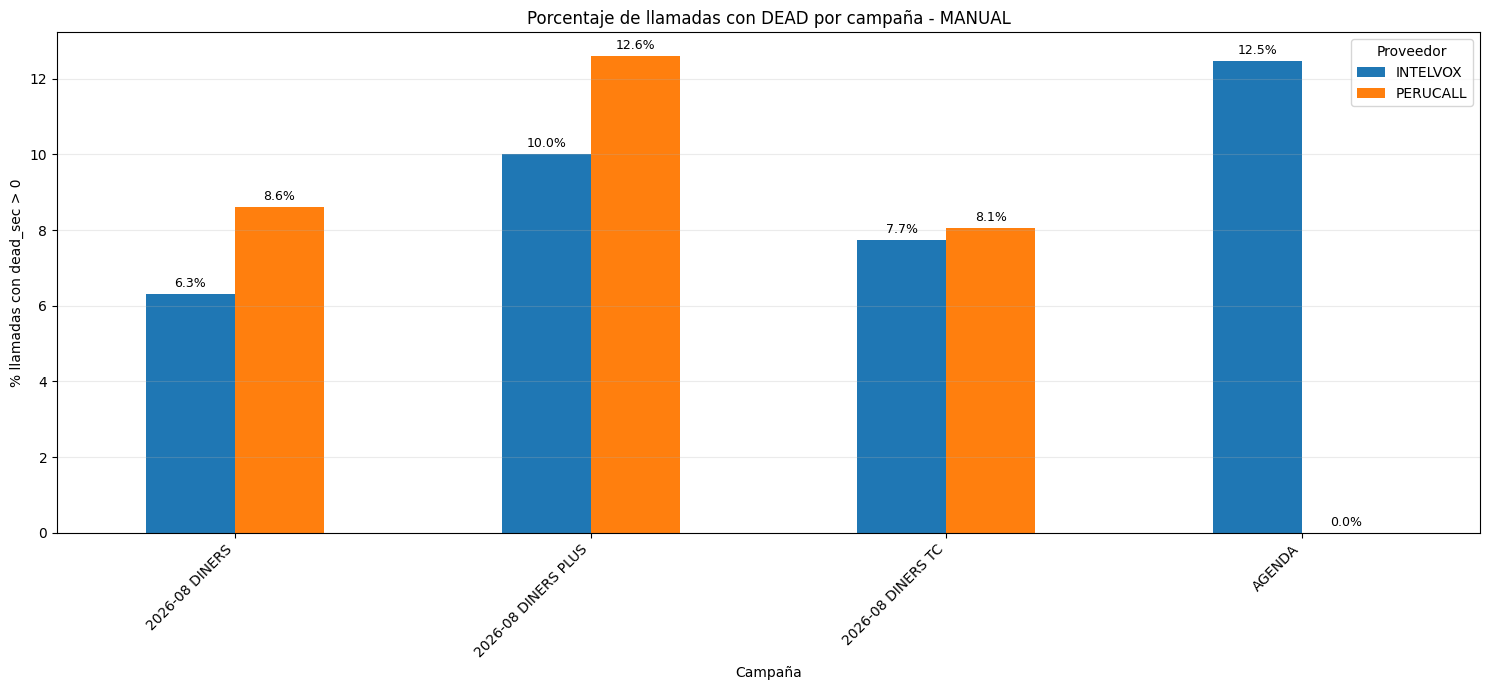

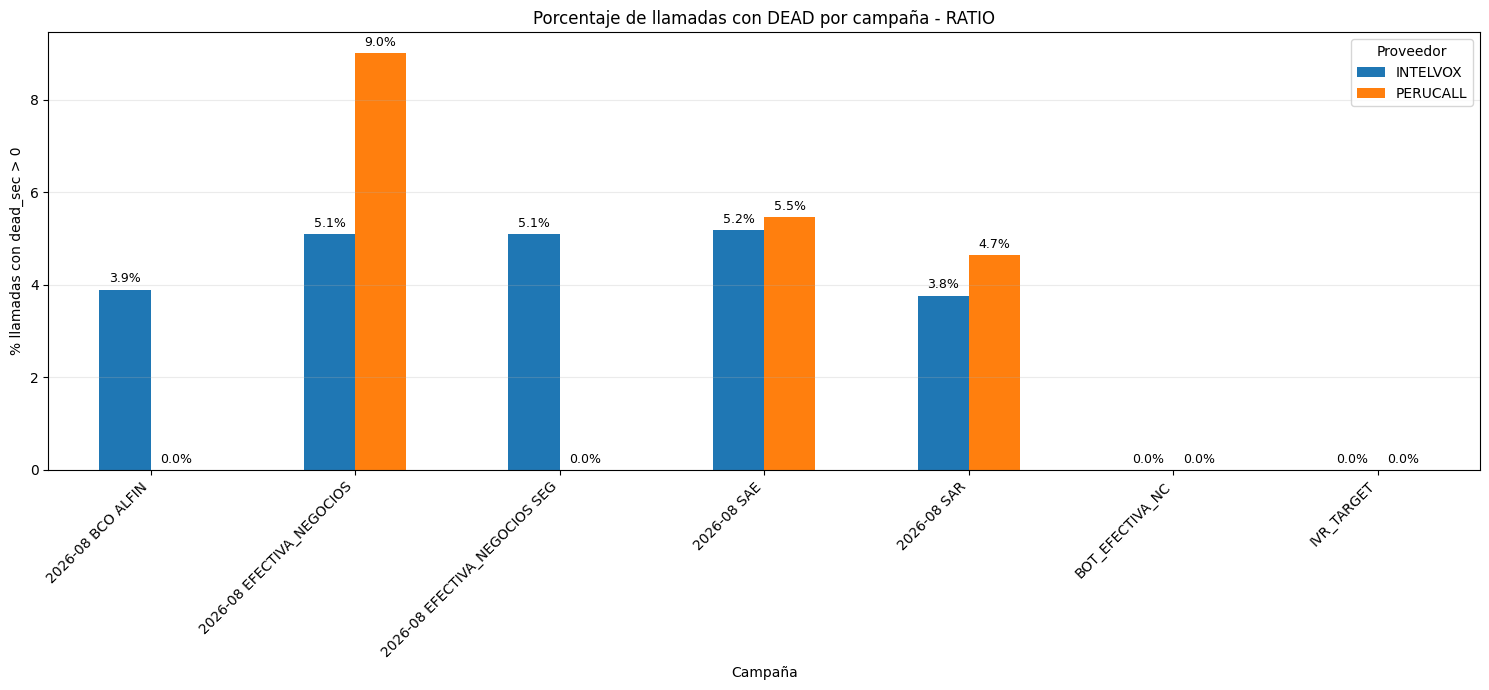

In [67]:
# ============================================================
# GRÁFICO % LLAMADAS CON DEAD
# ============================================================

for metodo in sorted(
    resumen_dead["dial_method"]
    .dropna()
    .unique()
):

    df_grafico = resumen_dead[
        resumen_dead["dial_method"] == metodo
    ].copy()

    pivot = (
        df_grafico
        .pivot(
            index="nombre_campana",
            columns="proveedor",
            values="porcentaje_con_dead"
        )
        .fillna(0)
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(15, 7)
    )

    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=9
        )

    plt.title(
        f"Porcentaje de llamadas con DEAD por campaña - {metodo}"
    )

    plt.xlabel("Campaña")
    plt.ylabel("% llamadas con dead_sec > 0")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.legend(
        title="Proveedor"
    )

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

## Embudo

In [68]:
# ============================================================
# EMBUDO DE EFICIENCIA POR PROVEEDOR
# ============================================================

resumen_embudo = (
    df_intentos
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ]
    )
    .agg(
        clientes_gestionados=(
            "vendor_lead_code",
            "nunique"
        )
    )
    .reset_index()
)

# ============================================================
# CLIENTES CONTACTADOS
# ============================================================

contactados = (
    primer_contacto
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ]
    )
    .agg(
        clientes_contactados=(
            "vendor_lead_code",
            "nunique"
        )
    )
    .reset_index()
)

# ============================================================
# CONTACTADOS EN MÁXIMO 2 INTENTOS
# ============================================================

contactados_2_intentos = (
    primer_contacto[
        primer_contacto["nro_intento"] <= 2
    ]
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ]
    )
    .agg(
        contacto_hasta_2_intentos=(
            "vendor_lead_code",
            "nunique"
        )
    )
    .reset_index()
)

# ============================================================
# CONTACTADOS EN PRIMER INTENTO
# ============================================================

contactados_1_intento = (
    primer_contacto[
        primer_contacto["nro_intento"] == 1
    ]
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ]
    )
    .agg(
        contacto_1_intento=(
            "vendor_lead_code",
            "nunique"
        )
    )
    .reset_index()
)

# ============================================================
# UNIR
# ============================================================

embudo = (
    resumen_embudo
    .merge(
        contactados,
        on=[
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        how="left"
    )
    .merge(
        contactados_2_intentos,
        on=[
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        how="left"
    )
    .merge(
        contactados_1_intento,
        on=[
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        how="left"
    )
)

# Nulos a cero
columnas_embudo = [
    "clientes_contactados",
    "contacto_hasta_2_intentos",
    "contacto_1_intento"
]

embudo[columnas_embudo] = (
    embudo[columnas_embudo]
    .fillna(0)
    .astype(int)
)

In [69]:
embudo["pct_contactados"] = (
    embudo["clientes_contactados"]
    / embudo["clientes_gestionados"]
    * 100
)

embudo["pct_hasta_2_intentos"] = (
    embudo["contacto_hasta_2_intentos"]
    / embudo["clientes_gestionados"]
    * 100
)

embudo["pct_1_intento"] = (
    embudo["contacto_1_intento"]
    / embudo["clientes_gestionados"]
    * 100
)

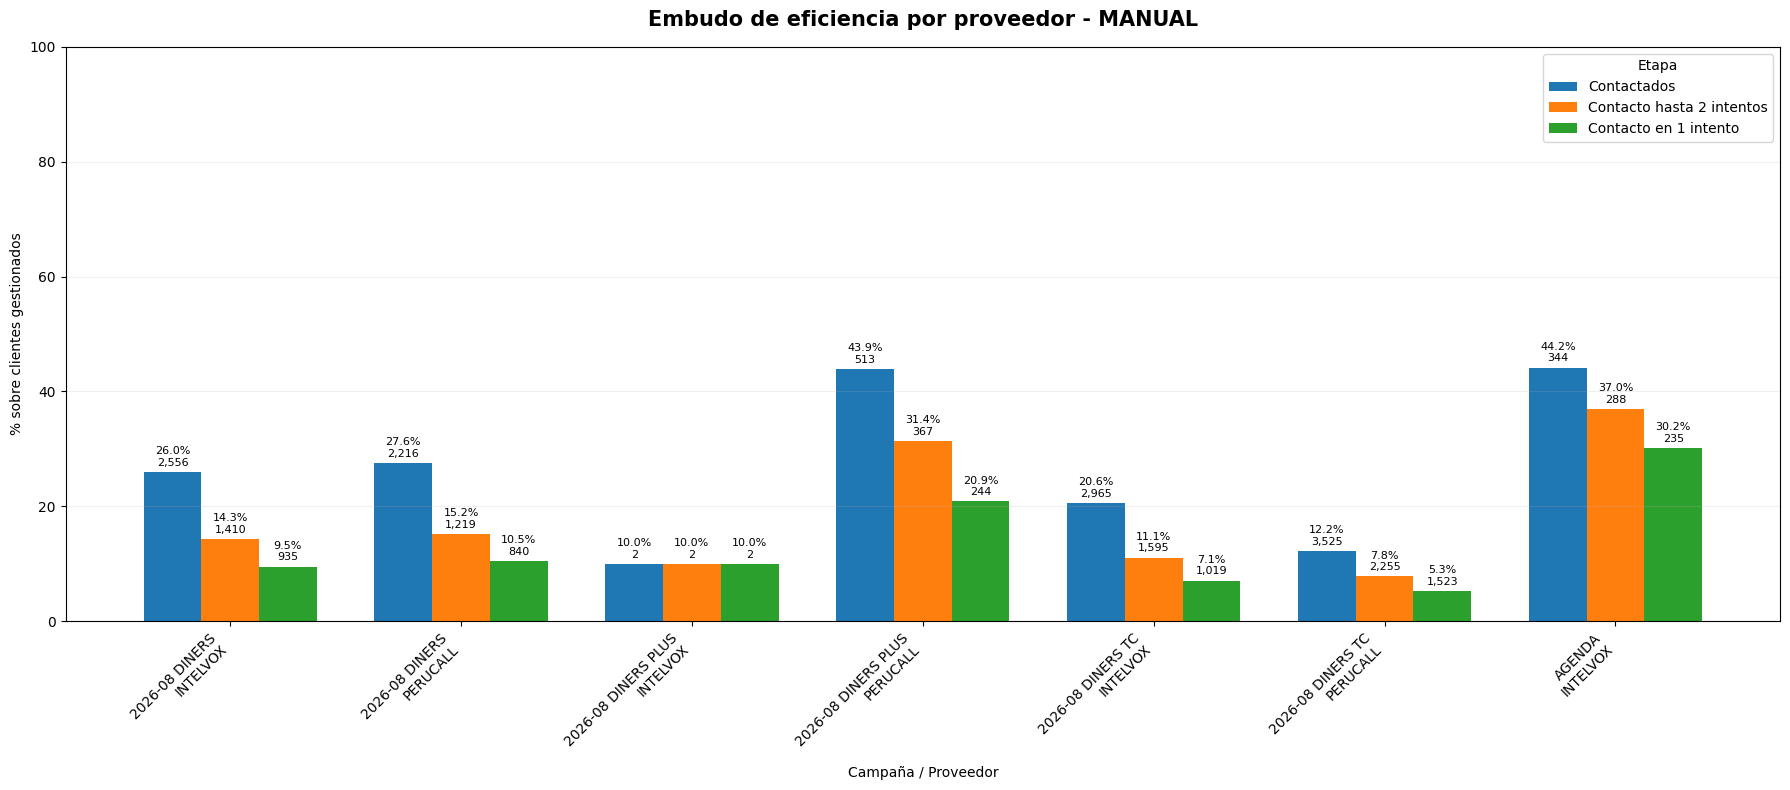

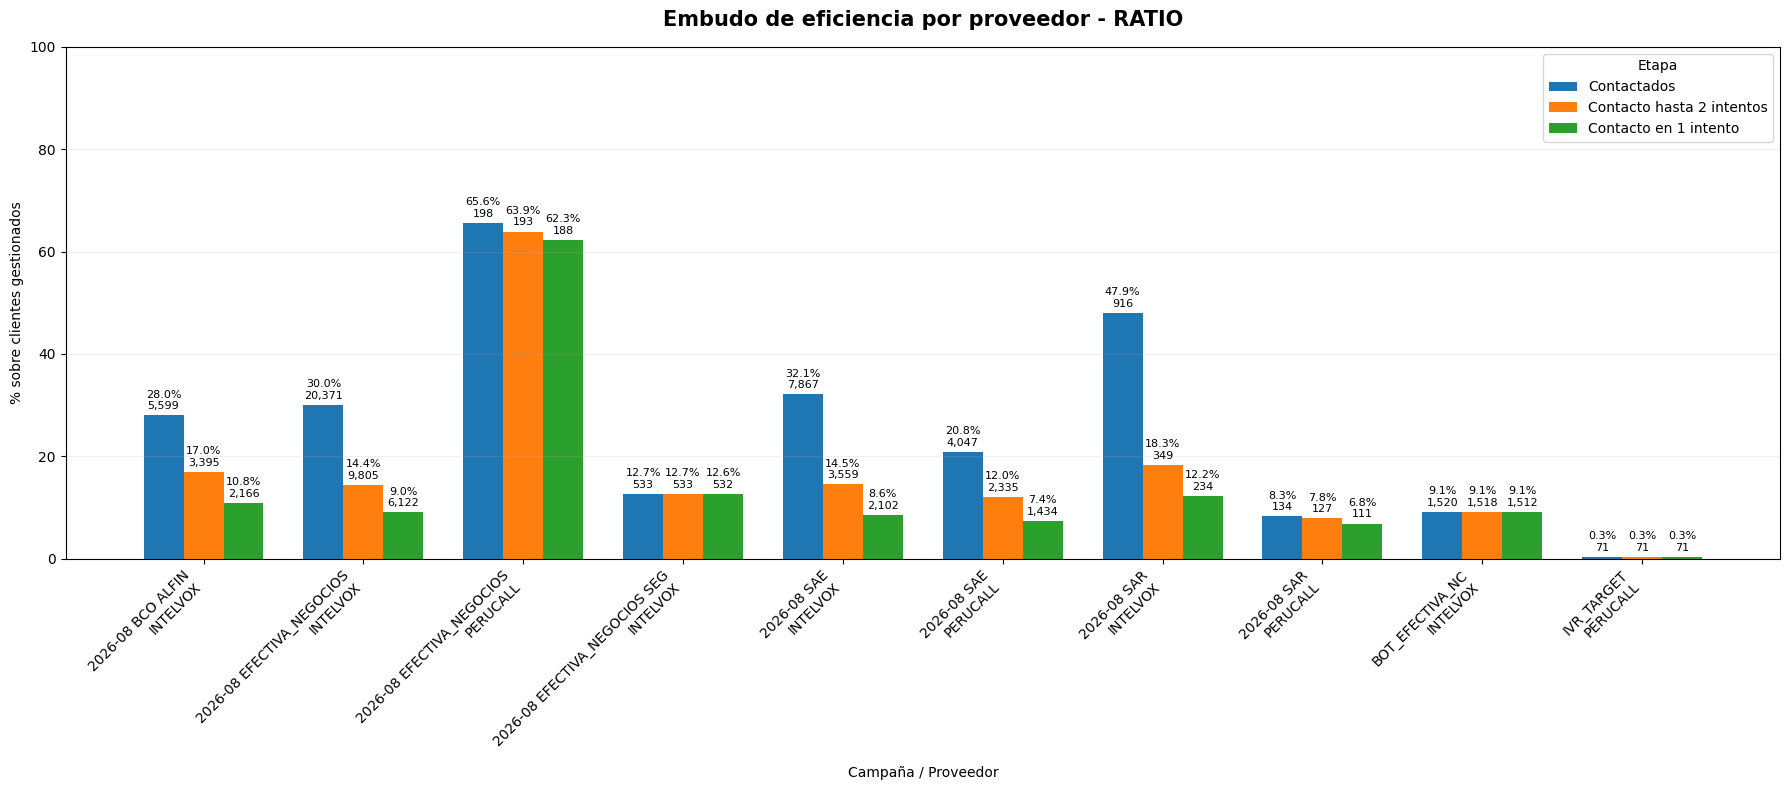

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ORDEN
# ============================================================

orden_dial = [
    "MANUAL",
    "RATIO"
]

proveedores_orden = [
    "INTELVOX",
    "PERUCALL"
]

# ============================================================
# GRÁFICO POR DIAL_METHOD
# ============================================================

for metodo in orden_dial:

    # --------------------------------------------------------
    # FILTRAR MÉTODO
    # --------------------------------------------------------

    df_plot = embudo[
        embudo["dial_method"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    # --------------------------------------------------------
    # ORDENAR
    # --------------------------------------------------------

    df_plot["proveedor"] = pd.Categorical(
        df_plot["proveedor"],
        categories=proveedores_orden,
        ordered=True
    )

    df_plot = df_plot.sort_values(
        [
            "nombre_campana",
            "proveedor"
        ]
    )

    # --------------------------------------------------------
    # ETIQUETA CAMPAÑA + PROVEEDOR
    # --------------------------------------------------------

    df_plot["grupo"] = (
        df_plot["nombre_campana"].astype(str)
        + "\n"
        + df_plot["proveedor"].astype(str)
    )

    # --------------------------------------------------------
    # POSICIONES
    # --------------------------------------------------------

    x = np.arange(
        len(df_plot)
    )

    width = 0.25

    # --------------------------------------------------------
    # GRÁFICO
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(18, 8)
    )

    b1 = ax.bar(
        x - width,
        df_plot["pct_contactados"],
        width,
        label="Contactados"
    )

    b2 = ax.bar(
        x,
        df_plot["pct_hasta_2_intentos"],
        width,
        label="Contacto hasta 2 intentos"
    )

    b3 = ax.bar(
        x + width,
        df_plot["pct_1_intento"],
        width,
        label="Contacto en 1 intento"
    )

    # ========================================================
    # ETIQUETAS: % + CANTIDAD
    # ========================================================

    etiquetas_contactados = [
        f"{pct:.1f}%\n{cant:,.0f}"
        for pct, cant in zip(
            df_plot["pct_contactados"],
            df_plot["clientes_contactados"]
        )
    ]

    etiquetas_2 = [
        f"{pct:.1f}%\n{cant:,.0f}"
        for pct, cant in zip(
            df_plot["pct_hasta_2_intentos"],
            df_plot["contacto_hasta_2_intentos"]
        )
    ]

    etiquetas_1 = [
        f"{pct:.1f}%\n{cant:,.0f}"
        for pct, cant in zip(
            df_plot["pct_1_intento"],
            df_plot["contacto_1_intento"]
        )
    ]

    ax.bar_label(
        b1,
        labels=etiquetas_contactados,
        padding=3,
        fontsize=8
    )

    ax.bar_label(
        b2,
        labels=etiquetas_2,
        padding=3,
        fontsize=8
    )

    ax.bar_label(
        b3,
        labels=etiquetas_1,
        padding=3,
        fontsize=8
    )

    # ========================================================
    # EJE X
    # ========================================================

    ax.set_xticks(x)

    ax.set_xticklabels(
        df_plot["grupo"],
        rotation=45,
        ha="right"
    )

    # ========================================================
    # FORMATO
    # ========================================================

    ax.set_title(
        f"Embudo de eficiencia por proveedor - {metodo}",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Campaña / Proveedor"
    )

    ax.set_ylabel(
        "% sobre clientes gestionados"
    )

    ax.set_ylim(
        0,
        max(
            100,
            df_plot["pct_contactados"].max() * 1.20
        )
    )

    ax.legend(
        title="Etapa"
    )

    ax.grid(
        axis="y",
        alpha=0.20
    )

    plt.tight_layout()
    plt.show()

In [73]:
df_total_agosto_02.groupby(
    [
        "nombre_campana",
        "proveedor",
        "dial_method"
    ],
    dropna=False
).size().reset_index(name="cantidad")

,nombre_campana,proveedor,dial_method,cantidad
0,2026-08 BCO ALFIN,INTELVOX,RATIO,64684
1,2026-08 DINERS,INTELVOX,MANUAL,51413
2,2026-08 DINERS,PERUCALL,MANUAL,38030
3,2026-08 DINERS PLUS,INTELVOX,MANUAL,20
4,2026-08 DINERS PLUS,PERUCALL,MANUAL,5065
5,2026-08 DINERS TC,INTELVOX,MANUAL,90240
6,2026-08 DINERS TC,PERUCALL,MANUAL,97609
7,2026-08 EFECTIVA_NEGOCIOS,INTELVOX,RATIO,428448
8,2026-08 EFECTIVA_NEGOCIOS,PERUCALL,RATIO,577
9,2026-08 EFECTIVA_NEGOCIOS SEG,INTELVOX,RATIO,4216


In [74]:
validacion_dial = (
    df_total_agosto_01
    .groupby(
        [
            "nombre_campana",
            "proveedor",
            "dial_method"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

display(
    validacion_dial[
        validacion_dial["nombre_campana"].isin([
            "2026-08 DINERS",
            "2026-08 DINERS TC"
        ])
    ]
)

,nombre_campana,proveedor,dial_method,cantidad
9,2026-08 DINERS,INTELVOX,MANUAL,51413
10,2026-08 DINERS,PERUCALL,MANUAL,38030
11,2026-08 DINERS,PROVEEDOR NO IDENTIFICADO,MANUAL,13
15,2026-08 DINERS TC,INTELVOX,MANUAL,90240
16,2026-08 DINERS TC,PERUCALL,MANUAL,97609
17,2026-08 DINERS TC,PROVEEDOR NO IDENTIFICADO,MANUAL,7


In [75]:
display(
    df_total_agosto_01.loc[
        df_total_agosto_01["nombre_campana"].isin([
            "2026-08 DINERS",
            "2026-08 DINERS TC"
        ]),
        [
            "nombre_campana",
            "proveedor",
            "server_ip",
            "dial_method"
        ]
    ]
    .value_counts(dropna=False)
    .reset_index(name="cantidad")
)

,nombre_campana,proveedor,server_ip,dial_method,cantidad
0,2026-08 DINERS TC,PERUCALL,192.168.3.21,MANUAL,97609
1,2026-08 DINERS TC,INTELVOX,192.168.3.21,MANUAL,90240
2,2026-08 DINERS,INTELVOX,192.168.3.21,MANUAL,51413
3,2026-08 DINERS,PERUCALL,192.168.3.21,MANUAL,38030
4,2026-08 DINERS,PROVEEDOR NO IDENTIFICADO,NaN,MANUAL,13
5,2026-08 DINERS TC,PROVEEDOR NO IDENTIFICADO,NaN,MANUAL,7


In [71]:
embudo.head(10)

,nombre_campana,dial_method,proveedor,clientes_gestionados,clientes_contactados,contacto_hasta_2_intentos,contacto_1_intento,pct_contactados,pct_hasta_2_intentos,pct_1_intento
0,2026-08 BCO ALFIN,RATIO,INTELVOX,20011,5599,3395,2166,27.979611,16.965669,10.824047
1,2026-08 DINERS,MANUAL,INTELVOX,9829,2556,1410,935,26.004680,14.345305,9.512667
2,2026-08 DINERS,MANUAL,PERUCALL,8027,2216,1219,840,27.606827,15.186246,10.464682
3,2026-08 DINERS PLUS,MANUAL,INTELVOX,20,2,2,2,10.000000,10.000000,10.000000
4,2026-08 DINERS PLUS,MANUAL,PERUCALL,1168,513,367,244,43.921233,31.421233,20.890411
5,2026-08 DINERS TC,MANUAL,INTELVOX,14400,2965,1595,1019,20.590278,11.076389,7.076389
6,2026-08 DINERS TC,MANUAL,PERUCALL,28883,3525,2255,1523,12.204411,7.807361,5.272998
7,2026-08 EFECTIVA_NEGOCIOS,RATIO,INTELVOX,67948,20371,9805,6122,29.980279,14.430152,9.009831
8,2026-08 EFECTIVA_NEGOCIOS,RATIO,PERUCALL,302,198,193,188,65.562914,63.907285,62.251656
9,2026-08 EFECTIVA_NEGOCIOS SEG,RATIO,INTELVOX,4207,533,533,532,12.669361,12.669361,12.645591


In [101]:
dead_promedio=("dead_sec", "mean")

In [102]:
# Solo llamadas donde realmente hubo dead
solo_dead = df_dead[
    df_dead["tiene_dead"]
].copy()

resumen_solo_dead = (
    solo_dead
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        dropna=False
    )
    .agg(
        llamadas_con_dead=("lead_id", "size"),

        dead_promedio_cuando_ocurre=(
            "dead_sec",
            "mean"
        ),

        dead_mediana_cuando_ocurre=(
            "dead_sec",
            "median"
        ),

        dead_p90_cuando_ocurre=(
            "dead_sec",
            lambda x: x.quantile(0.90)
        )
    )
    .reset_index()
)

display(
    resumen_solo_dead.round(2)
)

,nombre_campana,dial_method,proveedor,llamadas_con_dead,dead_promedio_cuando_ocurre,dead_mediana_cuando_ocurre,dead_p90_cuando_ocurre
0,2026-08 BCO ALFIN,RATIO,INTELVOX,2334,15.88,6.0,41.0
1,2026-08 DINERS,MANUAL,INTELVOX,3248,14.62,5.0,38.0
2,2026-08 DINERS,MANUAL,PERUCALL,3069,19.29,6.0,44.0
3,2026-08 DINERS PLUS,MANUAL,INTELVOX,2,1.00,1.0,1.0
4,2026-08 DINERS PLUS,MANUAL,PERUCALL,580,17.15,4.0,43.0
5,2026-08 DINERS TC,MANUAL,INTELVOX,6260,8.64,4.0,27.0
6,2026-08 DINERS TC,MANUAL,PERUCALL,7861,8.75,4.0,30.0
7,2026-08 EFECTIVA_NEGOCIOS,RATIO,INTELVOX,20485,8.45,3.0,22.0
8,2026-08 EFECTIVA_NEGOCIOS,RATIO,PERUCALL,52,8.96,2.5,27.4
9,2026-08 SAE,RATIO,INTELVOX,10670,14.56,5.0,35.0


In [52]:
query_vic = f"""
SELECT *
FROM OPENQUERY([192.168.3.{21}], '
    SELECT *
    FROM asterisk.vicidial_agent_log
    LIMIT 10
')
"""

df_ref = pd.read_sql(
    query_vic,
    engine_zeus
)

df_ref.head()

,agent_log_id,user,server_ip,event_time,lead_id,campaign_id,pause_epoch,pause_sec,wait_epoch,wait_sec,talk_epoch,talk_sec,dispo_epoch,dispo_sec,status,user_group,comments,sub_status,dead_epoch,dead_sec,processed,uniqueid,pause_type
0,2179647.0,TCD042,192.168.3.21,2026-08-07 09:04:11,10793175.0,136,1.786111e+09,2.0,1.786111e+09,36.0,1.786111e+09,0.0,1.786111e+09,6.0,E022,G1,MANUAL,None,NaN,0.0,N,,AGENT
1,2179646.0,TCD042,192.168.3.21,2026-08-07 09:04:11,NaN,136,1.786111e+09,0.0,1.786111e+09,0.0,NaN,0.0,NaN,0.0,None,G1,None,None,NaN,0.0,N,,AGENT
2,2179645.0,TCD054,192.168.3.21,2026-08-07 09:04:05,10791214.0,412,1.786111e+09,141.0,1.786112e+09,43.0,1.786112e+09,52.0,1.786112e+09,4.0,C009,Diners_SSFF,None,LOGIN,1.786112e+09,35.0,N,1786111605.118497,AGENT
3,2179644.0,TCD016,192.168.3.21,2026-08-07 09:03:55,10792937.0,136,1.786111e+09,0.0,1.786111e+09,47.0,1.786111e+09,11.0,1.786111e+09,3.0,E039,G1,None,None,NaN,0.0,N,1786111439.118287,AGENT
4,2179643.0,TCD055,192.168.3.21,2026-08-07 09:03:50,NaN,412,1.786111e+09,4.0,1.786111e+09,0.0,NaN,0.0,NaN,0.0,None,Diners_SSFF,None,LOGIN,NaN,0.0,N,,AGENT


In [53]:
df_ref.columns.tolist()

['agent_log_id',
 'user',
 'server_ip',
 'event_time',
 'lead_id',
 'campaign_id',
 'pause_epoch',
 'pause_sec',
 'wait_epoch',
 'wait_sec',
 'talk_epoch',
 'talk_sec',
 'dispo_epoch',
 'dispo_sec',
 'status',
 'user_group',
 'comments',
 'sub_status',
 'dead_epoch',
 'dead_sec',
 'processed',
 'uniqueid',
 'pause_type']

In [35]:
resumen_duracion = (
    df_base
    .groupby(
        [
            "proveedor",
            "dial_method",
            "tipo_contacto"
        ]
    )
    .agg(
        llamadas=("duracion", "size"),
        promedio_seg=("duracion", "mean"),
        mediana_seg=("duracion", "median"),
        minimo_seg=("duracion", "min"),
        maximo_seg=("duracion", "max")
    )
    .reset_index()
)

display(resumen_duracion)

,proveedor,dial_method,tipo_contacto,llamadas,promedio_seg,mediana_seg,minimo_seg,maximo_seg
0,INTELVOX,MANUAL,CONTACTO,730,60.587912,30.0,0.0,2089.0
1,INTELVOX,MANUAL,NO CONTACTO,1242,19.047504,6.0,0.0,1799.0
2,INTELVOX,RATIO,CONTACTO,66531,39.333023,24.0,0.0,4709.0
3,INTELVOX,RATIO,NO CONTACTO,763538,1.578649,0.0,0.0,4496.0
4,PERUCALL,MANUAL,CONTACTO,1130,75.040816,36.0,0.0,1865.0
5,PERUCALL,MANUAL,NO CONTACTO,3280,24.347256,6.0,-3.0,3694.0
6,PERUCALL,RATIO,CONTACTO,14056,57.040453,31.0,0.0,3601.0
7,PERUCALL,RATIO,NO CONTACTO,186960,2.757911,0.0,0.0,3764.0


In [38]:
tabla_intentos = tabla_intentos.reset_index()

display(
    tabla_intentos.round(2)
)

rango_intento,nombre_campana,dial_method,proveedor,1 intento,2 intentos,3 intentos,4 intentos,5+ intentos,TOTAL
0,2026-08 BCO ALFIN,RATIO,INTELVOX,38.42,22.77,16.75,9.98,12.09,100.0
1,2026-08 DINERS,RATIO,INTELVOX,36.58,18.58,13.30,8.37,23.16,100.0
2,2026-08 DINERS,RATIO,PERUCALL,33.98,16.91,14.52,10.98,23.62,100.0
3,2026-08 DINERS PLUS,MANUAL,INTELVOX,100.00,0.00,0.00,0.00,0.00,100.0
4,2026-08 DINERS PLUS,MANUAL,PERUCALL,43.75,26.20,14.66,9.86,5.53,100.0
5,2026-08 DINERS TC,RATIO,INTELVOX,36.75,16.31,10.41,7.21,29.31,100.0
6,2026-08 DINERS TC,RATIO,PERUCALL,43.21,20.77,11.55,6.75,17.73,100.0
7,2026-08 EFECTIVA_NEGOCIOS,RATIO,INTELVOX,29.56,17.27,11.00,7.68,34.48,100.0
8,2026-08 EFECTIVA_NEGOCIOS,RATIO,PERUCALL,94.95,2.53,1.01,0.51,1.01,100.0
9,2026-08 SAE,RATIO,INTELVOX,27.47,18.82,10.86,7.23,35.62,100.0


In [39]:
import pandas as pd

# ============================================================
# 1. PREPARAR BASE
# ============================================================

df_duracion = df_base.copy()

# Asegurar que duración sea numérica
df_duracion["duracion"] = pd.to_numeric(
    df_duracion["duracion"],
    errors="coerce"
)

# Quitamos duraciones nulas
df_duracion = df_duracion[
    df_duracion["duracion"].notna()
].copy()


# ============================================================
# 2. RESUMEN POR CAMPAÑA
# ============================================================

resumen_duracion = (
    df_duracion
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor",
            "tipo_contacto"
        ],
        dropna=False
    )
    .agg(
        llamadas=("duracion", "size"),
        promedio_seg=("duracion", "mean"),
        mediana_seg=("duracion", "median"),
        minimo_seg=("duracion", "min"),
        maximo_seg=("duracion", "max")
    )
    .reset_index()
)


# ============================================================
# 3. REDONDEAR
# ============================================================

resumen_duracion[
    [
        "promedio_seg",
        "mediana_seg",
        "minimo_seg",
        "maximo_seg"
    ]
] = (
    resumen_duracion[
        [
            "promedio_seg",
            "mediana_seg",
            "minimo_seg",
            "maximo_seg"
        ]
    ]
    .round(2)
)


display(resumen_duracion)

,nombre_campana,dial_method,proveedor,tipo_contacto,llamadas,promedio_seg,mediana_seg,minimo_seg,maximo_seg
0,2026-08 BCO ALFIN,RATIO,INTELVOX,CONTACTO,7718,35.18,21.0,0.0,3576.0
1,2026-08 BCO ALFIN,RATIO,INTELVOX,NO CONTACTO,50928,2.29,1.0,0.0,3211.0
2,2026-08 DINERS,RATIO,INTELVOX,CONTACTO,3819,45.81,31.0,2.0,1858.0
3,2026-08 DINERS,RATIO,INTELVOX,NO CONTACTO,47594,1.70,0.0,0.0,907.0
4,2026-08 DINERS,RATIO,PERUCALL,CONTACTO,3845,55.20,33.0,0.0,3134.0
5,2026-08 DINERS,RATIO,PERUCALL,NO CONTACTO,30689,4.81,0.0,0.0,3764.0
6,2026-08 DINERS PLUS,MANUAL,INTELVOX,CONTACTO,2,54.00,54.0,24.0,84.0
7,2026-08 DINERS PLUS,MANUAL,INTELVOX,NO CONTACTO,18,0.28,0.0,0.0,5.0
8,2026-08 DINERS PLUS,MANUAL,PERUCALL,CONTACTO,1127,75.04,36.0,0.0,1865.0
9,2026-08 DINERS PLUS,MANUAL,PERUCALL,NO CONTACTO,3280,24.35,6.0,-3.0,3694.0


In [40]:
tabla_duracion_mediana = (
    resumen_duracion
    .pivot_table(
        index=[
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        columns="tipo_contacto",
        values="mediana_seg",
        aggfunc="first",
        fill_value=0
    )
    .reset_index()
)

display(tabla_duracion_mediana)

tipo_contacto,nombre_campana,dial_method,proveedor,CONTACTO,NO CONTACTO
0,2026-08 BCO ALFIN,RATIO,INTELVOX,21.0,1.0
1,2026-08 DINERS,RATIO,INTELVOX,31.0,0.0
2,2026-08 DINERS,RATIO,PERUCALL,33.0,0.0
3,2026-08 DINERS PLUS,MANUAL,INTELVOX,54.0,0.0
4,2026-08 DINERS PLUS,MANUAL,PERUCALL,36.0,6.0
5,2026-08 DINERS TC,RATIO,INTELVOX,35.0,1.0
6,2026-08 DINERS TC,RATIO,PERUCALL,35.0,1.0
7,2026-08 EFECTIVA_NEGOCIOS,RATIO,INTELVOX,21.0,0.0
8,2026-08 EFECTIVA_NEGOCIOS,RATIO,PERUCALL,16.0,7.0
9,2026-08 SAE,RATIO,INTELVOX,30.0,0.0


In [42]:
# df_base[
#     (df_base["nombre_campana"] == "2026-08 EFECTIVA_NEGOCIOS") &
#     (df_base["proveedor"] == "PERUCALL") &
#     (df_base["dial_method"] == "RATIO") &
#     (df_base["tipo_contacto"] == "NO CONTACTO")
# ][
#     [
#         "fecha_hora_llamada",
#         "vendor_lead_code",
#         "codigo",
#         "call_result",
#         "duracion",
#         "sip_hangup_cause",
#         "sip_hangup_reason"
#     ]
# ].sort_values("duracion")

In [ ]:
# df_total_agosto_01[
#     df_total_agosto_01["proveedor"].isna()
# ]["dial_method"].value_counts(dropna=False)

ruta_archivo = os.path.join(ruta_csv, 'ver_2.xlsx')

resumen_sip.to_excel(ruta_archivo, index=False)
# validacion["cantidad"].isna().sum()

# df_exportar = df_grafico_campana.reset_index()
# df_exportar.to_excel(ruta_archivo, index=False)

# df_total_agosto_01[
#     df_total_agosto_01["proveedor"].isna()
# ]["dial_method"].value_counts(dropna=False)

ruta_archivo = os.path.join(ruta_csv, 'ver_2.xlsx')

resumen.to_excel(ruta_archivo, index=False)
# validacion["cantidad"].isna().sum()

# df_exportar = df_grafico_campana.reset_index()
# df_exportar.to_excel(ruta_archivo, index=False)


df_total_agosto_01.shape
ruta_archivo = os.path.join(ruta_csv, 'ver_1.xlsx')

resumen.to_excel(ruta_archivo, index=False)

## por campaña


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. PREPARAR BASE
# ============================================================

df_cambios = df_total_agosto_01.copy()


df_cambios["fecha_hora_llamada"] = pd.to_datetime(
    df_cambios["fecha_hora_llamada"],
    errors="coerce"
)

df_cambios["fecha"] = df_cambios["fecha_hora_llamada"].dt.date
df_cambios["hora"] = df_cambios["fecha_hora_llamada"].dt.hour


# ============================================================
# 2. FILTRAR CAMPAÑA Y FECHA
# ============================================================

campana = "2026-08 DINERS TC"
fecha_analisis = pd.to_datetime("2026-08-05").date()

df_dia = df_cambios[
    (df_cambios["nombre_campana"] == campana)
    &
    (df_cambios["fecha"] == fecha_analisis)
    &
    (df_cambios["proveedor"].isin(["PERUCALL", "INTELVOX"]))
].copy()


# ============================================================
# 3. CONTAR LLAMADAS POR HORA Y PROVEEDOR
# ============================================================

tabla_hora = (
    df_dia
    .groupby(["hora", "proveedor"])
    .size()
    .unstack(fill_value=0)
)

# Asegurar que existan ambas columnas
for proveedor in ["PERUCALL", "INTELVOX"]:
    if proveedor not in tabla_hora.columns:
        tabla_hora[proveedor] = 0

tabla_hora = tabla_hora[
    ["PERUCALL", "INTELVOX"]
]

display(tabla_hora)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. PREPARAR DATOS
# ============================================================

df_diners = df_total_agosto_01.copy()

df_diners["fecha_hora_llamada"] = pd.to_datetime(
    df_diners["fecha_hora_llamada"],
    errors="coerce"
)

df_diners["fecha"] = (
    df_diners["fecha_hora_llamada"]
    .dt.date
)

# ============================================================
# 2. FILTRAR DINERS TC
# ============================================================

df_diners = df_diners[
    (df_diners["nombre_campana"] == "2026-08 DINERS TC")
    &
    (df_diners["proveedor"].isin(["PERUCALL", "INTELVOX"]))
].copy()

# ============================================================
# 3. RESUMEN POR DÍA Y PROVEEDOR
# ============================================================

tabla_dia = (
    df_diners
    .groupby(
        ["fecha", "proveedor"]
    )
    .size()
    .unstack(fill_value=0)
)

# asegurar columnas
for proveedor in ["PERUCALL", "INTELVOX"]:
    if proveedor not in tabla_dia.columns:
        tabla_dia[proveedor] = 0

tabla_dia = tabla_dia[
    ["PERUCALL", "INTELVOX"]
]

display(tabla_dia)

In [ ]:
# ============================================================
# 4. GRÁFICO DIARIO + CANTIDAD + PORCENTAJE
# ============================================================

import matplotlib.pyplot as plt

# Total de llamadas de cada día
total_dia = tabla_dia.sum(axis=1)

# Porcentaje de cada proveedor dentro del día
tabla_pct = (
    tabla_dia
    .div(total_dia, axis=0)
    .mul(100)
)


# ============================================================
# GRÁFICO
# ============================================================

ax = tabla_dia.plot(
    kind="bar",
    figsize=(14, 6)
)

ax.set_title(
    "DINERS TC - Uso diario por proveedor",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de llamadas")

ax.legend(
    title="Proveedor"
)

plt.xticks(
    rotation=45,
    ha="right"
)


# ============================================================
# ETIQUETAS: CANTIDAD + PORCENTAJE
# ============================================================

for container, proveedor in zip(
    ax.containers,
    tabla_dia.columns
):

    etiquetas = []

    for fecha, cantidad in zip(
        tabla_dia.index,
        tabla_dia[proveedor]
    ):

        porcentaje = tabla_pct.loc[
            fecha,
            proveedor
        ]

        # No mostrar etiqueta cuando sea 0
        if cantidad > 0:

            etiquetas.append(
                f"{cantidad:,.0f}\n({porcentaje:.1f}%)"
            )

        else:

            etiquetas.append("")

    ax.bar_label(
        container,
        labels=etiquetas,
        padding=3,
        fontsize=8
    )


plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 5. PARTICIPACIÓN % POR DÍA
# ============================================================

tabla_pct = (
    tabla_dia
    .div(
        tabla_dia.sum(axis=1),
        axis=0
    )
    * 100
)

tabla_pct = tabla_pct.round(2)

display(tabla_pct)

In [40]:
# ============================================================
# PROVEEDORES UTILIZADOS POR CAMPAÑA
# ============================================================

resumen_campana_proveedor = (
    df_total_agosto[
        df_total_agosto["proveedor"].isin(
            ["PERUCALL", "INTELVOX"]
        )
    ]
    .groupby(
        [
            "servidor",
            "nombre_campana",
            "proveedor"
        ]
    )
    .size()
    .reset_index(name="cantidad")
)

tabla_campana_proveedor = (
    resumen_campana_proveedor
    .pivot_table(
        index=[
            "servidor",
            "nombre_campana"
        ],
        columns="proveedor",
        values="cantidad",
        fill_value=0
    )
    .reset_index()
)

print(
    tabla_campana_proveedor.to_string(index=False)
)

    servidor            nombre_campana  INTELVOX  PERUCALL
192.168.3.21            2026-07 DINERS    2571.0     113.0
192.168.3.21       2026-07 DINERS PLUS       9.0      18.0
192.168.3.21         2026-07 DINERS TC       0.0     135.0
192.168.3.21            2026-08 DINERS   21018.0   31595.0
192.168.3.21       2026-08 DINERS PLUS      20.0    2964.0
192.168.3.21         2026-08 DINERS TC   29345.0   97609.0
192.168.3.64 2026-08 EFECTIVA_NEGOCIOS  310228.0     577.0
 192.168.3.7       2026-07 EFECTIVA_NC      84.0       0.0
 192.168.3.7           BOT_EFECTIVA_NC   16738.0       0.0
192.168.3.76               2026-08 SAE  185567.0       0.0
192.168.3.76               2026-08 SAR   22944.0       0.0
192.168.3.76                    AGENDA    1111.0       0.0


In [41]:
df_analisis = df_total_agosto[
    df_total_agosto["proveedor"].isin(
        ["PERUCALL", "INTELVOX"]
    )
].copy()

df_analisis["fecha"] = (
    df_analisis["fecha_hora_llamada"]
    .dt.date
)

df_analisis["hora"] = (
    df_analisis["fecha_hora_llamada"]
    .dt.hour
)

In [42]:
resumen_hora = (
    df_analisis
    .groupby(
        [
            "servidor",
            "nombre_campana",
            "fecha",
            "hora",
            "proveedor"
        ]
    )
    .size()
    .reset_index(name="llamadas")
)

tabla_hora = (
    resumen_hora
    .pivot_table(
        index=[
            "servidor",
            "nombre_campana",
            "fecha",
            "hora"
        ],
        columns="proveedor",
        values="llamadas",
        fill_value=0
    )
    .reset_index()
)

print(
    tabla_hora.to_string(index=False)
)

    servidor            nombre_campana      fecha  hora  INTELVOX  PERUCALL
192.168.3.21            2026-07 DINERS 2026-08-01     9    1027.0      15.0
192.168.3.21            2026-07 DINERS 2026-08-01    10     871.0      18.0
192.168.3.21            2026-07 DINERS 2026-08-01    11       0.0      10.0
192.168.3.21            2026-07 DINERS 2026-08-01    12       0.0       1.0
192.168.3.21            2026-07 DINERS 2026-08-01    13       0.0      18.0
192.168.3.21            2026-07 DINERS 2026-08-01    14       0.0       3.0
192.168.3.21            2026-07 DINERS 2026-08-03     9      12.0       4.0
192.168.3.21            2026-07 DINERS 2026-08-03    14     174.0       9.0
192.168.3.21            2026-07 DINERS 2026-08-03    15     187.0      14.0
192.168.3.21            2026-07 DINERS 2026-08-04     9      40.0       7.0
192.168.3.21            2026-07 DINERS 2026-08-04    10     162.0       4.0
192.168.3.21            2026-07 DINERS 2026-08-04    11      79.0       5.0
192.168.3.21

In [16]:
diners = tabla_hora[
    tabla_hora["nombre_campana"]
    .str.contains(
        "2026-08 DINERS TC",
        case=False,
        na=False
    )
].copy()

print(
    diners.to_string(index=False)
)

    servidor    nombre_campana      fecha  hora  INTELVOX  PERUCALL
192.168.3.21 2026-08 DINERS TC 2026-08-01     9       4.0    1023.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    10       4.0    2412.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    11      18.0    1824.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    12       9.0    2725.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    13      23.0    1923.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    14       2.0      82.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    16       4.0       2.0
192.168.3.21 2026-08 DINERS TC 2026-08-03     9      18.0    1182.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    10      13.0    1672.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    11      22.0    1950.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    12      16.0     980.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    13      93.0    1317.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    14      39.0       0.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    15 

In [8]:
fecha_mes_base

'2026-08-01'

In [ ]:
servidor_01=76
tipi_cond1='SAE'
tipi_cond2='SAR'
tipi_cond3='AGENDA'

servidor_01=7
tipi_cond1='EFECTIVA_NC'
tipi_cond2='xx'
tipi_cond3='xx'

servidor_01=7
tipi_cond1='BCO ALFIN'
tipi_cond2='xx'
tipi_cond3='xx'

servidor_01=64
tipi_cond1='EFECTIVA_NEGOCIOS'
tipi_cond2='xx'
tipi_cond3='xx'    

servidor_01=21
tipi_cond1='DINERS TC'
tipi_cond2='xx'
tipi_cond3='xx'

servidor_01=21
tipi_cond1='plus'
tipi_cond2='PPD'
tipi_cond3='xx'

In [ ]:
servidores = [
    "21",
    "76",
    "7",
    "64"
]


def obtener_info_servidor( servidor,fecha_mes_base, engine_zeus, tipi_cond1, tipi_cond2 , tipi_cond3 ):
    print("=" * 70)
    print(f"PROCESANDO SERVIDOR: 192.168.3.{servidor}")
    print("=" * 70)
    query_dial = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '
    SELECT
        call_date,
        lead_id,
        server_ip,
        extension,
        channel,
        context,
        outbound_cid,
        sip_hangup_cause,
        sip_hangup_reason,
        uniqueid,
        caller_code,
        CASE
            WHEN extension LIKE ''888%'' OR channel LIKE ''Local/888%'' THEN ''PERUCALL''
            WHEN extension LIKE ''899%'' OR channel LIKE ''Local/899%'' THEN ''INTELVOX''
            ELSE ''OTRO''
        END AS proveedor

    FROM asterisk.vicidial_dial_log

    WHERE call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')

    AND call_date <
        DATE_ADD(
            DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''),
            INTERVAL 1 MONTH
        )
    ')
    """
    df_dial = pd.read_sql( query_dial, engine_zeus )
    print( "Dial Log:", len(df_dial) )

    # ========================================================
    # 2. EXTRAER VICIDIAL LOG
    # ========================================================

    query_vic = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '
    SELECT
        a.lead_id,a.uniqueid,
        RTRIM(LTRIM(d.vendor_lead_code)) AS vendor_lead_code,
        e.dial_method,
        a.campaign_id AS numero_campana,
        a.user AS dni_ejecutivo,
        c.full_name AS ejecutivo,
        e.campaign_name AS nombre_campana,
        a.call_date AS fecha_hora_llamada,
        a.length_in_sec AS duracion,
        b.status_name AS call_result,
        f.list_description,
        f.list_name,
        a.phone_numberAS phone_number,
        d.alt_phone AS fecha_agenda,
        d.comments AS comentarios,
        a.status AS codigo
    FROM asterisk.vicidial_log a
    LEFT JOIN asterisk.vicidial_list d ON a.lead_id = d.lead_id
    LEFT JOIN asterisk.vicidial_campaigns e ON a.campaign_id = e.campaign_id
    LEFT JOIN asterisk.vicidial_lists f ON a.list_id = f.list_id
    LEFT JOIN asterisk.vicidial_statuses b ON a.status = b.status
    LEFT JOIN asterisk.vicidial_users c ON a.user = c.user
    WHERE (
        e.campaign_name LIKE "%{tipi_cond1}"
        OR e.campaign_name LIKE "%{tipi_cond2}"
        OR e.campaign_name LIKE "%{tipi_cond3}"
    )
    AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
    AND a.call_date <DATE_ADD(
            DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''),
            INTERVAL 1 MONTH
        )
    ')
    """

    df_vic = pd.read_sql( query_vic, engine_zeus)
    print("Vicidial Log:", len(df_vic) )

    # ========================================================
    # 3. PREPARAR DIAL LOG
    # ========================================================

    df_dial["call_date"] = pd.to_datetime(
        df_dial["call_date"],
        errors="coerce"
    )

    df_dial["lead_id"] = pd.to_numeric(
        df_dial["lead_id"],
        errors="coerce"
    )

    df_dial = (
        df_dial
        .dropna(
            subset=[
                "lead_id",
                "call_date"
            ]
        )
        .copy()
    )

    df_dial["lead_id"] = (
        df_dial["lead_id"]
        .astype("int64")
    )

    df_dial = (
        df_dial
        .sort_values(
            [
                "call_date",
                "lead_id"
            ]
        )
        .reset_index(drop=True)
    )

    # ========================================================
    # 4. PREPARAR VICIDIAL LOG
    # ========================================================

    df_vic["fecha_hora_llamada"] = pd.to_datetime(
        df_vic["fecha_hora_llamada"],
        errors="coerce"
    )

    df_vic["lead_id"] = pd.to_numeric(
        df_vic["lead_id"],
        errors="coerce"
    )

    df_vic = (
        df_vic
        .dropna(
            subset=[
                "lead_id",
                "fecha_hora_llamada"
            ]
        )
        .copy()
    )

    df_vic["lead_id"] = (
        df_vic["lead_id"]
        .astype("int64")
    )

    df_vic = (
        df_vic
        .sort_values(
            [
                "fecha_hora_llamada",
                "lead_id"
            ]
        )
        .reset_index(drop=True)
    )

    # ========================================================
    # 5. CRUZAR AMBAS TABLAS
    # ========================================================

    df_final = pd.merge_asof(
        df_vic,

        df_dial[
            [
                "lead_id",
                "call_date",
                "proveedor",
                "sip_hangup_cause",
                "sip_hangup_reason",
                "extension",
                "channel",
                "context",
                "server_ip",
                "caller_code"
            ]
        ],

        left_on="fecha_hora_llamada",
        right_on="call_date",

        by="lead_id",

        direction="backward",

        tolerance=pd.Timedelta(
            seconds=90
        )
    )

    # ========================================================
    # 6. DIFERENCIA ENTRE LOGS
    # ========================================================

    df_final["diferencia_segundos"] = (
        df_final["fecha_hora_llamada"]
        - df_final["call_date"]
    ).dt.total_seconds()

    # ========================================================
    # 7. AGREGAR SERVIDOR
    # ========================================================

    df_final["servidor"] = (
        f"192.168.3.{servidor}"
    )

    # ========================================================
    # 8. VALIDACIÓN
    # ========================================================

    total = len(df_final)

    con_proveedor = (
        df_final["proveedor"]
        .notna()
        .sum()
    )

    porcentaje = (
        con_proveedor
        / total
        * 100
        if total > 0
        else 0
    )

    print(
        "Con proveedor:",
        con_proveedor
    )

    print(
        "% Match:",
        round(
            porcentaje,
            2
        ),
        "%"
    )

    print()

    print(
        df_final["proveedor"]
        .value_counts(
            dropna=False
        )
    )

    return df_final

In [39]:
lista_servidores = []

for servidor in servidores:

    try:

        df_temp = obtener_info_servidor(
            servidor=servidor,
            fecha_mes_base=fecha_mes_base,
            engine_zeus=engine_zeus,
            tipi_cond1=tipi_cond1,
            tipi_cond2=tipi_cond2,
            tipi_cond3=tipi_cond3
        )

        lista_servidores.append(
            df_temp
        )

    except Exception as e:

        print(
            f"ERROR SERVIDOR {servidor}:"
        )

        print(e)

        print()

PROCESANDO SERVIDOR: 192.168.3.21
Dial Log: 181754
Vicidial Log: 124685
Con proveedor: 124674
% Match: 99.99 %

proveedor
PERUCALL    97744
INTELVOX    26930
NaN            11
Name: count, dtype: int64
PROCESANDO SERVIDOR: 192.168.3.76
Dial Log: 207419
Vicidial Log: 0
Con proveedor: 0
% Match: 0 %

Series([], Name: count, dtype: int64)
PROCESANDO SERVIDOR: 192.168.3.7
Dial Log: 16822
Vicidial Log: 0
Con proveedor: 0
% Match: 0 %

Series([], Name: count, dtype: int64)
PROCESANDO SERVIDOR: 192.168.3.64
Dial Log: 351651
Vicidial Log: 0
Con proveedor: 0
% Match: 0 %

Series([], Name: count, dtype: int64)


In [40]:
# ============================================================
# CONSOLIDAR TODOS LOS SERVIDORES
# ============================================================

df_total_agosto = pd.concat(
    lista_servidores,
    ignore_index=True
)

print(
    "TOTAL REGISTROS:",
    len(df_total_agosto)
)

TOTAL REGISTROS: 124685


C:\Users\DATA\AppData\Local\Temp\ipykernel_2660\1100834236.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_total_agosto = pd.concat(


In [41]:
print(
    df_total_agosto[
        "servidor"
    ].value_counts()
)

print()

print(
    df_total_agosto[
        "proveedor"
    ].value_counts(
        dropna=False
    )
)

servidor
192.168.3.21    124685
Name: count, dtype: int64

proveedor
PERUCALL    97744
INTELVOX    26930
NaN            11
Name: count, dtype: int64


In [42]:
control_servidor = (
    df_total_agosto
    .groupby(
        [
            "servidor",
            "proveedor"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="cantidad"
    )
)

print(
    control_servidor
    .to_string(index=False)
)

    servidor proveedor  cantidad
192.168.3.21  INTELVOX     26930
192.168.3.21  PERUCALL     97744
192.168.3.21       NaN        11


In [16]:
resumen_sip = (
    df_dial
    .groupby(
        ["proveedor", "sip_hangup_cause", "sip_hangup_reason"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

resumen_sip = resumen_sip.sort_values(
    ["proveedor", "cantidad"],
    ascending=[True, False]
)

display(resumen_sip)

,proveedor,sip_hangup_cause,sip_hangup_reason,cantidad
5,INTELVOX,200.0,OK),39429
9,INTELVOX,480.0,Temporarily unavailable),3680
11,INTELVOX,486.0,Busy here),1304
4,INTELVOX,183.0,Session Progress),849
16,INTELVOX,503.0,Service Unavailable),837
3,INTELVOX,181.0,Call is being forwarded),284
6,INTELVOX,404.0,Not Found),144
0,INTELVOX,0.0,,120
7,INTELVOX,408.0,Request Timeout),119
1,INTELVOX,100.0,Trying),29


In [17]:
resumen_sip["porcentaje"] = (
    resumen_sip["cantidad"]
    / resumen_sip.groupby("proveedor")["cantidad"].transform("sum")
    * 100
).round(2)

display(resumen_sip)

,proveedor,sip_hangup_cause,sip_hangup_reason,cantidad,porcentaje
5,INTELVOX,200.0,OK),39429,84.16
9,INTELVOX,480.0,Temporarily unavailable),3680,7.85
11,INTELVOX,486.0,Busy here),1304,2.78
4,INTELVOX,183.0,Session Progress),849,1.81
16,INTELVOX,503.0,Service Unavailable),837,1.79
3,INTELVOX,181.0,Call is being forwarded),284,0.61
6,INTELVOX,404.0,Not Found),144,0.31
0,INTELVOX,0.0,,120,0.26
7,INTELVOX,408.0,Request Timeout),119,0.25
1,INTELVOX,100.0,Trying),29,0.06


In [ ]:
query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor_01}], '
    SELECT
        a.lead_id,
        a.uniqueid,
        RTRIM(LTRIM(d.vendor_lead_code)) AS vendor_lead_code,
        e.dial_method,
        a.campaign_id AS numero_campana,
        a.user AS dni_ejecutivo,
        c.full_name AS ejecutivo,
        e.campaign_name AS nombre_campana,
        a.call_date AS fecha_hora_llamada,
        a.length_in_sec AS duracion,
        b.status_name AS call_result,
        f.list_description,
        f.list_name,
        a.phone_number AS phone_number,
        d.alt_phone AS fecha_agenda,
        d.comments AS comentarios,
        a.status AS codigo
    FROM asterisk.vicidial_log a

    LEFT JOIN asterisk.vicidial_list d
        ON a.lead_id = d.lead_id

    LEFT JOIN asterisk.vicidial_campaigns e
        ON a.campaign_id = e.campaign_id

    LEFT JOIN asterisk.vicidial_lists f
        ON a.list_id = f.list_id

    LEFT JOIN asterisk.vicidial_statuses b
        ON a.status = b.status

    LEFT JOIN asterisk.vicidial_users c
        ON a.user = c.user

    WHERE (
        e.campaign_name LIKE "%{tipi_cond1}"
        OR e.campaign_name LIKE "%{tipi_cond2}"
        OR e.campaign_name LIKE "%{tipi_cond3}"
    )

    AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')

    AND a.call_date <
        DATE_ADD(
            DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''),
            INTERVAL 1 MONTH
        )
    ')
    """

df_vicidial = pd.read_sql(query, engine_zeus)

In [19]:
print("Cantidad de registros:", len(df_vicidial))

display(
    df_vicidial[
        [
            "lead_id",
            "uniqueid",
            "vendor_lead_code",
            "numero_campana",
            "nombre_campana",
            "fecha_hora_llamada",
            "phone_number",
            "call_result",
            "duracion"
        ]
    ].head(20)
)

Cantidad de registros: 123866


,lead_id,uniqueid,vendor_lead_code,numero_campana,nombre_campana,fecha_hora_llamada,phone_number,call_result,duracion
0,10792927.0,1786111384.118238,06806049,136,2026-08 DINERS TC,2026-08-07 09:03:18,997393756,None,34.0
1,10789901.0,1786111369.118229,76586942,136,2026-08 DINERS TC,2026-08-07 09:03:11,913982275,Answering Machine Msg Played,1.0
2,10792928.0,1786111384.118235,06815451,136,2026-08 DINERS TC,2026-08-07 09:03:04,947821920,Busy Auto,0.0
3,10789896.0,1786111361.118216,71245616,136,2026-08 DINERS TC,2026-08-07 09:02:58,942178467,Answering Machine Msg Played,1.0
4,10789899.0,1786111364.118223,71263876,136,2026-08 DINERS TC,2026-08-07 09:02:57,932467743,Answering Machine Msg Played,0.0
5,10789895.0,1786111359.118209,71235388,136,2026-08 DINERS TC,2026-08-07 09:02:55,951367894,Answering Machine Msg Played,1.0
6,10789893.0,1786111356.118203,71210282,136,2026-08 DINERS TC,2026-08-07 09:02:54,987255390,Answering Machine Msg Played,1.0
7,10789894.0,1786111356.118206,71228050,136,2026-08 DINERS TC,2026-08-07 09:02:53,950468665,None,28.0
8,10789888.0,1786111325.118186,72511893,136,2026-08 DINERS TC,2026-08-07 09:02:46,951924497,Answering Machine Msg Played,0.0
9,10789892.0,1786111354.118200,71209875,136,2026-08 DINERS TC,2026-08-07 09:02:42,945687741,None,15.0


In [20]:
uid_vic = set(
    df_vicidial["uniqueid"]
    .dropna()
    .astype(str)
)

uid_dial = set(
    df_dial["uniqueid"]
    .dropna()
    .astype(str)
)

uid_coinciden = uid_vic & uid_dial

print("Uniqueid VICIDIAL:", len(uid_vic))
print("Uniqueid DIAL:", len(uid_dial))
print("Uniqueid coincidentes:", len(uid_coinciden))

if len(uid_vic) > 0:
    porcentaje = (
        len(uid_coinciden)
        / len(uid_vic)
        * 100
    )

    print(
        "% coincidencia:",
        round(porcentaje, 2),
        "%"
    )

Uniqueid VICIDIAL: 123866
Uniqueid DIAL: 179052
Uniqueid coincidentes: 21195
% coincidencia: 17.11 %


In [21]:
lead_vic = set(
    df_vicidial["lead_id"]
    .dropna()
    .astype(int)
)

lead_dial = set(
    df_dial["lead_id"]
    .dropna()
    .astype(int)
)

lead_coinciden = lead_vic & lead_dial

print("Lead ID VICIDIAL:", len(lead_vic))
print("Lead ID DIAL:", len(lead_dial))
print("Lead ID coincidentes:", len(lead_coinciden))

if len(lead_vic) > 0:
    porcentaje_lead = (
        len(lead_coinciden)
        / len(lead_vic)
        * 100
    )

    print(
        "% coincidencia Lead ID:",
        round(porcentaje_lead, 2),
        "%"
    )

Lead ID VICIDIAL: 72276
Lead ID DIAL: 111452
Lead ID coincidentes: 72276
% coincidencia Lead ID: 100.0 %


In [22]:
intentos_por_lead = (
    df_dial
    .groupby("lead_id")
    .size()
    .reset_index(name="cantidad_intentos")
    .sort_values("cantidad_intentos", ascending=False)
)

display(intentos_por_lead.head(20))

,lead_id,cantidad_intentos
0,0.0,139
17009,10735103.0,25
66474,10796231.0,21
55635,10778806.0,20
3989,10717636.0,19
28492,10746902.0,19
54108,10777279.0,18
26953,10745289.0,17
15425,10733200.0,17
18448,10736542.0,17


In [23]:
display(
    intentos_por_lead["cantidad_intentos"]
    .value_counts()
    .sort_index()
    .head(20)
)

cantidad_intentos
1     66389
2     27180
3     14257
4      3113
5       331
6        69
7        28
8        20
9        16
10        9
11       10
12        7
13        7
14        2
15        4
17        3
18        1
19        2
20        1
21        1
Name: count, dtype: int64

In [24]:
df_dial_ordenado = (
    df_dial
    .copy()
    .sort_values(
        ["lead_id", "call_date"]
    )
)

df_dial_ordenado["numero_intento"] = (
    df_dial_ordenado
    .groupby("lead_id")
    .cumcount() + 1
)

display(
    df_dial_ordenado[
        [
            "lead_id",
            "call_date",
            "numero_intento",
            "proveedor",
            "sip_hangup_cause",
            "sip_hangup_reason"
        ]
    ].head(30)
)

,lead_id,call_date,numero_intento,proveedor,sip_hangup_cause,sip_hangup_reason
1244,0.0,2026-08-01 09:35:31,1,OTRO,0.0,
20945,0.0,2026-08-03 10:35:56,2,OTRO,0.0,
20955,0.0,2026-08-03 10:36:09,3,OTRO,0.0,
22014,0.0,2026-08-03 11:09:08,4,OTRO,0.0,
22803,0.0,2026-08-03 11:32:04,5,OTRO,0.0,
23956,0.0,2026-08-03 12:01:31,6,OTRO,0.0,
24279,0.0,2026-08-03 12:21:19,7,OTRO,0.0,
24442,0.0,2026-08-03 12:28:55,8,OTRO,0.0,
24559,0.0,2026-08-03 12:35:05,9,OTRO,0.0,
24619,0.0,2026-08-03 12:37:57,10,OTRO,0.0,


In [25]:
import pandas as pd

# ============================================================
# 1. PREPARAR DIAL LOG
# ============================================================

df_dial_merge = df_dial.copy()

df_dial_merge["call_date"] = pd.to_datetime(
    df_dial_merge["call_date"],
    errors="coerce"
)

df_dial_merge["lead_id"] = pd.to_numeric(
    df_dial_merge["lead_id"],
    errors="coerce"
)

df_dial_merge = (
    df_dial_merge
    .dropna(subset=["lead_id", "call_date"])
    .sort_values(["lead_id", "call_date"])
)


# ============================================================
# 2. PREPARAR VICIDIAL LOG
# ============================================================

df_vic_merge = df_vicidial.copy()

df_vic_merge["fecha_hora_llamada"] = pd.to_datetime(
    df_vic_merge["fecha_hora_llamada"],
    errors="coerce"
)

df_vic_merge["lead_id"] = pd.to_numeric(
    df_vic_merge["lead_id"],
    errors="coerce"
)

df_vic_merge = (
    df_vic_merge
    .dropna(subset=["lead_id", "fecha_hora_llamada"])
    .sort_values(["lead_id", "fecha_hora_llamada"])
)

In [27]:
import pandas as pd

# ============================================================
# 1. PREPARAR VICIDIAL LOG
# ============================================================

df_vic_merge = df_vicidial.copy()

df_vic_merge["fecha_hora_llamada"] = pd.to_datetime(
    df_vic_merge["fecha_hora_llamada"],
    errors="coerce"
)

df_vic_merge["lead_id"] = pd.to_numeric(
    df_vic_merge["lead_id"],
    errors="coerce"
)

df_vic_merge = df_vic_merge.dropna(
    subset=["lead_id", "fecha_hora_llamada"]
)

df_vic_merge["lead_id"] = df_vic_merge["lead_id"].astype("int64")

# IMPORTANTE:
# merge_asof necesita la FECHA ordenada primero
df_vic_merge = (
    df_vic_merge
    .sort_values(
        ["fecha_hora_llamada", "lead_id"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 2. PREPARAR DIAL LOG
# ============================================================

df_dial_merge = df_dial.copy()

df_dial_merge["call_date"] = pd.to_datetime(
    df_dial_merge["call_date"],
    errors="coerce"
)

df_dial_merge["lead_id"] = pd.to_numeric(
    df_dial_merge["lead_id"],
    errors="coerce"
)

df_dial_merge = df_dial_merge.dropna(
    subset=["lead_id", "call_date"]
)

df_dial_merge["lead_id"] = df_dial_merge["lead_id"].astype("int64")

df_dial_merge = (
    df_dial_merge
    .sort_values(
        ["call_date", "lead_id"]
    )
    .reset_index(drop=True)
)

In [28]:
print(
    "VIC ordenado:",
    df_vic_merge["fecha_hora_llamada"].is_monotonic_increasing
)

print(
    "DIAL ordenado:",
    df_dial_merge["call_date"].is_monotonic_increasing
)

VIC ordenado: True
DIAL ordenado: True


In [29]:
# ============================================================
# 3. CRUCE POR LEAD_ID + FECHA MÁS CERCANA
# ============================================================

df_final = pd.merge_asof(
    df_vic_merge,
    df_dial_merge[
        [
            "lead_id",
            "call_date",
            "proveedor",
            "sip_hangup_cause",
            "sip_hangup_reason",
            "extension",
            "channel",
            "server_ip"
        ]
    ],
    left_on="fecha_hora_llamada",
    right_on="call_date",
    by="lead_id",
    direction="nearest",
    tolerance=pd.Timedelta("30 seconds")
)

In [30]:
# ============================================================
# 4. DIFERENCIA DE TIEMPO
# ============================================================

df_final["diferencia_segundos"] = (
    df_final["fecha_hora_llamada"]
    - df_final["call_date"]
).dt.total_seconds().abs()

In [31]:
print("Registros VICIDIAL :", len(df_vicidial))
print("Registros finales  :", len(df_final))

print("\nPROVEEDOR")
print(
    df_final["proveedor"]
    .value_counts(dropna=False)
)

print("\nDIFERENCIA EN SEGUNDOS")
print(
    df_final["diferencia_segundos"]
    .describe()
)

total = len(df_final)
con_proveedor = df_final["proveedor"].notna().sum()

print("\nTotal registros :", total)
print("Con proveedor   :", con_proveedor)

print(
    "% con proveedor:",
    round(con_proveedor / total * 100, 2),
    "%"
)

Registros VICIDIAL : 123866
Registros finales  : 123866

PROVEEDOR
proveedor
PERUCALL    62702
NaN         44087
INTELVOX    17077
Name: count, dtype: int64

DIFERENCIA EN SEGUNDOS
count    79779.000000
mean        13.746337
std          7.958491
min          0.000000
25%         10.000000
50%         14.000000
75%         19.000000
max         30.000000
Name: diferencia_segundos, dtype: float64

Total registros : 123866
Con proveedor   : 79779
% con proveedor: 64.41 %


In [32]:
display(
    df_final[
        [
            "lead_id",
            "fecha_hora_llamada",
            "call_date",
            "diferencia_segundos",
            "nombre_campana",
            "phone_number",
            "proveedor",
            "sip_hangup_cause",
            "sip_hangup_reason",
            "call_result",
            "duracion"
        ]
    ].head(30)
)

,lead_id,fecha_hora_llamada,call_date,diferencia_segundos,nombre_campana,phone_number,proveedor,sip_hangup_cause,sip_hangup_reason,call_result,duracion
0,10688417,2026-08-01 09:03:52,2026-08-01 09:03:42,10.0,2026-07 DINERS TC,987949219,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
1,10688419,2026-08-01 09:03:55,2026-08-01 09:03:42,13.0,2026-07 DINERS TC,910431873,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
2,10688416,2026-08-01 09:03:57,2026-08-01 09:03:42,15.0,2026-07 DINERS TC,950064872,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
3,10688418,2026-08-01 09:04:01,2026-08-01 09:03:42,19.0,2026-07 DINERS TC,940489144,PERUCALL,200.0,OK),None,42.0
4,10688420,2026-08-01 09:04:02,2026-08-01 09:03:42,20.0,2026-07 DINERS TC,947504109,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
5,10688425,2026-08-01 09:04:13,2026-08-01 09:03:58,15.0,2026-07 DINERS TC,920281124,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
6,10688427,2026-08-01 09:04:17,2026-08-01 09:04:03,14.0,2026-07 DINERS TC,933045957,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
7,10688429,2026-08-01 09:04:25,2026-08-01 09:04:16,9.0,2026-07 DINERS TC,948806182,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
8,10688421,2026-08-01 09:04:32,NaT,NaN,2026-07 DINERS TC,926929919,NaN,NaN,NaN,Answering Machine Msg Played,1.0
9,10688422,2026-08-01 09:04:34,NaT,NaN,2026-07 DINERS TC,985517690,NaN,NaN,NaN,Answering Machine Msg Played,1.0


In [ ]:
resultados_tolerancia = []

for segundos in [10, 20, 30, 45, 60, 90, 120, 180, 300]:

    df_prueba = pd.merge_asof(
        df_vic_merge,
        df_dial_merge[
            [
                "lead_id",
                "call_date",
                "proveedor",
                "sip_hangup_cause",
                "sip_hangup_reason",
                "extension",
                "channel",
                "server_ip"
            ]
        ],
        left_on="fecha_hora_llamada",
        right_on="call_date",
        by="lead_id",

        # La llamada del dial debería ocurrir
        # antes de la gestión VICIdial
        direction="nearest",

        tolerance=pd.Timedelta(seconds=segundos)
    )

    con_match = df_prueba["proveedor"].notna().sum()

    resultados_tolerancia.append({
        "tolerancia_seg": segundos,
        "total_vicidial": len(df_prueba),
        "con_proveedor": con_match,
        "sin_proveedor": len(df_prueba) - con_match,
        "porcentaje_match": round(
            con_match / len(df_prueba) * 100,
            2
        )
    })

df_tolerancias = pd.DataFrame(resultados_tolerancia)

display(df_tolerancias)

,tolerancia_seg,total_vicidial,con_proveedor,sin_proveedor,porcentaje_match
0,10,123866,20558,103308,16.60
1,20,123866,64197,59669,51.83
2,30,123866,79698,44168,64.34
3,45,123866,111152,12714,89.74
4,60,123866,115679,8187,93.39
5,90,123866,123573,293,99.76
6,120,123866,123574,292,99.76
7,180,123866,123574,292,99.76
8,300,123866,123574,292,99.76


In [34]:
print(df_tolerancias.to_string(index=False))

 tolerancia_seg  total_vicidial  con_proveedor  sin_proveedor  porcentaje_match
             10          123866          20558         103308             16.60
             20          123866          64197          59669             51.83
             30          123866          79698          44168             64.34
             45          123866         111152          12714             89.74
             60          123866         115679           8187             93.39
             90          123866         123573            293             99.76
            120          123866         123574            292             99.76
            180          123866         123574            292             99.76
            300          123866         123574            292             99.76


In [35]:
# ============================================================
# BASE FINAL: VICIDIAL + DIAL LOG
# ============================================================

df_final = pd.merge_asof(
    df_vic_merge,
    df_dial_merge[
        [
            "lead_id",
            "call_date",
            "proveedor",
            "sip_hangup_cause",
            "sip_hangup_reason",
            "extension",
            "channel",
            "server_ip"
        ]
    ],
    left_on="fecha_hora_llamada",
    right_on="call_date",
    by="lead_id",
    direction="backward",
    tolerance=pd.Timedelta(seconds=90)
)

# Diferencia entre inicio del dial y registro VICIdial
df_final["diferencia_segundos"] = (
    df_final["fecha_hora_llamada"]
    - df_final["call_date"]
).dt.total_seconds()

In [36]:
print("Total:", len(df_final))

print("\nProveedor:")
print(
    df_final["proveedor"]
    .value_counts(dropna=False)
)

print("\nDiferencia de segundos:")
print(
    df_final["diferencia_segundos"]
    .describe()
)

Total: 123866

Proveedor:
proveedor
PERUCALL    97744
INTELVOX    25829
NaN           293
Name: count, dtype: int64

Diferencia de segundos:
count    123573.000000
mean         25.491895
std          18.735518
min           0.000000
25%          13.000000
50%          20.000000
75%          41.000000
max          78.000000
Name: diferencia_segundos, dtype: float64


In [37]:
resumen_status_proveedor = (
    df_final
    .groupby(
        ["proveedor", "codigo", "call_result"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
    .sort_values(
        ["proveedor", "cantidad"],
        ascending=[True, False]
    )
)

print(
    resumen_status_proveedor.to_string(index=False)
)

proveedor codigo                  call_result  cantidad
 INTELVOX     AL Answering Machine Msg Played     15564
 INTELVOX     AB                    Busy Auto      3074
 INTELVOX   DROP          Agent Not Available      1467
 INTELVOX     NA           No Answer AutoDial      1182
 INTELVOX   E039                          NaN      1112
 INTELVOX   E037                          NaN       742
 INTELVOX   E030                          NaN       668
 INTELVOX   E022                          NaN       529
 INTELVOX   E027                          NaN       203
 INTELVOX  PDROP    Outbound Pre-Routing Drop       203
 INTELVOX   DCMX                          NaN       166
 INTELVOX   E040                          NaN       119
 INTELVOX    ADC     Disconnected Number Auto       101
 INTELVOX   E021                          NaN        83
 INTELVOX   E001                          NaN        70
 INTELVOX   E023                          NaN        70
 INTELVOX   E005                          NaN   

In [6]:
query = f"""
SELECT *
FROM OPENQUERY([192.168.3.{servidor_01}], '
SELECT
    call_date,
    lead_id,
    server_ip,
    extension,
    channel,
    context,
    sip_hangup_cause,
    sip_hangup_reason,
    uniqueid,
    caller_code,

    CASE
        WHEN extension LIKE ''888%''
          OR channel LIKE ''Local/888%''
            THEN ''PERUCALL''

        WHEN extension LIKE ''899%''
          OR channel LIKE ''Local/899%''
            THEN ''INTELVOX''

        ELSE ''OTRO''
    END AS proveedor

FROM asterisk.vicidial_dial_log

WHERE call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
AND call_date <
    DATE_ADD(
        DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''),
        INTERVAL 1 MONTH
    )
')
"""

df_dial = pd.read_sql(query, engine_zeus)

In [9]:
df_dial["proveedor"].value_counts(dropna=False)

proveedor
PERUCALL    132325
INTELVOX     46852
OTRO           139
Name: count, dtype: int64

In [10]:
df_dial["proveedor"].value_counts(normalize=True)

proveedor
PERUCALL    0.737943
INTELVOX    0.261282
OTRO        0.000775
Name: proportion, dtype: float64

In [13]:
query = f"""
SELECT *
FROM OPENQUERY([192.168.3.{servidor_01}], '
SELECT
    a.uniqueid,
    RTRIM(LTRIM(d.vendor_lead_code)) AS vendor_lead_code,
    e.dial_method,
    a.campaign_id AS numero_campana,
    a.user AS dni_ejecutivo,
    c.full_name AS ejecutivo,
    e.campaign_name AS nombre_campana,
    a.call_date AS fecha_hora_llamada,
    a.length_in_sec AS duracion,
    b.status_name AS call_result,
    f.list_description,
    f.list_name,
    a.phone_number,
    d.alt_phone AS fecha_agenda,
    d.comments AS comentarios,
    a.status AS codigo
FROM asterisk.vicidial_log a
LEFT JOIN asterisk.vicidial_list d
    ON a.lead_id = d.lead_id
LEFT JOIN asterisk.vicidial_campaigns e
    ON a.campaign_id = e.campaign_id
LEFT JOIN asterisk.vicidial_lists f
    ON a.list_id = f.list_id
LEFT JOIN asterisk.vicidial_statuses b
    ON a.status = b.status
LEFT JOIN asterisk.vicidial_users c
    ON a.user = c.user
WHERE
    (
        e.campaign_name LIKE "%{tipi_cond1}"
        OR e.campaign_name LIKE "%{tipi_cond2}"
        OR e.campaign_name LIKE "%{tipi_cond3}"
    )
AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
AND a.call_date <
    DATE_ADD(
        DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''),
        INTERVAL 1 MONTH
    )
')
"""
df_vicidial = pd.read_sql(query, engine_zeus)

In [14]:
df_final = df_vicidial.merge(
    df_dial,
    on="uniqueid",
    how="left",
    suffixes=("", "_dial")
)

In [15]:
print("VICIDIAL LOG:", len(df_vicidial))
print("DIAL LOG:", len(df_dial))

print(
    "Lead ID VICIDIAL:",
    df_vicidial["lead_id"].nunique()
)

print(
    "Lead ID DIAL:",
    df_dial["lead_id"].nunique()
)

VICIDIAL LOG: 123574
DIAL LOG: 179316


KeyError: 'lead_id'

In [7]:
display(df_dial.head(5))

,call_date,lead_id,server_ip,extension,channel,context,sip_hangup_cause,sip_hangup_reason,uniqueid,caller_code,proveedor
0,2026-08-07 09:04:18,10792945.0,192.168.3.21,138369,Local/899977146562@default,default,404.0,Not Found),1786111458.118332,V8070904180010792945,INTELVOX
1,2026-08-07 09:04:18,10792944.0,192.168.3.21,138369,Local/899987214109@default,default,200.0,OK),1786111458.118330,V8070904180010792944,INTELVOX
2,2026-08-07 09:04:13,10793175.0,192.168.3.21,899988291339,Local/8600057@default,default,183.0,Session Progress),1786111454.118321,M8070904130010793175,INTELVOX
3,2026-08-07 09:04:04,10792942.0,192.168.3.21,138369,Local/899992389846@default,default,200.0,OK),1786111445.118316,V8070904040010792942,INTELVOX
4,2026-08-07 09:04:04,10791203.0,192.168.3.21,138369,Local/888975538980@default,default,200.0,OK),1786111445.118314,V8070904040010791203,PERUCALL
